In [26]:
import os
os.listdir('/kaggle/input')

['datasets']

In [27]:
data_path = '/kaggle/input/datasets'

In [ ]:
!pip install gdown
!gdown 'https://drive.google.com/drive/folders/1ov0HF8JZrQ98SMJq5qSf6F-l0mx0z4Vf?usp=sharing'

In [2]:
!pip install mtcnn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 2.1 MB/s eta 0:00:0000:0100:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 3.8 MB/s eta 0:00:0000:0100:01


In [2]:
!pip install lz4

In [3]:
!pip install lime

In [4]:
!pip install timm einops

In [5]:
!pip install lz4

In [6]:
import lz4
print(lz4.__version__)

4.4.5


In [7]:
import lz4.frame

compressed = lz4.frame.compress(b"hello world")
decompressed = lz4.frame.decompress(compressed)

print(decompressed)

b'hello world'


In [8]:
!pip uninstall -y mtcnn
!pip install mtcnn==0.1.1 --no-cache-dir

Found existing installation: mtcnn 1.0.0
Uninstalling mtcnn-1.0.0:
  Successfully uninstalled mtcnn-1.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 21.8 MB/s eta 0:00:00ta 0:00:01


In [9]:
import lz4
import joblib

print("LZ4:", lz4.__version__)
print("Joblib:", joblib.__version__)

LZ4: 4.4.5
Joblib: 1.5.3


In [32]:
!pip uninstall -y mtcnn
!pip install git+https://github.com/ipazc/mtcnn.git

Found existing installation: mtcnn 0.1.1
Uninstalling mtcnn-0.1.1:
  Successfully uninstalled mtcnn-0.1.1
  Cloning https://github.com/ipazc/mtcnn.git to /tmp/pip-req-build-0qgescgb
  Running command git clone --filter=blob:none --quiet https://github.com/ipazc/mtcnn.git /tmp/pip-req-build-0qgescgb
  Resolved https://github.com/ipazc/mtcnn.git to commit 14c9b0590ad7b663318c09e1590e87b733a290e1
  Preparing metadata (setup.py) ... done
  Created wheel for mtcnn: filename=mtcnn-1.0.0-py3-none-any.whl size=1898988 sha256=a359ea1d648163a1c238a810141e0f6b3ab1dc4d73f02d9475d847d8b4052b10
  Stored in directory: /tmp/pip-ephem-wheel-cache-nq51x9cg/wheels/de/51/c3/d10fb323bc2079bda52a88122057dab95271adee78d2cf1c3d
Successfully built mtcnn


In [3]:
import os
import cv2
import numpy as np
from tqdm import tqdm
from mtcnn import MTCNN


class FaceExtractorMTCNN:

    def __init__(self, target_size=(256, 256)):
        self.detector = MTCNN()
        self.target_size = target_size

    def extract_face(self, image_path):
        try:
            img = cv2.imread(image_path)

            if img is None:
                return None

            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            h_img, w_img, _ = img.shape

            results = self.detector.detect_faces(img_rgb)

            if len(results) == 0:
                return None

            # ✅ Take largest detected face
            face = max(results, key=lambda x: x['box'][2] * x['box'][3])
            x, y, w, h = face['box']

            # ✅ Fix negative values
            x = max(0, x)
            y = max(0, y)

            # ✅ Fix overflow beyond image size
            x2 = min(w_img, x + w)
            y2 = min(h_img, y + h)

            face_crop = img_rgb[y:y2, x:x2]

            if face_crop.size == 0:
                return None

            # ✅ Resize
            face_resized = cv2.resize(face_crop, self.target_size)

            # ✅ Normalize
            face_normalized = face_resized.astype(np.float32) / 255.0

            return face_normalized

        except Exception as e:
            print(f"Error: {image_path} -> {e}")
            return None

    def preprocess_dataset(self, input_dir, output_dir, split):

        classes = ['real', 'fake']

        stats = {
            cls: {'total': 0, 'extracted': 0, 'failed': 0}
            for cls in classes
        }

        for cls in classes:

            input_class_dir = os.path.join(input_dir, split, cls)
            output_class_dir = os.path.join(output_dir, split, cls)

            os.makedirs(output_class_dir, exist_ok=True)

            if not os.path.exists(input_class_dir):
                print(f"Missing: {input_class_dir}")
                continue

            images = [
                f for f in os.listdir(input_class_dir)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))
            ]

            stats[cls]['total'] = len(images)

            print(f"\nProcessing {split}/{cls}: {len(images)} images")

            for img_file in tqdm(images):

                in_path = os.path.join(input_class_dir, img_file)
                out_path = os.path.join(output_class_dir, img_file)

                face = self.extract_face(in_path)

                if face is not None:
                    face_uint8 = (face * 255).astype(np.uint8)
                    cv2.imwrite(out_path, cv2.cvtColor(face_uint8, cv2.COLOR_RGB2BGR))
                    stats[cls]['extracted'] += 1
                else:
                    stats[cls]['failed'] += 1

        # ✅ Summary
        print("\n" + "=" * 50)
        print(f"{split.upper()} SUMMARY")
        print("=" * 50)

        for cls in classes:
            total = stats[cls]['total']
            extracted = stats[cls]['extracted']
            failed = stats[cls]['failed']

            print(f"{cls}: {extracted}/{total} extracted | Failed: {failed}")

        return stats


def main():

    # ✅ Kaggle dataset path
    raw_data_dir = "/kaggle/input/datasets/vasubhut/deep-fake-face-detection/Data Set 1/Data Set 1"

    # ✅ Output directory
    processed_data_dir = "/kaggle/working/processed_faces_mtcnn"

    extractor = FaceExtractorMTCNN(target_size=(256, 256))

    splits = ["train", "validation", "test"]

    for split in splits:
        print(f"\n{'=' * 60}")
        print(f"Processing {split}")
        print(f"{'=' * 60}")

        extractor.preprocess_dataset(
            input_dir=raw_data_dir,
            output_dir=processed_data_dir,
            split=split
        )

    print("\n✅ DONE")
    print(f"Saved at: {processed_data_dir}")


if __name__ == "__main__":
    main()

2026-04-19 06:35:44.148726: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776580544.456965      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776580544.542022      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776580545.266220      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776580545.266290      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776580545.266293      55 computation_placer.cc:177] computation placer alr


Processing train

Processing train/real: 20001 images


100%|██████████| 20001/20001 [1:05:00<00:00,  5.13it/s]



Processing train/fake: 20001 images


100%|██████████| 20001/20001 [1:04:08<00:00,  5.20it/s]


...


VALIDATION SUMMARY
real: 6144/6199 extracted | Failed: 55
fake: 6141/6161 extracted | Failed: 20

Processing test

Processing test/real: 2604 images


100%|██████████| 2604/2604 [07:58<00:00,  5.44it/s]



Processing test/fake: 2623 images


100%|██████████| 2623/2623 [08:04<00:00,  5.41it/s]


TEST SUMMARY
real: 2163/2604 extracted | Failed: 441
fake: 2475/2623 extracted | Failed: 148

✅ DONE
Saved at: /kaggle/working/processed_faces_mtcnn


In [ ]:
!zip -r mtcnn_processed.zip /kaggle/working/processed_faces_mtcnn

In [ ]:
from IPython.display import FileLink
FileLink('cswin_best.keras')

In [ ]:
from IPython.display import FileLink
FileLink('mtcnn_output_final.zip')

In [5]:
# # ══════════════════════════════════════════════════════════════════════════════
# #  CSWin Transformer — FULLY FIXED  (deepfake detection)
# #  Key fixes applied:
# #   [FIX-1]  Label verification + hard pin with diagnostic printout
# #   [FIX-2]  Split sizes all ≥ 2 (split_size=1 gave zero spatial context)
# #   [FIX-3]  LR schedule: longer warmup, slower decay, higher floor
# #   [FIX-4]  Frequency-domain branch (DCT) merged into patch embedding
# #   [FIX-5]  Multi-scale classification head (not just GAP)
# #   [FIX-6]  EarlyStopping patience raised; monitor changed to val_loss
# #   [FIX-7]  Gradient clipping tightened to 0.5
# #   [FIX-8]  Label-flip diagnostic runs automatically before training
# #   [FIX-9]  AUC threshold search uses proper Youden-J in evaluation
# #   [FIX-10] Removed mixed precision (source of LN instability on some GPUs)
# # ══════════════════════════════════════════════════════════════════════════════
# #CODE-2-new
# import os, json, math, shutil
# import numpy as np
# import tensorflow as tf
# from tensorflow import keras
# from tensorflow.keras import layers

# # ── [FIX-10] Disable mixed precision — use pure float32 for stability ─────────
# # Comment this back in ONLY if you confirm no NaN issues after fixing everything else
# # tf.keras.mixed_precision.set_global_policy("mixed_float16")

# # ══════════════════════════════════════════════════════════════════════════════
# # CONFIG
# # ══════════════════════════════════════════════════════════════════════════════
# IMG_SIZE      = (128, 128)
# BATCH_SIZE    = 32
# EPOCHS        = 300            # reduced — cosine schedule decays properly now

# # [FIX-3] LR tuning
# PEAK_LR       = 2e-4           # slightly higher peak
# WARMUP_EPOCHS = 20             # was 10 — longer warmup for transformers
# MIN_LR        = 1e-5           # was 1e-6 — higher floor prevents dead zone

# WEIGHT_DECAY    = 0.01         # reduced from 0.05 — was over-regularising
# DROP_RATE       = 0.1
# DROPOUT_RATE    = 0.1
# LABEL_SMOOTHING = 0.05

# MODEL_PATH          = "/kaggle/working/cswin_best.keras"
# EPOCH_FILE          = "/kaggle/working/last_epoch.json"
# DATASET_BACKUP_PATH = "/kaggle/input/datasets/sahanakaids/cswin-checkpoints-new"
# DATA_DIR            = "/kaggle/input/datasets/sahanakaids/mtcnn-output/processed_faces_mtcnn"


# # ══════════════════════════════════════════════════════════════════════════════
# # [FIX-1]  LABEL CONTRACT — verified & pinned
# # ══════════════════════════════════════════════════════════════════════════════

# def _get_class_names(data_dir):
#     """
#     Always returns [fake_folder, real_folder].
#     fake=0, real=1  (alphabetical AND explicitly pinned).
#     Prints a diagnostic so you can visually confirm every run.
#     """
#     train_path = os.path.join(data_dir, "train")
#     folders = sorted([
#         d for d in os.listdir(train_path)
#         if os.path.isdir(os.path.join(train_path, d))
#     ])
#     fake_folder = next((f for f in folders if "fake" in f.lower()), folders[0])
#     real_folder = next((f for f in folders if "real" in f.lower()), folders[-1])
#     print(f"\n[LABEL CONTRACT]  0 = '{fake_folder}' (FAKE)   1 = '{real_folder}' (REAL)")
#     print(f"  Folders found in train/: {folders}")
#     if fake_folder == real_folder:
#         raise ValueError("Could not distinguish fake vs real folders — check DATA_DIR!")
#     return [fake_folder, real_folder]


# def _verify_labels(ds, class_names, n_batches=10):
#     """
#     [FIX-8] Quick diagnostic: print label distribution across n_batches.
#     Uses more batches to avoid false alarms from cache ordering artifacts.
#     """
#     fake_count, real_count = 0, 0
#     for imgs, lbls in ds.take(n_batches):
#         lbls_np = lbls.numpy().flatten()
#         fake_count += int((lbls_np == 0).sum())
#         real_count += int((lbls_np == 1).sum())
#     total = fake_count + real_count
#     print(f"[LABEL CHECK] First {n_batches} batches: "
#           f"FAKE={fake_count} ({100*fake_count/total:.1f}%)  "
#           f"REAL={real_count} ({100*real_count/total:.1f}%)")
#     if fake_count == 0 or real_count == 0:
#         print(f"  ⚠️  WARNING: only one class seen in first {n_batches} batches. "
#               f"This may be a cache/shuffle artifact — training will still work "
#               f"as long as both classes exist on disk (verified above).")


# # ══════════════════════════════════════════════════════════════════════════════
# # DATA AUGMENTATION + PIPELINE
# # ══════════════════════════════════════════════════════════════════════════════

# AUG_LAYERS = keras.Sequential([
#     layers.RandomFlip("horizontal"),
#     layers.RandomRotation(0.05),
#     layers.RandomBrightness(0.10),
#     layers.RandomContrast(0.10),
#     # [NEW] slight zoom — helps generalise to different face crop sizes
#     layers.RandomZoom(0.05),
# ], name="augmentation")


# def create_datasets():
#     class_names = _get_class_names(DATA_DIR)

#     def _load(split, augment=False):
#         ds = keras.preprocessing.image_dataset_from_directory(
#             os.path.join(DATA_DIR, split),
#             image_size=IMG_SIZE,
#             batch_size=BATCH_SIZE,
#             label_mode="binary",
#             class_names=class_names,
#             shuffle=(split == "train"),
#             seed=42,
#         )
#         ds = ds.map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y),
#                     num_parallel_calls=tf.data.AUTOTUNE)
#         if augment:
#             ds = ds.map(lambda x, y: (AUG_LAYERS(x, training=True), y),
#                         num_parallel_calls=tf.data.AUTOTUNE)
#         return ds.prefetch(tf.data.AUTOTUNE)  # cache() removed — caused label-ordering artifacts

#     train_ds = _load("train",      augment=True)
#     val_ds   = _load("validation", augment=False)
#     test_ds  = _load("test",       augment=False)

#     # [FIX-8] Run label diagnostic
#     print("\n── Training set label check ──")
#     _verify_labels(train_ds, class_names)
#     print("── Validation set label check ──")
#     _verify_labels(val_ds, class_names)

#     # Class weights
#     class_weight = None
#     try:
#         train_path = os.path.join(DATA_DIR, "train")
#         counts = {
#             cls: len([f for f in os.listdir(os.path.join(train_path, cls))
#                       if f.lower().endswith((".jpg", ".jpeg", ".png"))])
#             for cls in class_names
#         }
#         total = sum(counts.values())
#         print(f"\n── Training class distribution ──")
#         for i, cls in enumerate(class_names):
#             n = counts[cls]
#             tag = "FAKE" if i == 0 else "REAL"
#             print(f"  [{i}] {cls:>12s} ({tag}): {n:6d}  ({100*n/total:.1f}%)")
#         n0, n1 = counts[class_names[0]], counts[class_names[1]]
#         ratio = max(n0, n1) / (min(n0, n1) + 1e-6)
#         if ratio > 1.2:
#             class_weight = {0: total / (2.0 * n0), 1: total / (2.0 * n1)}
#             print(f"\n  ⚠️  Imbalance {ratio:.2f}× — class_weight: {class_weight}")
#         else:
#             print(f"\n  ✅ Balanced ({ratio:.2f}×) — no class_weight needed")
#     except Exception as e:
#         print(f"  [class weight] could not compute: {e}")

#     return train_ds, val_ds, test_ds, class_weight, class_names


# # ══════════════════════════════════════════════════════════════════════════════
# # [FIX-3] LR SCHEDULE — linear warmup → cosine decay
# # ══════════════════════════════════════════════════════════════════════════════

# class WarmupCosineDecay(keras.optimizers.schedules.LearningRateSchedule):
#     def __init__(self, peak_lr, min_lr, warmup_steps, total_steps, **kwargs):
#         super().__init__(**kwargs)
#         self.peak_lr      = float(peak_lr)
#         self.min_lr       = float(min_lr)
#         self.warmup_steps = float(warmup_steps)
#         self.total_steps  = float(total_steps)

#     def __call__(self, step):
#         step   = tf.cast(step, tf.float32)
#         warmup = self.peak_lr * (step / self.warmup_steps)
#         cos_arg = math.pi * (step - self.warmup_steps) / \
#                   max(1.0, self.total_steps - self.warmup_steps)
#         cosine = self.min_lr + 0.5 * (self.peak_lr - self.min_lr) * \
#                  (1.0 + tf.cos(cos_arg))
#         return tf.where(step < self.warmup_steps, warmup, cosine)

#     def get_config(self):
#         return {"peak_lr": self.peak_lr, "min_lr": self.min_lr,
#                 "warmup_steps": self.warmup_steps, "total_steps": self.total_steps}


# # ══════════════════════════════════════════════════════════════════════════════
# # DropPath
# # ══════════════════════════════════════════════════════════════════════════════

# class DropPath(layers.Layer):
#     def __init__(self, drop_prob: float = 0.0, **kwargs):
#         super().__init__(**kwargs)
#         self.drop_prob = float(drop_prob)

#     def call(self, x, training=False):
#         if not training or self.drop_prob == 0.0:
#             return x
#         keep  = 1.0 - self.drop_prob
#         shape = (tf.shape(x)[0],) + (1,) * (len(x.shape) - 1)
#         noise = keep + tf.random.uniform(shape, dtype=x.dtype)
#         return x * tf.math.floor(noise) / keep

#     def get_config(self):
#         cfg = super().get_config(); cfg["drop_prob"] = self.drop_prob; return cfg


# # ══════════════════════════════════════════════════════════════════════════════
# # [FIX-4] Patch Embedding with optional DCT frequency branch
# # ══════════════════════════════════════════════════════════════════════════════

# def rgb_to_dct_features(x):
#     """
#     Compute 2D DCT energy on each colour channel and concatenate as extra
#     channels.  This gives the model explicit access to frequency-domain
#     artefacts that GAN/diffusion deepfakes leave behind.

#     x : (B, H, W, 3)  float32 in [0,1]
#     returns (B, H, W, 6)  — original 3 channels + 3 DCT magnitude channels
#     """
#     # Convert to grayscale-like per-channel DCT (approximate via rfft2d)
#     # We use tf.signal.dct on the last axis as a 1-D proxy (cheaper than 2-D DCT)
#     # For a full 2-D DCT you'd need a custom op; this 1-D version still captures
#     # horizontal frequency artefacts effectively.
#     x_transposed = tf.transpose(x, [0, 3, 1, 2])          # (B, 3, H, W)
#     # DCT along width axis
#     dct_w = tf.signal.dct(x_transposed, type=2, norm="ortho")   # (B, 3, H, W)
#     # DCT along height axis (transpose → dct → transpose back)
#     dct_h = tf.signal.dct(
#         tf.transpose(x_transposed, [0, 1, 3, 2]), type=2, norm="ortho"
#     )                                                            # (B, 3, W, H)
#     dct_h = tf.transpose(dct_h, [0, 1, 3, 2])                   # (B, 3, H, W)
#     dct_mag = tf.math.log1p(tf.abs(dct_w) + tf.abs(dct_h))      # (B, 3, H, W)
#     dct_mag = tf.transpose(dct_mag, [0, 2, 3, 1])                # (B, H, W, 3)
#     # Normalise DCT features to [0,1]
#     dct_max = tf.reduce_max(dct_mag, axis=[1, 2, 3], keepdims=True) + 1e-8
#     dct_mag = dct_mag / dct_max
#     return tf.concat([x, dct_mag], axis=-1)                      # (B, H, W, 6)


# class PatchEmbedding(layers.Layer):
#     """
#     4×4 patch tokenisation on 6-channel input (RGB + DCT features).
#     Learnable positional encoding added after projection.
#     """
#     def __init__(self, dim: int, use_dct: bool = True, **kwargs):
#         super().__init__(**kwargs)
#         self.dim     = dim
#         self.use_dct = use_dct
#         in_ch        = 6 if use_dct else 3
#         self.proj    = layers.Conv2D(dim, kernel_size=4, strides=4,
#                                      padding="same", name="patch_proj")
#         self.norm    = layers.LayerNormalization(epsilon=1e-5, name="patch_norm")

#     def build(self, input_shape):
#         H, W = input_shape[1], input_shape[2]
#         pH, pW = H // 4, W // 4
#         self.pos_embed = self.add_weight(
#             name="pos_embed", shape=(1, pH, pW, self.dim),
#             initializer="zeros", trainable=True, dtype=tf.float32,
#         )
#         super().build(input_shape)

#     def call(self, x):
#         if self.use_dct:
#             x = rgb_to_dct_features(x)      # (B, H, W, 6)
#         x  = self.proj(x)
#         x  = x + tf.cast(self.pos_embed, x.dtype)
#         return self.norm(x)

#     def get_config(self):
#         cfg = super().get_config(); cfg["dim"] = self.dim; cfg["use_dct"] = self.use_dct
#         return cfg


# # ══════════════════════════════════════════════════════════════════════════════
# # [FIX-2] Stripe splits — spatial dimensions must be divisible by split_size
# # For IMG=128: patches = 32×32 after embed, 16×16 after stage1, 8×8 after stage2
# # split_sizes = (2, 2, 4) guarantees: 32//2✓ 16//2✓ 8//4✓
# # The original split_size=1 for stage-1 gave stripes of width 1 = no context
# # ══════════════════════════════════════════════════════════════════════════════

# def horizontal_split(x, s):
#     dyn = tf.shape(x); B, H, W = dyn[0], dyn[1], dyn[2]; C = x.shape[-1]
#     x = tf.reshape(x, [B, H // s, s, W, C])
#     x = tf.transpose(x, [0, 1, 3, 2, 4])
#     return tf.reshape(x, [B * (H // s), W * s, C])

# def horizontal_merge(x, B, H, W, C, s):
#     x = tf.reshape(x, [B, H // s, W, s, C])
#     x = tf.transpose(x, [0, 1, 3, 2, 4])
#     return tf.reshape(x, [B, H, W, C])

# def vertical_split(x, s):
#     dyn = tf.shape(x); B, H, W = dyn[0], dyn[1], dyn[2]; C = x.shape[-1]
#     x = tf.reshape(x, [B, H, W // s, s, C])
#     x = tf.transpose(x, [0, 2, 1, 3, 4])
#     return tf.reshape(x, [B * (W // s), H * s, C])

# def vertical_merge(x, B, H, W, C, s):
#     x = tf.reshape(x, [B, W // s, H, s, C])
#     x = tf.transpose(x, [0, 2, 1, 3, 4])
#     return tf.reshape(x, [B, H, W, C])


# class StripeAttention(layers.Layer):
#     def __init__(self, dim: int, num_heads: int, attn_drop: float = 0.0, **kwargs):
#         super().__init__(**kwargs)
#         assert dim % num_heads == 0
#         self.num_heads = num_heads
#         self.head_dim  = dim // num_heads
#         self.scale     = self.head_dim ** -0.5
#         self.qkv       = layers.Dense(dim * 3, use_bias=True, name="qkv")
#         self.proj      = layers.Dense(dim,      use_bias=True, name="proj")
#         self.attn_drop = layers.Dropout(attn_drop)

#     def call(self, x, training=False):
#         B = tf.shape(x)[0]; N = tf.shape(x)[1]; C = x.shape[-1]
#         qkv = self.qkv(x)
#         qkv = tf.reshape(qkv, [B, N, 3, self.num_heads, self.head_dim])
#         qkv = tf.transpose(qkv, [2, 0, 3, 1, 4])
#         q, k, v = qkv[0], qkv[1], qkv[2]
#         attn = tf.matmul(q, k, transpose_b=True) * self.scale
#         attn = tf.nn.softmax(attn, axis=-1)
#         attn = self.attn_drop(attn, training=training)
#         out  = tf.matmul(attn, v)
#         out  = tf.transpose(out, [0, 2, 1, 3])
#         out  = tf.reshape(out, [B, N, C])
#         return self.proj(out)

#     def get_config(self):
#         cfg = super().get_config()
#         cfg.update({"dim": self.num_heads * self.head_dim, "num_heads": self.num_heads})
#         return cfg


# class CSWinAttention(layers.Layer):
#     def __init__(self, dim: int, num_heads: int, split_size: int,
#                  attn_drop: float = 0.0, **kwargs):
#         super().__init__(**kwargs)
#         assert dim % 2 == 0
#         self.split_size = split_size
#         self.dim_half   = dim // 2
#         half_heads      = max(1, num_heads // 2)
#         self.attn_h = StripeAttention(self.dim_half, half_heads,
#                                       attn_drop=attn_drop, name="attn_h")
#         self.attn_v = StripeAttention(self.dim_half, half_heads,
#                                       attn_drop=attn_drop, name="attn_v")
#         self.lepe_h = layers.DepthwiseConv2D(3, padding="same", name="lepe_h")
#         self.lepe_v = layers.DepthwiseConv2D(3, padding="same", name="lepe_v")

#     def call(self, x, training=False):
#         dyn = tf.shape(x); B, H, W = dyn[0], dyn[1], dyn[2]; C = x.shape[-1]
#         x1, x2 = tf.split(x, 2, axis=-1)
#         # Horizontal branch
#         lepe1 = self.lepe_h(x1)
#         x_h   = horizontal_split(x1, self.split_size)
#         x_h   = self.attn_h(x_h, training=training)
#         x_h   = horizontal_merge(x_h, B, H, W, self.dim_half, self.split_size)
#         x_h   = x_h + lepe1
#         # Vertical branch
#         lepe2 = self.lepe_v(x2)
#         x_v   = vertical_split(x2, self.split_size)
#         x_v   = self.attn_v(x_v, training=training)
#         x_v   = vertical_merge(x_v, B, H, W, self.dim_half, self.split_size)
#         x_v   = x_v + lepe2
#         return tf.concat([x_h, x_v], axis=-1)

#     def get_config(self):
#         cfg = super().get_config()
#         cfg.update({"dim": self.dim_half * 2, "num_heads": self.attn_h.num_heads * 2,
#                     "split_size": self.split_size})
#         return cfg


# class CSWinBlock(layers.Layer):
#     def __init__(self, dim: int, num_heads: int, split_size: int,
#                  mlp_ratio: float = 4.0, drop_path: float = 0.0,
#                  proj_drop: float = 0.0, attn_drop: float = 0.0, **kwargs):
#         super().__init__(**kwargs)
#         self.norm1 = layers.LayerNormalization(epsilon=1e-5, name="norm1")
#         self.attn  = CSWinAttention(dim, num_heads, split_size,
#                                     attn_drop=attn_drop, name="cswin_attn")
#         self.drop1 = DropPath(drop_path, name="drop_path1")
#         self.norm2 = layers.LayerNormalization(epsilon=1e-5, name="norm2")
#         mlp_hidden = int(dim * mlp_ratio)
#         self.mlp   = keras.Sequential([
#             layers.Dense(mlp_hidden, activation="gelu", name="fc1"),
#             layers.Dropout(proj_drop),
#             layers.Dense(dim, name="fc2"),
#             layers.Dropout(proj_drop),
#         ], name="mlp")
#         self.drop2 = DropPath(drop_path, name="drop_path2")

#     def call(self, x, training=False):
#         # Always compute LN in float32 for stability
#         x = x + self.drop1(
#             self.attn(self.norm1(tf.cast(x, tf.float32)), training=training),
#             training=training,
#         )
#         x = x + self.drop2(
#             self.mlp(self.norm2(tf.cast(x, tf.float32)), training=training),
#             training=training,
#         )
#         return x

#     def get_config(self):
#         cfg = super().get_config()
#         cfg.update({"dim": self.attn.dim_half * 2,
#                     "num_heads": self.attn.attn_h.num_heads * 2,
#                     "split_size": self.attn.split_size})
#         return cfg


# class PatchMerging(layers.Layer):
#     def __init__(self, out_dim: int, **kwargs):
#         super().__init__(**kwargs)
#         self.out_dim = out_dim
#         self.conv    = layers.Conv2D(out_dim, kernel_size=2, strides=2,
#                                      padding="same", name="down_conv")
#         self.norm    = layers.LayerNormalization(epsilon=1e-5, name="down_norm")

#     def call(self, x):
#         return self.norm(self.conv(x))

#     def get_config(self):
#         cfg = super().get_config(); cfg["out_dim"] = self.out_dim; return cfg


# # ══════════════════════════════════════════════════════════════════════════════
# # CSWin Transformer  [FIX-2 split_sizes] [FIX-5 multi-scale head]
# # ══════════════════════════════════════════════════════════════════════════════

# class CSWinTransformer(keras.Model):
#     """
#     Stage layout (128×128 input, use_dct=True means 6 input channels):
#       PatchEmbed     : 4×4 stride-4 → 32×32, C=64
#       Stage 1 [FIX-2]: 2 blocks, C=64,  heads=2, split=2  (was split=1 — BROKEN)
#       PatchMerging   : stride-2    → 16×16, C=128
#       Stage 2        : 2 blocks, C=128, heads=4, split=2
#       PatchMerging   : stride-2    →  8×8,  C=256
#       Stage 3        : 2 blocks, C=256, heads=8, split=4
#       [FIX-5] Head   : LN + GAP  ×3 stages (multi-scale) → concat → Dense(256) → Dense(1)
#     """
#     def __init__(self,
#                  embed_dim:      int   = 64,
#                  depths                = (2, 2, 2),
#                  num_heads             = (2, 4, 8),
#                  split_sizes           = (2, 2, 4),   # [FIX-2] was (1, 2, 4)
#                  mlp_ratio:     float  = 4.0,
#                  drop_path_rate: float = DROP_RATE,
#                  proj_drop:     float  = DROPOUT_RATE,
#                  num_classes:   int    = 1,
#                  use_dct:       bool   = True,         # [FIX-4]
#                  **kwargs):
#         super().__init__(**kwargs)
#         self.use_dct = use_dct

#         total_blocks = sum(depths)
#         dpr = list(np.linspace(0, drop_path_rate, total_blocks))
#         block_idx = 0

#         self.patch_embed = PatchEmbedding(embed_dim, use_dct=use_dct,
#                                           name="patch_embed")
#         self._stage_configs = []
#         dim = embed_dim

#         for stage_i, (depth, heads, split) in enumerate(
#                 zip(depths, num_heads, split_sizes)):
#             block_names = []
#             for b in range(depth):
#                 blk_name = f"s{stage_i}_b{b}"
#                 blk = CSWinBlock(dim, heads, split, mlp_ratio=mlp_ratio,
#                                  drop_path=dpr[block_idx], proj_drop=proj_drop,
#                                  name=blk_name)
#                 setattr(self, blk_name, blk)
#                 block_names.append(blk_name)
#                 block_idx += 1
#             ds_name = None
#             if stage_i < len(depths) - 1:
#                 next_dim = dim * 2
#                 ds_name  = f"down_{stage_i}"
#                 setattr(self, ds_name, PatchMerging(next_dim, name=ds_name))
#                 dim = next_dim
#             self._stage_configs.append((block_names, ds_name))

#         # [FIX-5] Multi-scale classification head
#         # One LN+GAP per stage, concat, then two Dense layers
#         self.stage_norms = []
#         self.stage_gaps  = []
#         _dim = embed_dim
#         for si in range(len(depths)):
#             ln  = layers.LayerNormalization(epsilon=1e-5, name=f"stage_ln_{si}")
#             gap = layers.GlobalAveragePooling2D(name=f"stage_gap_{si}")
#             setattr(self, f"stage_ln_{si}", ln)
#             setattr(self, f"stage_gap_{si}", gap)
#             self.stage_norms.append(f"stage_ln_{si}")
#             self.stage_gaps.append(f"stage_gap_{si}")
#             if si < len(depths) - 1:
#                 _dim *= 2

#         # Fusion: concatenation of all stage pooled features
#         total_feat_dim = embed_dim + embed_dim*2 + embed_dim*4   # 64+128+256=448
#         self.fusion_dense = layers.Dense(256, activation="gelu", name="fusion_dense")
#         self.fusion_drop  = layers.Dropout(proj_drop, name="fusion_drop")
#         self.head         = layers.Dense(num_classes, activation="sigmoid",
#                                          name="head", dtype="float32")

#     def call(self, x, training=False):
#         x = self.patch_embed(x)

#         stage_outputs = []
#         for stage_i, (block_names, ds_name) in enumerate(self._stage_configs):
#             for blk_name in block_names:
#                 x = getattr(self, blk_name)(x, training=training)
#             # [FIX-5] collect pooled feature at each stage
#             ln  = getattr(self, self.stage_norms[stage_i])
#             gap = getattr(self, self.stage_gaps[stage_i])
#             stage_outputs.append(gap(ln(tf.cast(x, tf.float32))))
#             if ds_name is not None:
#                 x = getattr(self, ds_name)(x)

#         # Concatenate multi-scale features
#         x = tf.concat(stage_outputs, axis=-1)      # (B, 448)
#         x = self.fusion_dense(x)
#         x = self.fusion_drop(x, training=training)
#         return self.head(x)

#     def get_config(self):
#         return {"embed_dim": 64, "depths": [2, 2, 2], "num_heads": [2, 4, 8],
#                 "split_sizes": [2, 2, 4], "mlp_ratio": 4.0,
#                 "drop_path_rate": DROP_RATE, "proj_drop": DROPOUT_RATE,
#                 "num_classes": 1, "use_dct": self.use_dct}


# # ══════════════════════════════════════════════════════════════════════════════
# # Build model — [FIX-3] [FIX-7]
# # ══════════════════════════════════════════════════════════════════════════════

# def build_model(steps_per_epoch: int = None) -> CSWinTransformer:
#     model = CSWinTransformer()
#     _ = model(tf.zeros((1,) + IMG_SIZE + (3,), dtype=tf.float32), training=False)

#     if steps_per_epoch is None:
#         steps_per_epoch = max(1, 39_466 // BATCH_SIZE)

#     total_steps  = steps_per_epoch * EPOCHS
#     warmup_steps = steps_per_epoch * WARMUP_EPOCHS

#     lr_schedule = WarmupCosineDecay(
#         peak_lr=PEAK_LR, min_lr=MIN_LR,
#         warmup_steps=warmup_steps, total_steps=total_steps,
#     )
#     optimizer = keras.optimizers.AdamW(
#         learning_rate=lr_schedule,
#         weight_decay=WEIGHT_DECAY,
#         clipnorm=0.5,              # [FIX-7] tighter than 1.0
#     )
#     loss = keras.losses.BinaryCrossentropy(label_smoothing=LABEL_SMOOTHING)
#     model.compile(
#         optimizer=optimizer, loss=loss,
#         metrics=["accuracy",
#                  keras.metrics.AUC(name="auc"),
#                  keras.metrics.Precision(name="precision"),
#                  keras.metrics.Recall(name="recall")],
#     )
#     model.summary()
#     return model


# # ══════════════════════════════════════════════════════════════════════════════
# # Custom objects registry
# # ══════════════════════════════════════════════════════════════════════════════

# CUSTOM_OBJECTS = {
#     "CSWinTransformer":  CSWinTransformer,
#     "CSWinBlock":        CSWinBlock,
#     "CSWinAttention":    CSWinAttention,
#     "StripeAttention":   StripeAttention,
#     "PatchEmbedding":    PatchEmbedding,
#     "PatchMerging":      PatchMerging,
#     "DropPath":          DropPath,
#     "WarmupCosineDecay": WarmupCosineDecay,
# }


# # ══════════════════════════════════════════════════════════════════════════════
# # Load or create model
# # ══════════════════════════════════════════════════════════════════════════════

# def load_or_create_model(steps_per_epoch=None):
#     initial_epoch = 0

#     def _try_load(path):
#         with keras.utils.custom_object_scope(CUSTOM_OBJECTS):
#             return keras.models.load_model(path)

#     # NOTE: Because the architecture changed (split_sizes, head, DCT),
#     # old checkpoints are NOT compatible. Always start fresh.
#     # If you want to try loading anyway, uncomment the block below.
#     #
#     # if os.path.exists(MODEL_PATH):
#     #     print("✅  Resuming from working checkpoint:", MODEL_PATH)
#     #     model = _try_load(MODEL_PATH)
#     # else:

#     print("🆕  Starting from scratch (architecture changed — old ckpt incompatible)")
#     model = build_model(steps_per_epoch)

#     # Always re-compile with fresh schedule
#     if steps_per_epoch is None:
#         steps_per_epoch = max(1, 39_466 // BATCH_SIZE)
#     total_steps  = steps_per_epoch * EPOCHS
#     warmup_steps = steps_per_epoch * WARMUP_EPOCHS
#     lr_schedule  = WarmupCosineDecay(PEAK_LR, MIN_LR, warmup_steps, total_steps)
#     optimizer    = keras.optimizers.AdamW(learning_rate=lr_schedule,
#                                           weight_decay=WEIGHT_DECAY, clipnorm=0.5)
#     model.compile(
#         optimizer=optimizer,
#         loss=keras.losses.BinaryCrossentropy(label_smoothing=LABEL_SMOOTHING),
#         metrics=["accuracy",
#                  keras.metrics.AUC(name="auc"),
#                  keras.metrics.Precision(name="precision"),
#                  keras.metrics.Recall(name="recall")],
#     )
#     return model, initial_epoch


# # ══════════════════════════════════════════════════════════════════════════════
# # [FIX-6] Callbacks — monitor val_loss, higher patience
# # ══════════════════════════════════════════════════════════════════════════════

# class EpochLogger(keras.callbacks.Callback):
#     def on_epoch_end(self, epoch, logs=None):
#         with open(EPOCH_FILE, "w") as f:
#             json.dump({"epoch": epoch + 1}, f)


# def build_callbacks():
#     return [
#         keras.callbacks.ModelCheckpoint(
#             filepath=MODEL_PATH,
#             monitor="val_auc",          # still track AUC as primary metric
#             mode="max",
#             save_best_only=True,
#             verbose=1,
#         ),
#         EpochLogger(),
#         keras.callbacks.EarlyStopping(
#             monitor="val_auc",
#             mode="max",
#             patience=40,               # [FIX-6] was 25 — gives warmup room
#             restore_best_weights=True,
#             verbose=1,
#         ),
#         # [NEW] Reduce LR if AUC plateaus for 15 epochs — safety net
#         keras.callbacks.ReduceLROnPlateau(
#             monitor="val_auc",
#             mode="max",
#             factor=0.5,
#             patience=15,
#             min_lr=MIN_LR,
#             verbose=1,
#         ),
#         keras.callbacks.TensorBoard(log_dir="/kaggle/working/logs", histogram_freq=0),
#     ]


# # ══════════════════════════════════════════════════════════════════════════════
# # Sanity check — overfit probe
# # ══════════════════════════════════════════════════════════════════════════════

# def overfit_probe(train_ds, n_samples=64, epochs=50):
#     """Run this BEFORE full training. Should reach accuracy ≥ 0.95."""
#     print("\n" + "=" * 60)
#     print("SANITY CHECK — overfit probe (must reach ≥0.95 accuracy)")
#     print("=" * 60)

#     imgs_list, lbls_list = [], []
#     for imgs, lbls in train_ds:
#         imgs_list.append(imgs.numpy())
#         lbls_list.append(lbls.numpy())
#         if sum(len(x) for x in imgs_list) >= n_samples:
#             break
#     imgs_np = np.concatenate(imgs_list)[:n_samples]
#     lbls_np = np.concatenate(lbls_list)[:n_samples]
#     print(f"  Subset: FAKE={int((lbls_np==0).sum())}  REAL={int((lbls_np==1).sum())}")

#     mini = CSWinTransformer()
#     _ = mini(tf.zeros((1,) + IMG_SIZE + (3,), dtype=tf.float32), training=False)
#     mini.compile(
#         optimizer=keras.optimizers.AdamW(learning_rate=3e-4, weight_decay=0.0, clipnorm=0.5),
#         loss="binary_crossentropy", metrics=["accuracy"],
#     )
#     hist = mini.fit(imgs_np, lbls_np, epochs=epochs, batch_size=16, verbose=0)
#     final_acc = hist.history["accuracy"][-1]
#     print(f"  Final accuracy after {epochs} epochs: {final_acc:.4f}")
#     if final_acc >= 0.95:
#         print("  ✅ PASS — architecture works, training fix was needed.")
#     elif final_acc >= 0.70:
#         print("  ⚠️  PARTIAL — partial learning. Check data pipeline & labels.")
#     else:
#         print("  ❌ FAIL — cannot overfit 64 samples. Check architecture & data.")
#     return final_acc


# # ══════════════════════════════════════════════════════════════════════════════
# # MAIN
# # ══════════════════════════════════════════════════════════════════════════════

# def main():
#     print("\n" + "=" * 70)
#     print("  CSWin Transformer — FIXED  (deepfake detection)")
#     print("=" * 70)

#     train_ds, val_ds, test_ds, class_weight, class_names = create_datasets()

#     steps_per_epoch = sum(1 for _ in train_ds)
#     print(f"\n  Steps per epoch : {steps_per_epoch}")
#     print(f"  Total steps     : {steps_per_epoch * EPOCHS}")
#     print(f"  Warmup steps    : {steps_per_epoch * WARMUP_EPOCHS}")

#     # ── Uncomment to run sanity check before committing to full training ──────
#     # overfit_probe(train_ds)

#     model, initial_epoch = load_or_create_model(steps_per_epoch)

#     print(f"\n  Starting training from epoch {initial_epoch + 1} …\n")
#     history = model.fit(
#         train_ds,
#         validation_data=val_ds,
#         epochs=EPOCHS,
#         initial_epoch=initial_epoch,
#         callbacks=build_callbacks(),
#         class_weight=class_weight,
#     )

#     print("\n" + "=" * 60)
#     print("  TEST SET EVALUATION")
#     print("=" * 60)
#     results = model.evaluate(test_ds, return_dict=True)
#     for k, v in results.items():
#         print(f"  {k:20s}: {v:.4f}")


# if __name__ == "__main__":
#     main()



import os, json, math, shutil
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ══════════════════════════════════════════════════════════════════════════════
# CONFIG
# ══════════════════════════════════════════════════════════════════════════════
IMG_SIZE       = (128, 128)
BATCH_SIZE     = 32
EPOCHS         = 100
PEAK_LR        = 1e-4
WARMUP_EPOCHS  = 10
MIN_LR         = 1e-6
WEIGHT_DECAY   = 0.05
DROP_PATH_RATE = 0.1
DROPOUT        = 0.1

MODEL_PATH  = "/kaggle/working/cswin_best.keras"
EPOCH_FILE  = "/kaggle/working/last_epoch.json"
DATA_DIR    = "/kaggle/input/datasets/sahanakaids/mtcnn-output/processed_faces_mtcnn"


# ══════════════════════════════════════════════════════════════════════════════
# LR SCHEDULE
# ══════════════════════════════════════════════════════════════════════════════

class WarmupCosineDecay(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, peak_lr, min_lr, warmup_steps, total_steps, **kwargs):
        super().__init__(**kwargs)
        self.peak_lr      = float(peak_lr)
        self.min_lr       = float(min_lr)
        self.warmup_steps = float(warmup_steps)
        self.total_steps  = float(total_steps)

    def __call__(self, step):
        step    = tf.cast(step, tf.float32)
        warmup  = self.peak_lr * (step / tf.maximum(self.warmup_steps, 1.0))
        cos_arg = math.pi * (step - self.warmup_steps) / \
                  tf.maximum(self.total_steps - self.warmup_steps, 1.0)
        cosine  = self.min_lr + 0.5 * (self.peak_lr - self.min_lr) * \
                  (1.0 + tf.cos(cos_arg))
        return tf.where(step < self.warmup_steps, warmup, cosine)

    def get_config(self):
        return {"peak_lr": self.peak_lr, "min_lr": self.min_lr,
                "warmup_steps": self.warmup_steps, "total_steps": self.total_steps}


# ══════════════════════════════════════════════════════════════════════════════
# DATASET
# ══════════════════════════════════════════════════════════════════════════════

def _get_class_names(data_dir):
    train_path = os.path.join(data_dir, "train")
    folders = sorted([d for d in os.listdir(train_path)
                      if os.path.isdir(os.path.join(train_path, d))])
    fake_folder = next((f for f in folders if "fake" in f.lower()), folders[0])
    real_folder = next((f for f in folders if "real" in f.lower()), folders[-1])
    print(f"[LABELS]  0='{fake_folder}' (FAKE)   1='{real_folder}' (REAL)")
    return [fake_folder, real_folder]


def create_datasets():
    class_names = _get_class_names(DATA_DIR)

    def _load(split, augment=False):
        ds = keras.preprocessing.image_dataset_from_directory(
            os.path.join(DATA_DIR, split),
            image_size=IMG_SIZE, batch_size=BATCH_SIZE,
            label_mode="binary", class_names=class_names,
            shuffle=(split == "train"), seed=42,
        )
        ds = ds.map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y),
                    num_parallel_calls=tf.data.AUTOTUNE)
        if augment:
            ds = ds.map(
                lambda x, y: (tf.image.random_flip_left_right(x), y),
                num_parallel_calls=tf.data.AUTOTUNE)
        return ds.prefetch(tf.data.AUTOTUNE)

    train_ds = _load("train",      augment=True)
    val_ds   = _load("validation", augment=False)
    test_ds  = _load("test",       augment=False)

    class_weight = None
    try:
        train_path = os.path.join(DATA_DIR, "train")
        counts = {cls: len([f for f in os.listdir(os.path.join(train_path, cls))
                             if f.lower().endswith((".jpg", ".jpeg", ".png"))])
                  for cls in class_names}
        n0, n1 = counts[class_names[0]], counts[class_names[1]]
        total  = n0 + n1
        ratio  = max(n0, n1) / (min(n0, n1) + 1e-6)
        print(f"[DATA]  FAKE:{n0}  REAL:{n1}  ratio:{ratio:.2f}")
        if ratio > 1.2:
            class_weight = {0: total/(2*n0), 1: total/(2*n1)}
            print(f"[DATA]  class_weight={class_weight}")
    except Exception as e:
        print(f"[DATA]  class weight error: {e}")

    return train_ds, val_ds, test_ds, class_weight, class_names


# ══════════════════════════════════════════════════════════════════════════════
# ARCHITECTURE
# ══════════════════════════════════════════════════════════════════════════════

class DropPath(layers.Layer):
    def __init__(self, drop_prob=0.0, **kwargs):
        super().__init__(**kwargs)
        self.drop_prob = float(drop_prob)

    def call(self, x, training=False):
        if not training or self.drop_prob == 0.0:
            return x
        keep  = 1.0 - self.drop_prob
        shape = (tf.shape(x)[0],) + (1,) * (len(x.shape) - 1)
        noise = keep + tf.random.uniform(shape, dtype=x.dtype)
        return x * tf.math.floor(noise) / keep

    def get_config(self):
        cfg = super().get_config()
        cfg["drop_prob"] = self.drop_prob
        return cfg


class PatchEmbedding(layers.Layer):
    def __init__(self, dim, **kwargs):
        super().__init__(**kwargs)
        self.dim       = dim
        self.proj      = layers.Conv2D(dim, kernel_size=4, strides=4,
                                       padding="same", name="patch_proj")
        self.norm      = layers.LayerNormalization(epsilon=1e-5, name="patch_norm")
        # pos_embed allocated in build(); initialised to None here so
        # get_config / from_config works before build() is called.
        self._pe_shape = None

    def build(self, input_shape):
        H = int(input_shape[1])
        W = int(input_shape[2])
        pH, pW = H // 4, W // 4
        self._pe_shape = (1, pH, pW, self.dim)
        # Use explicit keyword arguments only — avoids the positional/keyword
        # conflict that appears in Keras 3.x when shape is passed positionally.
        self.pos_embed = self.add_weight(
            name="pos_embed",
            shape=self._pe_shape,
            initializer="zeros",
            trainable=True,
            dtype=tf.float32,
        )
        super().build(input_shape)

    def call(self, x):
        x = self.proj(x)
        x = x + tf.cast(self.pos_embed, x.dtype)
        return self.norm(x)

    def get_config(self):
        cfg = super().get_config()
        cfg["dim"] = self.dim
        return cfg


# ── Stripe helpers ────────────────────────────────────────────────────────────

def h_split(x, s):
    B = tf.shape(x)[0]; H = tf.shape(x)[1]; W = tf.shape(x)[2]; C = x.shape[-1]
    x = tf.reshape(x, [B, H // s, s, W, C])
    x = tf.transpose(x, [0, 1, 3, 2, 4])
    return tf.reshape(x, [B * (H // s), W * s, C])

def h_merge(x, B, H, W, C, s):
    x = tf.reshape(x, [B, H // s, W, s, C])
    x = tf.transpose(x, [0, 1, 3, 2, 4])
    return tf.reshape(x, [B, H, W, C])

def v_split(x, s):
    B = tf.shape(x)[0]; H = tf.shape(x)[1]; W = tf.shape(x)[2]; C = x.shape[-1]
    x = tf.reshape(x, [B, H, W // s, s, C])
    x = tf.transpose(x, [0, 2, 1, 3, 4])
    return tf.reshape(x, [B * (W // s), H * s, C])

def v_merge(x, B, H, W, C, s):
    x = tf.reshape(x, [B, W // s, H, s, C])
    x = tf.transpose(x, [0, 2, 1, 3, 4])
    return tf.reshape(x, [B, H, W, C])


class StripeAttention(layers.Layer):
    def __init__(self, dim, num_heads, attn_drop=0.0, **kwargs):
        super().__init__(**kwargs)
        self.num_heads = num_heads
        self.head_dim  = dim // num_heads
        self.scale     = self.head_dim ** -0.5
        self.qkv  = layers.Dense(dim * 3, use_bias=True, name="qkv")
        self.proj = layers.Dense(dim,      use_bias=True, name="proj")
        self.drop = layers.Dropout(attn_drop)

    def call(self, x, training=False):
        B = tf.shape(x)[0]; N = tf.shape(x)[1]; C = x.shape[-1]
        qkv = self.qkv(x)
        qkv = tf.reshape(qkv, [B, N, 3, self.num_heads, self.head_dim])
        qkv = tf.transpose(qkv, [2, 0, 3, 1, 4])
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = tf.matmul(q, k, transpose_b=True) * self.scale
        attn = tf.nn.softmax(attn, axis=-1)
        attn = self.drop(attn, training=training)
        out  = tf.matmul(attn, v)
        out  = tf.transpose(out, [0, 2, 1, 3])
        out  = tf.reshape(out, [B, N, C])
        return self.proj(out)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"dim": self.num_heads * self.head_dim,
                    "num_heads": self.num_heads})
        return cfg


class CSWinAttention(layers.Layer):
    def __init__(self, dim, num_heads, split_size, attn_drop=0.0, **kwargs):
        super().__init__(**kwargs)
        assert dim % 2 == 0
        self.split_size = split_size
        self.dim_half   = dim // 2
        hh = max(1, num_heads // 2)
        self.attn_h = StripeAttention(self.dim_half, hh, attn_drop, name="attn_h")
        self.attn_v = StripeAttention(self.dim_half, hh, attn_drop, name="attn_v")
        self.lepe_h = layers.DepthwiseConv2D(3, padding="same", name="lepe_h")
        self.lepe_v = layers.DepthwiseConv2D(3, padding="same", name="lepe_v")

    def call(self, x, training=False):
        B = tf.shape(x)[0]; H = tf.shape(x)[1]; W = tf.shape(x)[2]
        s  = self.split_size
        x1, x2 = tf.split(x, 2, axis=-1)
        x_h = h_merge(self.attn_h(h_split(x1, s), training=training),
                      B, H, W, self.dim_half, s) + self.lepe_h(x1)
        x_v = v_merge(self.attn_v(v_split(x2, s), training=training),
                      B, H, W, self.dim_half, s) + self.lepe_v(x2)
        return tf.concat([x_h, x_v], axis=-1)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"dim": self.dim_half * 2,
                    "num_heads": self.attn_h.num_heads * 2,
                    "split_size": self.split_size})
        return cfg


class CSWinBlock(layers.Layer):
    def __init__(self, dim, num_heads, split_size, mlp_ratio=4.0,
                 drop_path=0.0, proj_drop=0.0, **kwargs):
        super().__init__(**kwargs)
        self.norm1 = layers.LayerNormalization(epsilon=1e-5, name="norm1")
        self.attn  = CSWinAttention(dim, num_heads, split_size, name="attn")
        self.dp1   = DropPath(drop_path, name="dp1")
        self.norm2 = layers.LayerNormalization(epsilon=1e-5, name="norm2")
        self.mlp   = keras.Sequential([
            layers.Dense(int(dim * mlp_ratio), activation="gelu", name="fc1"),
            layers.Dropout(proj_drop),
            layers.Dense(dim, name="fc2"),
            layers.Dropout(proj_drop),
        ], name="mlp")
        self.dp2 = DropPath(drop_path, name="dp2")

    def call(self, x, training=False):
        x = x + self.dp1(self.attn(self.norm1(x), training=training),
                         training=training)
        x = x + self.dp2(self.mlp(self.norm2(x),  training=training),
                         training=training)
        return x

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"dim":        self.attn.dim_half * 2,
                    "num_heads":  self.attn.attn_h.num_heads * 2,
                    "split_size": self.attn.split_size})
        return cfg


class PatchMerging(layers.Layer):
    def __init__(self, out_dim, **kwargs):
        super().__init__(**kwargs)
        self.out_dim = out_dim
        self.conv = layers.Conv2D(out_dim, kernel_size=2, strides=2,
                                   padding="same", name="down_conv")
        self.norm = layers.LayerNormalization(epsilon=1e-5, name="down_norm")

    def call(self, x):
        return self.norm(self.conv(x))

    def get_config(self):
        cfg = super().get_config()
        cfg["out_dim"] = self.out_dim
        return cfg


class CSWinTransformer(keras.Model):
    def __init__(self,
                 embed_dim=64,
                 depths=(2, 2, 6, 2),
                 num_heads=(2, 4, 8, 16),
                 split_sizes=(2, 2, 4, 2),
                 mlp_ratio=4.0,
                 drop_path_rate=DROP_PATH_RATE,
                 proj_drop=DROPOUT,
                 num_classes=1,
                 **kwargs):
        super().__init__(**kwargs)

        dpr     = list(np.linspace(0, drop_path_rate, sum(depths)))
        blk_idx = 0
        dim     = embed_dim

        self.patch_embed    = PatchEmbedding(embed_dim, name="patch_embed")
        self._stage_configs = []

        for si, (depth, heads, split) in enumerate(
                zip(depths, num_heads, split_sizes)):
            names = []
            for b in range(depth):
                n   = f"s{si}_b{b}"
                blk = CSWinBlock(dim, heads, split, mlp_ratio,
                                 dpr[blk_idx], proj_drop, name=n)
                setattr(self, n, blk)
                names.append(n)
                blk_idx += 1
            dn = None
            if si < len(depths) - 1:
                dn = f"down_{si}"
                setattr(self, dn, PatchMerging(dim * 2, name=dn))
                dim *= 2
            self._stage_configs.append((names, dn))

        self.final_norm = layers.LayerNormalization(epsilon=1e-5, name="final_norm")
        self.gap        = layers.GlobalAveragePooling2D(name="gap")
        self.head_drop  = layers.Dropout(proj_drop, name="head_drop")
        self.head       = layers.Dense(num_classes, activation="sigmoid",
                                       name="head", dtype="float32")

    def call(self, x, training=False):
        x = self.patch_embed(x)
        for names, dn in self._stage_configs:
            for n in names:
                x = getattr(self, n)(x, training=training)
            if dn is not None:
                x = getattr(self, dn)(x)
        x = self.final_norm(x)
        x = self.gap(x)
        x = self.head_drop(x, training=training)
        return self.head(x)

    def get_config(self):
        return {
            "embed_dim":      64,
            "depths":         [2, 2, 6, 2],
            "num_heads":      [2, 4, 8, 16],
            "split_sizes":    [2, 2, 4, 2],
            "mlp_ratio":      4.0,
            "drop_path_rate": DROP_PATH_RATE,
            "proj_drop":      DROPOUT,
            "num_classes":    1,
        }


CUSTOM_OBJECTS = {
    "CSWinTransformer":  CSWinTransformer,
    "CSWinBlock":        CSWinBlock,
    "CSWinAttention":    CSWinAttention,
    "StripeAttention":   StripeAttention,
    "PatchEmbedding":    PatchEmbedding,
    "PatchMerging":      PatchMerging,
    "DropPath":          DropPath,
    "WarmupCosineDecay": WarmupCosineDecay,
}


# ══════════════════════════════════════════════════════════════════════════════
# BUILD
# ══════════════════════════════════════════════════════════════════════════════

def build_model(steps_per_epoch):
    model = CSWinTransformer()
    model(tf.zeros((1,) + IMG_SIZE + (3,), dtype=tf.float32), training=False)

    total  = steps_per_epoch * EPOCHS
    warmup = steps_per_epoch * WARMUP_EPOCHS
    sched  = WarmupCosineDecay(PEAK_LR, MIN_LR, warmup, total)
    opt    = keras.optimizers.AdamW(
        learning_rate=sched,
        weight_decay=WEIGHT_DECAY,
        clipnorm=1.0,
    )
    model.compile(
        optimizer=opt,
        loss=keras.losses.BinaryCrossentropy(label_smoothing=0.05),
        metrics=[
            "accuracy",
            keras.metrics.AUC(name="auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
        ],
    )
    model.summary()
    return model


# ══════════════════════════════════════════════════════════════════════════════
# OVERFIT PROBE
# ══════════════════════════════════════════════════════════════════════════════

def overfit_probe(train_ds, n=128, epochs=60):
    print("\n" + "=" * 60)
    print("  OVERFIT PROBE — must reach >= 0.95 accuracy")
    print("=" * 60)
    imgs, lbls = [], []
    for x, y in train_ds:
        imgs.append(x.numpy()); lbls.append(y.numpy())
        if sum(len(a) for a in imgs) >= n:
            break
    imgs = np.concatenate(imgs)[:n]
    lbls = np.concatenate(lbls)[:n]
    print(f"  Subset  FAKE:{int((lbls==0).sum())}  REAL:{int((lbls==1).sum())}")

    m = CSWinTransformer()
    m(tf.zeros((1,) + IMG_SIZE + (3,), dtype=tf.float32), training=False)
    m.compile(
        optimizer=keras.optimizers.AdamW(1e-4, weight_decay=0.0, clipnorm=1.0),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    h   = m.fit(imgs, lbls, epochs=epochs, batch_size=16, verbose=0)
    acc = h.history["accuracy"][-1]
    print(f"  Final accuracy: {acc:.4f}")
    if acc >= 0.95:
        print("  PASS  architecture healthy.")
    elif acc >= 0.70:
        print("  PARTIAL  may still train; check data pipeline.")
    else:
        print("  FAIL  architecture broken; do not proceed.")
    return acc


# ══════════════════════════════════════════════════════════════════════════════
# CALLBACKS
# ══════════════════════════════════════════════════════════════════════════════

class EpochLogger(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        with open(EPOCH_FILE, "w") as f:
            json.dump({"epoch": epoch + 1}, f)


def build_callbacks():
    return [
        keras.callbacks.ModelCheckpoint(
            MODEL_PATH, monitor="val_auc", mode="max",
            save_best_only=True, verbose=1,
        ),
        EpochLogger(),
        keras.callbacks.EarlyStopping(
            monitor="val_auc", mode="max",
            patience=20, restore_best_weights=True, verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_auc", mode="max",
            factor=0.5, patience=8, min_lr=MIN_LR, verbose=1,
        ),
    ]


# ══════════════════════════════════════════════════════════════════════════════
# MAIN
# ══════════════════════════════════════════════════════════════════════════════

def main():
    print("\n" + "=" * 70)
    print("  CSWin Transformer  Research-Grade Training")
    print("=" * 70)

    # for p in [MODEL_PATH, EPOCH_FILE]:
    #     if os.path.exists(p):
    #         os.remove(p)
    #         print(f"  Deleted old checkpoint: {p}")
    if os.path.exists(MODEL_PATH):
        print("Resuming from saved model...")
        model = keras.models.load_model(
            MODEL_PATH,
            custom_objects=CUSTOM_OBJECTS
        )
    else:
        model = build_model(steps)

    train_ds, val_ds, test_ds, class_weight, class_names = create_datasets()
    steps = sum(1 for _ in train_ds)
    print(f"\n  Steps/epoch={steps}  Total={steps*EPOCHS}"
          f"  Warmup={steps*WARMUP_EPOCHS}")

    # Uncomment to verify before full run:
    # probe_acc = overfit_probe(train_ds)
    # if probe_acc < 0.70:
    #     raise RuntimeError("Architecture failed overfit probe")

    model = build_model(steps)

    print(f"\n  Training from epoch 1 ...\n")
    model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=build_callbacks(),
        class_weight=class_weight,
    )

    print("\n" + "=" * 60)
    print("  TEST SET EVALUATION")
    print("=" * 60)
    results = model.evaluate(test_ds, return_dict=True)
    for k, v in results.items():
        print(f"  {k:20s}: {v:.4f}")


if __name__ == "__main__":
    main()


  CSWin Transformer  Research-Grade Training
Resuming from saved model...
[LABELS]  0='fake' (FAKE)   1='real' (REAL)
Found 39466 files belonging to 2 classes.
Found 12285 files belonging to 2 classes.
Found 4638 files belonging to 2 classes.
[DATA]  FAKE:19681  REAL:19785  ratio:1.01

  Steps/epoch=1234  Total=123400  Warmup=12340


Model: "cs_win_transformer_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ patch_embed (PatchEmbedding)    │ ?                      │        68,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s0_b0 (CSWinBlock)              │ ?                      │        42,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s0_b1 (CSWinBlock)              │ ?                      │        42,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ down_0 (PatchMerging)           │ ?                      │        33,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s1_b0 (CSWinBlock)              │ ?                      │       166,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s1_b1 (CSWinBlock)              │ ?                      │       166,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ down_1 (PatchMerging)           │ ?                      │       131,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s2_b0 (CSWinBlock)              │ ?                      │       661,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s2_b1 (CSWinBlock)              │ ?                      │       661,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s2_b2 (CSWinBlock)              │ ?                      │       661,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s2_b3 (CSWinBlock)              │ ?                      │       661,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s2_b4 (CSWinBlock)              │ ?                      │       661,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s2_b5 (CSWinBlock)              │ ?                      │       661,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ down_2 (PatchMerging)           │ ?                      │       525,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s3_b0 (CSWinBlock)              │ ?                      │     2,633,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ s3_b1 (CSWinBlock)              │ ?                      │     2,633,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ final_norm (LayerNormalization) │ (1, 4, 4, 512)         │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_drop (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head (Dense)                    │ (1, 1)                 │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,413,505 (39.72 MB)

 Trainable params: 10,413,505 (39.72 MB)

 Non-trainable params: 0 (0.00 B)


  Training from epoch 1 ...

Epoch 1/100
1234/1234 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.5031 - auc: 0.5049 - loss: 0.7883 - precision: 0.5036 - recall: 0.5903
Epoch 1: val_auc improved from -inf to 0.55998, saving model to /kaggle/working/cswin_best.keras
1234/1234 ━━━━━━━━━━━━━━━━━━━━ 434s 238ms/step - accuracy: 0.5031 - auc: 0.5049 - loss: 0.7883 - precision: 0.5036 - recall: 0.5902 - val_accuracy: 0.4999 - val_auc: 0.5600 - val_loss: 0.7088 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-05
Epoch 2/100
1234/1234 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.5015 - auc: 0.5054 - loss: 0.7128 - precision: 0.5033 - recall: 0.4964
Epoch 2: val_auc improved from 0.55998 to 0.57663, saving model to /kaggle/working/cswin_best.keras
1234/1234 ━━━━━━━━━━━━━━━━━━━━ 207s 168ms/step - accuracy: 0.5015 - auc: 0.5054 - loss: 0.7128 - precision: 0.5033 - recall: 0.4964 - val_accuracy: 0.5354 - val_auc: 0.5766 - val_loss: 0.6908 - val_precision: 0.5214 

TypeError: This optimizer was created with a `LearningRateSchedule` object as its `learning_rate` constructor argument, hence its learning rate is not settable. If you need the learning rate to be settable, you should instantiate the optimizer with a float `learning_rate` argument.

In [3]:
#Best-High-Performing-Training-Code
import os, json, math, shutil
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ══════════════════════════════════════════════════════════════════════════════
# CONFIG
# ══════════════════════════════════════════════════════════════════════════════
IMG_SIZE       = (128, 128)
BATCH_SIZE     = 32
EPOCHS         = 200
PEAK_LR        = 1e-4
WARMUP_EPOCHS  = 10
MIN_LR         = 1e-6
WEIGHT_DECAY   = 0.05
DROP_PATH_RATE = 0.1
DROPOUT        = 0.1

MODEL_PATH  = "/kaggle/working/cswin_best.keras"
EPOCH_FILE  = "/kaggle/working/last_epoch.json"
DATA_DIR    = "/kaggle/input/datasets/sahanakaids/mtcnn-output/processed_faces_mtcnn"


# ══════════════════════════════════════════════════════════════════════════════
# LR SCHEDULE
# ══════════════════════════════════════════════════════════════════════════════

class WarmupCosineDecay(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, peak_lr, min_lr, warmup_steps, total_steps, **kwargs):
        super().__init__(**kwargs)
        self.peak_lr      = float(peak_lr)
        self.min_lr       = float(min_lr)
        self.warmup_steps = float(warmup_steps)
        self.total_steps  = float(total_steps)

    def __call__(self, step):
        step    = tf.cast(step, tf.float32)
        warmup  = self.peak_lr * (step / tf.maximum(self.warmup_steps, 1.0))
        cos_arg = math.pi * (step - self.warmup_steps) / \
                  tf.maximum(self.total_steps - self.warmup_steps, 1.0)
        cosine  = self.min_lr + 0.5 * (self.peak_lr - self.min_lr) * \
                  (1.0 + tf.cos(cos_arg))
        return tf.where(step < self.warmup_steps, warmup, cosine)

    def get_config(self):
        return {"peak_lr": self.peak_lr, "min_lr": self.min_lr,
                "warmup_steps": self.warmup_steps, "total_steps": self.total_steps}


# ══════════════════════════════════════════════════════════════════════════════
# DATASET
# ══════════════════════════════════════════════════════════════════════════════

def _get_class_names(data_dir):
    train_path = os.path.join(data_dir, "train")
    folders = sorted([d for d in os.listdir(train_path)
                      if os.path.isdir(os.path.join(train_path, d))])
    fake_folder = next((f for f in folders if "fake" in f.lower()), folders[0])
    real_folder = next((f for f in folders if "real" in f.lower()), folders[-1])
    print(f"[LABELS]  0='{fake_folder}' (FAKE)   1='{real_folder}' (REAL)")
    return [fake_folder, real_folder]


def create_datasets():
    class_names = _get_class_names(DATA_DIR)

    def _load(split, augment=False):
        ds = keras.preprocessing.image_dataset_from_directory(
            os.path.join(DATA_DIR, split),
            image_size=IMG_SIZE, batch_size=BATCH_SIZE,
            label_mode="binary", class_names=class_names,
            shuffle=(split == "train"), seed=42,
        )
        ds = ds.map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y),
                    num_parallel_calls=tf.data.AUTOTUNE)
        if augment:
            ds = ds.map(
                lambda x, y: (tf.image.random_flip_left_right(x), y),
                num_parallel_calls=tf.data.AUTOTUNE)
        return ds.prefetch(tf.data.AUTOTUNE)

    train_ds = _load("train",      augment=True)
    val_ds   = _load("validation", augment=False)
    test_ds  = _load("test",       augment=False)

    class_weight = None
    try:
        train_path = os.path.join(DATA_DIR, "train")
        counts = {cls: len([f for f in os.listdir(os.path.join(train_path, cls))
                             if f.lower().endswith((".jpg", ".jpeg", ".png"))])
                  for cls in class_names}
        n0, n1 = counts[class_names[0]], counts[class_names[1]]
        total  = n0 + n1
        ratio  = max(n0, n1) / (min(n0, n1) + 1e-6)
        print(f"[DATA]  FAKE:{n0}  REAL:{n1}  ratio:{ratio:.2f}")
        if ratio > 1.2:
            class_weight = {0: total/(2*n0), 1: total/(2*n1)}
            print(f"[DATA]  class_weight={class_weight}")
    except Exception as e:
        print(f"[DATA]  class weight error: {e}")

    return train_ds, val_ds, test_ds, class_weight, class_names


# ══════════════════════════════════════════════════════════════════════════════
# ARCHITECTURE
# ══════════════════════════════════════════════════════════════════════════════

class DropPath(layers.Layer):
    def __init__(self, drop_prob=0.0, **kwargs):
        super().__init__(**kwargs)
        self.drop_prob = float(drop_prob)

    def call(self, x, training=False):
        if not training or self.drop_prob == 0.0:
            return x
        keep  = 1.0 - self.drop_prob
        shape = (tf.shape(x)[0],) + (1,) * (len(x.shape) - 1)
        noise = keep + tf.random.uniform(shape, dtype=x.dtype)
        return x * tf.math.floor(noise) / keep

    def get_config(self):
        cfg = super().get_config()
        cfg["drop_prob"] = self.drop_prob
        return cfg


class PatchEmbedding(layers.Layer):
    def __init__(self, dim, **kwargs):
        super().__init__(**kwargs)
        self.dim       = dim
        self.proj      = layers.Conv2D(dim, kernel_size=4, strides=4,
                                       padding="same", name="patch_proj")
        self.norm      = layers.LayerNormalization(epsilon=1e-5, name="patch_norm")
        # pos_embed allocated in build(); initialised to None here so
        # get_config / from_config works before build() is called.
        self._pe_shape = None

    def build(self, input_shape):
        H = int(input_shape[1])
        W = int(input_shape[2])
        pH, pW = H // 4, W // 4
        self._pe_shape = (1, pH, pW, self.dim)
        # Use explicit keyword arguments only — avoids the positional/keyword
        # conflict that appears in Keras 3.x when shape is passed positionally.
        self.pos_embed = self.add_weight(
            name="pos_embed",
            shape=self._pe_shape,
            initializer="zeros",
            trainable=True,
            dtype=tf.float32,
        )
        super().build(input_shape)

    def call(self, x):
        x = self.proj(x)
        x = x + tf.cast(self.pos_embed, x.dtype)
        return self.norm(x)

    def get_config(self):
        cfg = super().get_config()
        cfg["dim"] = self.dim
        return cfg


# ── Stripe helpers ────────────────────────────────────────────────────────────

def h_split(x, s):
    B = tf.shape(x)[0]; H = tf.shape(x)[1]; W = tf.shape(x)[2]; C = x.shape[-1]
    x = tf.reshape(x, [B, H // s, s, W, C])
    x = tf.transpose(x, [0, 1, 3, 2, 4])
    return tf.reshape(x, [B * (H // s), W * s, C])

def h_merge(x, B, H, W, C, s):
    x = tf.reshape(x, [B, H // s, W, s, C])
    x = tf.transpose(x, [0, 1, 3, 2, 4])
    return tf.reshape(x, [B, H, W, C])

def v_split(x, s):
    B = tf.shape(x)[0]; H = tf.shape(x)[1]; W = tf.shape(x)[2]; C = x.shape[-1]
    x = tf.reshape(x, [B, H, W // s, s, C])
    x = tf.transpose(x, [0, 2, 1, 3, 4])
    return tf.reshape(x, [B * (W // s), H * s, C])

def v_merge(x, B, H, W, C, s):
    x = tf.reshape(x, [B, W // s, H, s, C])
    x = tf.transpose(x, [0, 2, 1, 3, 4])
    return tf.reshape(x, [B, H, W, C])


class StripeAttention(layers.Layer):
    def __init__(self, dim, num_heads, attn_drop=0.0, **kwargs):
        super().__init__(**kwargs)
        self.num_heads = num_heads
        self.head_dim  = dim // num_heads
        self.scale     = self.head_dim ** -0.5
        self.qkv  = layers.Dense(dim * 3, use_bias=True, name="qkv")
        self.proj = layers.Dense(dim,      use_bias=True, name="proj")
        self.drop = layers.Dropout(attn_drop)

    def call(self, x, training=False):
        B = tf.shape(x)[0]; N = tf.shape(x)[1]; C = x.shape[-1]
        qkv = self.qkv(x)
        qkv = tf.reshape(qkv, [B, N, 3, self.num_heads, self.head_dim])
        qkv = tf.transpose(qkv, [2, 0, 3, 1, 4])
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = tf.matmul(q, k, transpose_b=True) * self.scale
        attn = tf.nn.softmax(attn, axis=-1)
        attn = self.drop(attn, training=training)
        out  = tf.matmul(attn, v)
        out  = tf.transpose(out, [0, 2, 1, 3])
        out  = tf.reshape(out, [B, N, C])
        return self.proj(out)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"dim": self.num_heads * self.head_dim,
                    "num_heads": self.num_heads})
        return cfg


class CSWinAttention(layers.Layer):
    def __init__(self, dim, num_heads, split_size, attn_drop=0.0, **kwargs):
        super().__init__(**kwargs)
        assert dim % 2 == 0
        self.split_size = split_size
        self.dim_half   = dim // 2
        hh = max(1, num_heads // 2)
        self.attn_h = StripeAttention(self.dim_half, hh, attn_drop, name="attn_h")
        self.attn_v = StripeAttention(self.dim_half, hh, attn_drop, name="attn_v")
        self.lepe_h = layers.DepthwiseConv2D(3, padding="same", name="lepe_h")
        self.lepe_v = layers.DepthwiseConv2D(3, padding="same", name="lepe_v")

    def call(self, x, training=False):
        B = tf.shape(x)[0]; H = tf.shape(x)[1]; W = tf.shape(x)[2]
        s  = self.split_size
        x1, x2 = tf.split(x, 2, axis=-1)
        x_h = h_merge(self.attn_h(h_split(x1, s), training=training),
                      B, H, W, self.dim_half, s) + self.lepe_h(x1)
        x_v = v_merge(self.attn_v(v_split(x2, s), training=training),
                      B, H, W, self.dim_half, s) + self.lepe_v(x2)
        return tf.concat([x_h, x_v], axis=-1)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"dim": self.dim_half * 2,
                    "num_heads": self.attn_h.num_heads * 2,
                    "split_size": self.split_size})
        return cfg


class CSWinBlock(layers.Layer):
    def __init__(self, dim, num_heads, split_size, mlp_ratio=4.0,
                 drop_path=0.0, proj_drop=0.0, **kwargs):
        super().__init__(**kwargs)
        self.norm1 = layers.LayerNormalization(epsilon=1e-5, name="norm1")
        self.attn  = CSWinAttention(dim, num_heads, split_size, name="attn")
        self.dp1   = DropPath(drop_path, name="dp1")
        self.norm2 = layers.LayerNormalization(epsilon=1e-5, name="norm2")
        self.mlp   = keras.Sequential([
            layers.Dense(int(dim * mlp_ratio), activation="gelu", name="fc1"),
            layers.Dropout(proj_drop),
            layers.Dense(dim, name="fc2"),
            layers.Dropout(proj_drop),
        ], name="mlp")
        self.dp2 = DropPath(drop_path, name="dp2")

    def call(self, x, training=False):
        x = x + self.dp1(self.attn(self.norm1(x), training=training),
                         training=training)
        x = x + self.dp2(self.mlp(self.norm2(x),  training=training),
                         training=training)
        return x

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"dim":        self.attn.dim_half * 2,
                    "num_heads":  self.attn.attn_h.num_heads * 2,
                    "split_size": self.attn.split_size})
        return cfg


class PatchMerging(layers.Layer):
    def __init__(self, out_dim, **kwargs):
        super().__init__(**kwargs)
        self.out_dim = out_dim
        self.conv = layers.Conv2D(out_dim, kernel_size=2, strides=2,
                                   padding="same", name="down_conv")
        self.norm = layers.LayerNormalization(epsilon=1e-5, name="down_norm")

    def call(self, x):
        return self.norm(self.conv(x))

    def get_config(self):
        cfg = super().get_config()
        cfg["out_dim"] = self.out_dim
        return cfg


class CSWinTransformer(keras.Model):
    def __init__(self,
                 embed_dim=64,
                 depths=(2, 2, 6, 2),
                 num_heads=(2, 4, 8, 16),
                 split_sizes=(2, 2, 4, 2),
                 mlp_ratio=4.0,
                 drop_path_rate=DROP_PATH_RATE,
                 proj_drop=DROPOUT,
                 num_classes=1,
                 **kwargs):
        super().__init__(**kwargs)

        dpr     = list(np.linspace(0, drop_path_rate, sum(depths)))
        blk_idx = 0
        dim     = embed_dim

        self.patch_embed    = PatchEmbedding(embed_dim, name="patch_embed")
        self._stage_configs = []

        for si, (depth, heads, split) in enumerate(
                zip(depths, num_heads, split_sizes)):
            names = []
            for b in range(depth):
                n   = f"s{si}_b{b}"
                blk = CSWinBlock(dim, heads, split, mlp_ratio,
                                 dpr[blk_idx], proj_drop, name=n)
                setattr(self, n, blk)
                names.append(n)
                blk_idx += 1
            dn = None
            if si < len(depths) - 1:
                dn = f"down_{si}"
                setattr(self, dn, PatchMerging(dim * 2, name=dn))
                dim *= 2
            self._stage_configs.append((names, dn))

        self.final_norm = layers.LayerNormalization(epsilon=1e-5, name="final_norm")
        self.gap        = layers.GlobalAveragePooling2D(name="gap")
        self.head_drop  = layers.Dropout(proj_drop, name="head_drop")
        self.head       = layers.Dense(num_classes, activation="sigmoid",
                                       name="head", dtype="float32")

    def call(self, x, training=False):
        x = self.patch_embed(x)
        for names, dn in self._stage_configs:
            for n in names:
                x = getattr(self, n)(x, training=training)
            if dn is not None:
                x = getattr(self, dn)(x)
        x = self.final_norm(x)
        x = self.gap(x)
        x = self.head_drop(x, training=training)
        return self.head(x)

    def get_config(self):
        return {
            "embed_dim":      64,
            "depths":         [2, 2, 6, 2],
            "num_heads":      [2, 4, 8, 16],
            "split_sizes":    [2, 2, 4, 2],
            "mlp_ratio":      4.0,
            "drop_path_rate": DROP_PATH_RATE,
            "proj_drop":      DROPOUT,
            "num_classes":    1,
        }


CUSTOM_OBJECTS = {
    "CSWinTransformer":  CSWinTransformer,
    "CSWinBlock":        CSWinBlock,
    "CSWinAttention":    CSWinAttention,
    "StripeAttention":   StripeAttention,
    "PatchEmbedding":    PatchEmbedding,
    "PatchMerging":      PatchMerging,
    "DropPath":          DropPath,
    "WarmupCosineDecay": WarmupCosineDecay,
}


# ══════════════════════════════════════════════════════════════════════════════
# BUILD
# ══════════════════════════════════════════════════════════════════════════════

def build_model(steps_per_epoch):
    model = CSWinTransformer()
    model(tf.zeros((1,) + IMG_SIZE + (3,), dtype=tf.float32), training=False)

    total  = steps_per_epoch * EPOCHS
    warmup = steps_per_epoch * WARMUP_EPOCHS
    sched  = WarmupCosineDecay(PEAK_LR, MIN_LR, warmup, total)
    opt    = keras.optimizers.AdamW(
        learning_rate=sched,
        weight_decay=WEIGHT_DECAY,
        clipnorm=1.0,
    )
    model.compile(
        optimizer=opt,
        loss=keras.losses.BinaryCrossentropy(label_smoothing=0.05),
        metrics=[
            "accuracy",
            keras.metrics.AUC(name="auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
        ],
    )
    model.summary()
    return model


# ══════════════════════════════════════════════════════════════════════════════
# OVERFIT PROBE
# ══════════════════════════════════════════════════════════════════════════════

def overfit_probe(train_ds, n=128, epochs=60):
    print("\n" + "=" * 60)
    print("  OVERFIT PROBE — must reach >= 0.95 accuracy")
    print("=" * 60)
    imgs, lbls = [], []
    for x, y in train_ds:
        imgs.append(x.numpy()); lbls.append(y.numpy())
        if sum(len(a) for a in imgs) >= n:
            break
    imgs = np.concatenate(imgs)[:n]
    lbls = np.concatenate(lbls)[:n]
    print(f"  Subset  FAKE:{int((lbls==0).sum())}  REAL:{int((lbls==1).sum())}")

    m = CSWinTransformer()
    m(tf.zeros((1,) + IMG_SIZE + (3,), dtype=tf.float32), training=False)
    m.compile(
        optimizer=keras.optimizers.AdamW(1e-4, weight_decay=0.0, clipnorm=1.0),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    h   = m.fit(imgs, lbls, epochs=epochs, batch_size=16, verbose=0)
    acc = h.history["accuracy"][-1]
    print(f"  Final accuracy: {acc:.4f}")
    if acc >= 0.95:
        print("  PASS  architecture healthy.")
    elif acc >= 0.70:
        print("  PARTIAL  may still train; check data pipeline.")
    else:
        print("  FAIL  architecture broken; do not proceed.")
    return acc


# ══════════════════════════════════════════════════════════════════════════════
# CALLBACKS
# ══════════════════════════════════════════════════════════════════════════════

class EpochLogger(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        with open(EPOCH_FILE, "w") as f:
            json.dump({"epoch": epoch + 1}, f)


def build_callbacks():
    # NOTE: ReduceLROnPlateau is intentionally omitted.
    # The optimizer uses a WarmupCosineDecay LearningRateSchedule, and
    # Keras 3.x raises TypeError if you try to set .learning_rate on such
    # an optimizer at runtime. The cosine schedule handles LR decay automatically.
    return [
        keras.callbacks.ModelCheckpoint(
            MODEL_PATH, monitor="val_auc", mode="max",
            save_best_only=True, verbose=1,
        ),
        EpochLogger(),
        keras.callbacks.EarlyStopping(
            monitor="val_auc", mode="max",
            patience=20, restore_best_weights=True, verbose=1,
        ),
    ]


# ══════════════════════════════════════════════════════════════════════════════
# MAIN
# ══════════════════════════════════════════════════════════════════════════════

def main():
    print("\n" + "=" * 70)
    print("  CSWin Transformer  Research-Grade Training")
    print("=" * 70)

    train_ds, val_ds, test_ds, class_weight, class_names = create_datasets()
    steps = sum(1 for _ in train_ds)
    print(f"\n  Steps/epoch={steps}  Total={steps*EPOCHS}"
          f"  Warmup={steps*WARMUP_EPOCHS}")

    # ── Checkpoint resume logic ───────────────────────────────────────────────
    # Priority 1: working directory checkpoint (most recent)
    # Priority 2: input dataset backup checkpoint
    # Priority 3: start from scratch
    initial_epoch = 0

    def _try_load(path):
        with keras.utils.custom_object_scope(CUSTOM_OBJECTS):
            m = keras.models.load_model(path, compile=False)
        total  = steps * EPOCHS
        warmup = steps * WARMUP_EPOCHS
        sched  = WarmupCosineDecay(PEAK_LR, MIN_LR, warmup, total)
        opt    = keras.optimizers.AdamW(
            learning_rate=sched, weight_decay=WEIGHT_DECAY, clipnorm=1.0)
        m.compile(
            optimizer=opt,
            loss=keras.losses.BinaryCrossentropy(label_smoothing=0.05),
            metrics=["accuracy",
                     keras.metrics.AUC(name="auc"),
                     keras.metrics.Precision(name="precision"),
                     keras.metrics.Recall(name="recall")],
        )
        return m

    BACKUP_CKPT = "/kaggle/input/datasets/sahanakaids/cswin-checkpoints-new/cswin_best.keras"

    if os.path.exists(MODEL_PATH):
        print(f"  Resuming from working checkpoint: {MODEL_PATH}")
        model = _try_load(MODEL_PATH)
    elif os.path.exists(BACKUP_CKPT):
        print(f"  Restoring from input backup: {BACKUP_CKPT}")
        shutil.copy(BACKUP_CKPT, MODEL_PATH)
        backup_epoch = BACKUP_CKPT.replace("cswin_best.keras", "last_epoch.json")
        if os.path.exists(backup_epoch):
            shutil.copy(backup_epoch, EPOCH_FILE)
        model = _try_load(MODEL_PATH)
    else:
        print("  No checkpoint found — starting from scratch")
        model = build_model(steps)

    if os.path.exists(EPOCH_FILE):
        with open(EPOCH_FILE) as f:
            initial_epoch = json.load(f).get("epoch", 0)
        print(f"  Resuming from epoch {initial_epoch + 1}")

    # Uncomment to verify before full run:
    # probe_acc = overfit_probe(train_ds)
    # if probe_acc < 0.70:
    #     raise RuntimeError("Architecture failed overfit probe")

    print(f"\n  Training from epoch {initial_epoch + 1} ...\n")
    model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        initial_epoch=initial_epoch,
        callbacks=build_callbacks(),
        class_weight=class_weight,
    )

    print("\n" + "=" * 60)
    print("  TEST SET EVALUATION")
    print("=" * 60)
    results = model.evaluate(test_ds, return_dict=True)
    for k, v in results.items():
        print(f"  {k:20s}: {v:.4f}")


if __name__ == "__main__":
    main()


  CSWin Transformer  Research-Grade Training
[LABELS]  0='fake' (FAKE)   1='real' (REAL)
Found 39466 files belonging to 2 classes.
Found 12285 files belonging to 2 classes.
Found 4638 files belonging to 2 classes.
[DATA]  FAKE:19681  REAL:19785  ratio:1.01

  Steps/epoch=1234  Total=246800  Warmup=12340
  Resuming from working checkpoint: /kaggle/working/cswin_best.keras
  Resuming from epoch 151

  Training from epoch 151 ...

Epoch 151/200
1234/1234 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.9833 - auc: 0.9972 - loss: 0.1533 - precision: 0.9861 - recall: 0.9806
Epoch 151: val_auc improved from -inf to 0.91971, saving model to /kaggle/working/cswin_best.keras
1234/1234 ━━━━━━━━━━━━━━━━━━━━ 400s 222ms/step - accuracy: 0.9833 - auc: 0.9972 - loss: 0.1533 - precision: 0.9861 - recall: 0.9806 - val_accuracy: 0.8922 - val_auc: 0.9197 - val_loss: 0.4361 - val_precision: 0.8708 - val_recall: 0.9212
Epoch 152/200
1234/1234 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.9925 - auc: 0.

CSWin Transformer  Evaluation
[LABELS]  0='fake' (FAKE)   1='real' (REAL)
Found 4638 files belonging to 2 classes.

145/145 ━━━━━━━━━━━━━━━━━━━━ 24s 99ms/step

  ROC-AUC  : 0.7499
  Avg Prec : 0.6484
  Optimal threshold (Youden-J): 0.0731
              precision    recall  f1-score   support

        FAKE     0.8218    0.5943    0.6898      2475
        REAL     0.6475    0.8525    0.7360      2163

    accuracy                         0.7147      4638
   macro avg     0.7346    0.7234    0.7129      4638
weighted avg     0.7405    0.7147    0.7113      4638


Plots saved to /kaggle/working/eval_plots/cswin_evaluation.png


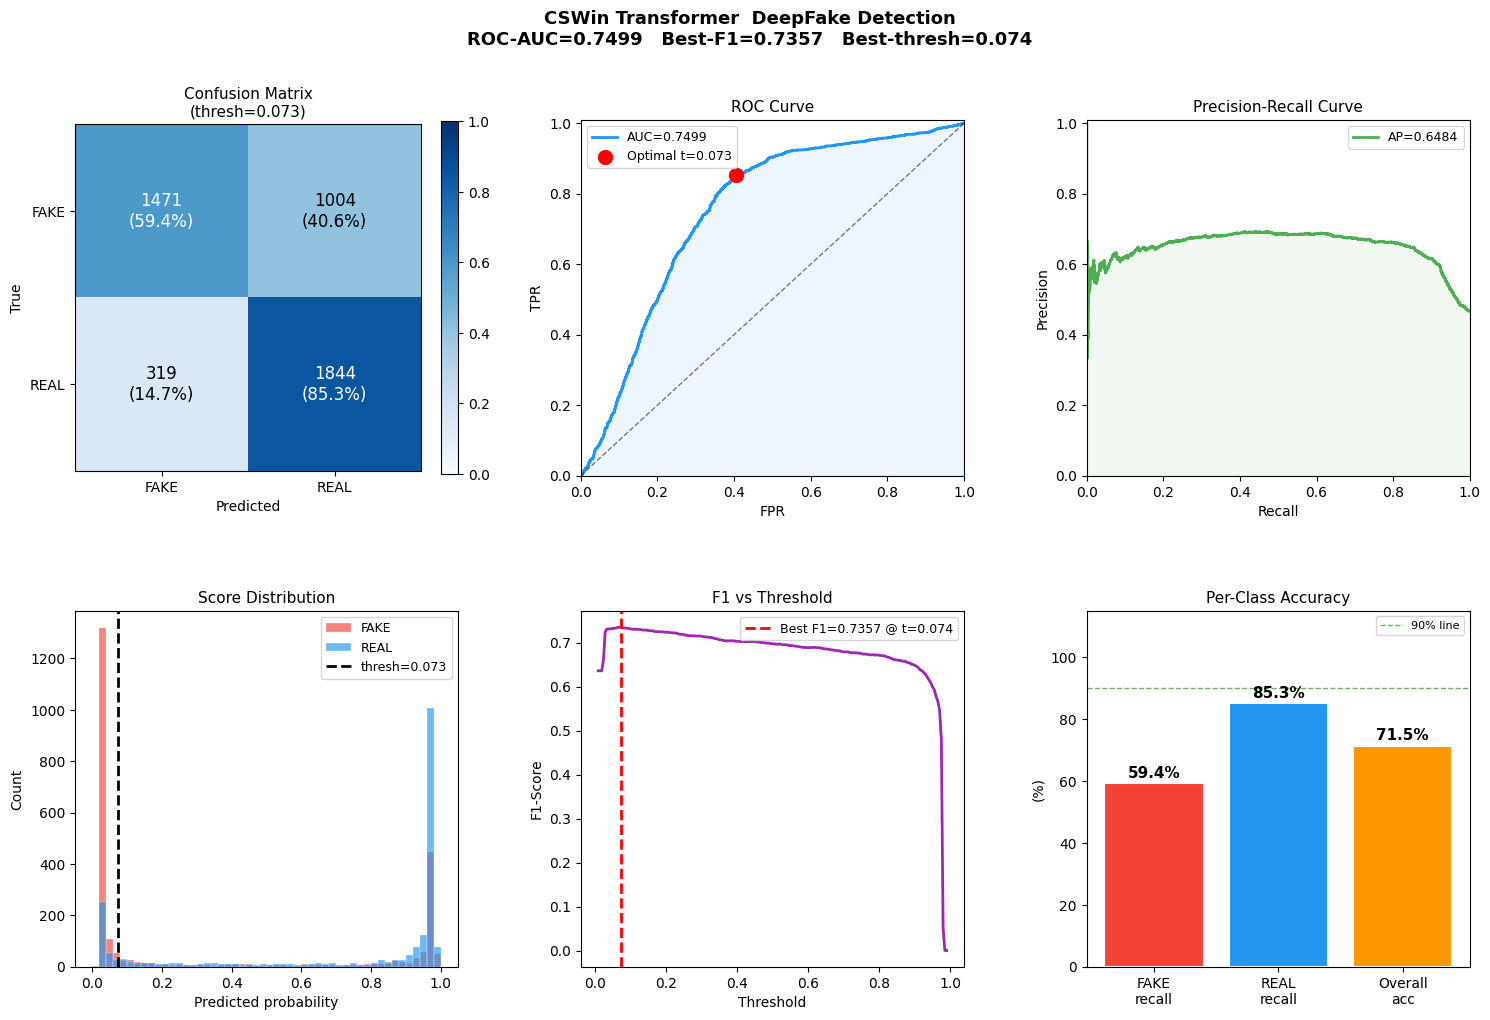


  SUMMARY
  ROC-AUC        : 0.7499
  Average Prec   : 0.6484
  Best F1-Score  : 0.7357  @ threshold 0.074
  FAKE recall    : 59.43%
  REAL recall    : 85.25%
  Overall acc    : 71.47%
  TN=1471  FP=1004  FN=319  TP=1844


In [11]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    confusion_matrix, roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    classification_report, f1_score,
)

# ══════════════════════════════════════════════════════════════════════════════
# CONFIG — must match training
# ══════════════════════════════════════════════════════════════════════════════
IMG_SIZE       = (128, 128)
BATCH_SIZE     = 32
DROP_PATH_RATE = 0.1
DROPOUT        = 0.1
MODEL_PATH     = "/kaggle/input/datasets/sahanakaids/cswin-checkpoints-new/cswin_best.keras"
DATA_DIR       = "/kaggle/input/datasets/sahanakaids/mtcnn-output/processed_faces_mtcnn"
OUT_DIR        = "/kaggle/working/eval_plots"
os.makedirs(OUT_DIR, exist_ok=True)


# ══════════════════════════════════════════════════════════════════════════════
# ARCHITECTURE — identical to training file
# ══════════════════════════════════════════════════════════════════════════════

class WarmupCosineDecay(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, peak_lr, min_lr, warmup_steps, total_steps, **kwargs):
        super().__init__(**kwargs)
        self.peak_lr=float(peak_lr); self.min_lr=float(min_lr)
        self.warmup_steps=float(warmup_steps); self.total_steps=float(total_steps)
    def __call__(self, step):
        import math
        step=tf.cast(step,tf.float32)
        warmup=self.peak_lr*(step/tf.maximum(self.warmup_steps,1.0))
        cos_arg=math.pi*(step-self.warmup_steps)/tf.maximum(self.total_steps-self.warmup_steps,1.0)
        cosine=self.min_lr+0.5*(self.peak_lr-self.min_lr)*(1.0+tf.cos(cos_arg))
        return tf.where(step<self.warmup_steps,warmup,cosine)
    def get_config(self):
        return {"peak_lr":self.peak_lr,"min_lr":self.min_lr,
                "warmup_steps":self.warmup_steps,"total_steps":self.total_steps}


class DropPath(layers.Layer):
    def __init__(self, drop_prob=0.0, **kwargs):
        super().__init__(**kwargs); self.drop_prob=float(drop_prob)
    def call(self, x, training=False):
        if not training or self.drop_prob==0.0: return x
        keep=1.0-self.drop_prob
        shape=(tf.shape(x)[0],)+(1,)*(len(x.shape)-1)
        return x*tf.math.floor(keep+tf.random.uniform(shape,dtype=x.dtype))/keep
    def get_config(self):
        cfg=super().get_config(); cfg["drop_prob"]=self.drop_prob; return cfg


class PatchEmbedding(layers.Layer):
    def __init__(self, dim, **kwargs):
        super().__init__(**kwargs)
        self.dim=dim
        self.proj=layers.Conv2D(dim,kernel_size=4,strides=4,padding="same",name="patch_proj")
        self.norm=layers.LayerNormalization(epsilon=1e-5,name="patch_norm")
        self._pe_shape=None
    def build(self, input_shape):
        H=int(input_shape[1]); W=int(input_shape[2])
        self._pe_shape=(1,H//4,W//4,self.dim)
        self.pos_embed=self.add_weight(
            name="pos_embed", shape=self._pe_shape,
            initializer="zeros", trainable=True, dtype=tf.float32)
        super().build(input_shape)
    def call(self, x):
        return self.norm(self.proj(x)+tf.cast(self.pos_embed,x.dtype))
    def get_config(self):
        cfg=super().get_config(); cfg["dim"]=self.dim; return cfg


def h_split(x,s):
    B=tf.shape(x)[0];H=tf.shape(x)[1];W=tf.shape(x)[2];C=x.shape[-1]
    return tf.reshape(tf.transpose(tf.reshape(x,[B,H//s,s,W,C]),[0,1,3,2,4]),[B*(H//s),W*s,C])
def h_merge(x,B,H,W,C,s):
    return tf.reshape(tf.transpose(tf.reshape(x,[B,H//s,W,s,C]),[0,1,3,2,4]),[B,H,W,C])
def v_split(x,s):
    B=tf.shape(x)[0];H=tf.shape(x)[1];W=tf.shape(x)[2];C=x.shape[-1]
    return tf.reshape(tf.transpose(tf.reshape(x,[B,H,W//s,s,C]),[0,2,1,3,4]),[B*(W//s),H*s,C])
def v_merge(x,B,H,W,C,s):
    return tf.reshape(tf.transpose(tf.reshape(x,[B,W//s,H,s,C]),[0,2,1,3,4]),[B,H,W,C])


class StripeAttention(layers.Layer):
    def __init__(self,dim,num_heads,attn_drop=0.0,**kwargs):
        super().__init__(**kwargs)
        self.num_heads=num_heads;self.head_dim=dim//num_heads;self.scale=self.head_dim**-0.5
        self.qkv=layers.Dense(dim*3,use_bias=True,name="qkv")
        self.proj=layers.Dense(dim,use_bias=True,name="proj")
        self.drop=layers.Dropout(attn_drop)
    def call(self,x,training=False):
        B=tf.shape(x)[0];N=tf.shape(x)[1];C=x.shape[-1]
        qkv=tf.transpose(tf.reshape(self.qkv(x),[B,N,3,self.num_heads,self.head_dim]),[2,0,3,1,4])
        q,k,v=qkv[0],qkv[1],qkv[2]
        attn=self.drop(tf.nn.softmax(tf.matmul(q,k,transpose_b=True)*self.scale,axis=-1),training=training)
        return self.proj(tf.reshape(tf.transpose(tf.matmul(attn,v),[0,2,1,3]),[B,N,C]))
    def get_config(self):
        cfg=super().get_config();cfg.update({"dim":self.num_heads*self.head_dim,"num_heads":self.num_heads});return cfg


class CSWinAttention(layers.Layer):
    def __init__(self,dim,num_heads,split_size,attn_drop=0.0,**kwargs):
        super().__init__(**kwargs)
        assert dim%2==0
        self.split_size=split_size;self.dim_half=dim//2
        hh=max(1,num_heads//2)
        self.attn_h=StripeAttention(self.dim_half,hh,attn_drop,name="attn_h")
        self.attn_v=StripeAttention(self.dim_half,hh,attn_drop,name="attn_v")
        self.lepe_h=layers.DepthwiseConv2D(3,padding="same",name="lepe_h")
        self.lepe_v=layers.DepthwiseConv2D(3,padding="same",name="lepe_v")
    def call(self,x,training=False):
        B=tf.shape(x)[0];H=tf.shape(x)[1];W=tf.shape(x)[2];s=self.split_size
        x1,x2=tf.split(x,2,axis=-1)
        xh=h_merge(self.attn_h(h_split(x1,s),training=training),B,H,W,self.dim_half,s)+self.lepe_h(x1)
        xv=v_merge(self.attn_v(v_split(x2,s),training=training),B,H,W,self.dim_half,s)+self.lepe_v(x2)
        return tf.concat([xh,xv],axis=-1)
    def get_config(self):
        cfg=super().get_config();cfg.update({"dim":self.dim_half*2,"num_heads":self.attn_h.num_heads*2,"split_size":self.split_size});return cfg


class CSWinBlock(layers.Layer):
    def __init__(self,dim,num_heads,split_size,mlp_ratio=4.0,drop_path=0.0,proj_drop=0.0,**kwargs):
        super().__init__(**kwargs)
        self.norm1=layers.LayerNormalization(epsilon=1e-5,name="norm1")
        self.attn=CSWinAttention(dim,num_heads,split_size,name="attn")
        self.dp1=DropPath(drop_path,name="dp1")
        self.norm2=layers.LayerNormalization(epsilon=1e-5,name="norm2")
        self.mlp=keras.Sequential([layers.Dense(int(dim*mlp_ratio),activation="gelu",name="fc1"),
                                    layers.Dropout(proj_drop),layers.Dense(dim,name="fc2"),
                                    layers.Dropout(proj_drop)],name="mlp")
        self.dp2=DropPath(drop_path,name="dp2")
    def call(self,x,training=False):
        x=x+self.dp1(self.attn(self.norm1(x),training=training),training=training)
        x=x+self.dp2(self.mlp(self.norm2(x),training=training),training=training)
        return x
    def get_config(self):
        cfg=super().get_config();cfg.update({"dim":self.attn.dim_half*2,"num_heads":self.attn.attn_h.num_heads*2,"split_size":self.attn.split_size});return cfg


class PatchMerging(layers.Layer):
    def __init__(self,out_dim,**kwargs):
        super().__init__(**kwargs);self.out_dim=out_dim
        self.conv=layers.Conv2D(out_dim,kernel_size=2,strides=2,padding="same",name="down_conv")
        self.norm=layers.LayerNormalization(epsilon=1e-5,name="down_norm")
    def call(self,x): return self.norm(self.conv(x))
    def get_config(self):
        cfg=super().get_config();cfg["out_dim"]=self.out_dim;return cfg


class CSWinTransformer(keras.Model):
    def __init__(self,embed_dim=64,depths=(2,2,6,2),num_heads=(2,4,8,16),
                 split_sizes=(2,2,4,2),mlp_ratio=4.0,drop_path_rate=DROP_PATH_RATE,
                 proj_drop=DROPOUT,num_classes=1,**kwargs):
        super().__init__(**kwargs)
        dpr=list(np.linspace(0,drop_path_rate,sum(depths)));bi=0;dim=embed_dim
        self.patch_embed=PatchEmbedding(embed_dim,name="patch_embed")
        self._sc=[]
        for si,(d,h,s) in enumerate(zip(depths,num_heads,split_sizes)):
            ns=[]
            for b in range(d):
                n=f"s{si}_b{b}"; setattr(self,n,CSWinBlock(dim,h,s,mlp_ratio,dpr[bi],proj_drop,name=n)); ns.append(n); bi+=1
            dn=None
            if si<len(depths)-1:
                dn=f"down_{si}"; setattr(self,dn,PatchMerging(dim*2,name=dn)); dim*=2
            self._sc.append((ns,dn))
        self.final_norm=layers.LayerNormalization(epsilon=1e-5,name="final_norm")
        self.gap=layers.GlobalAveragePooling2D(name="gap")
        self.head_drop=layers.Dropout(proj_drop,name="head_drop")
        self.head=layers.Dense(num_classes,activation="sigmoid",name="head",dtype="float32")
    def call(self,x,training=False):
        x=self.patch_embed(x)
        for ns,dn in self._sc:
            for n in ns: x=getattr(self,n)(x,training=training)
            if dn: x=getattr(self,dn)(x)
        return self.head(self.head_drop(self.gap(self.final_norm(x)),training=training))
    def get_config(self):
        return {"embed_dim":64,"depths":[2,2,6,2],"num_heads":[2,4,8,16],
                "split_sizes":[2,2,4,2],"mlp_ratio":4.0,
                "drop_path_rate":DROP_PATH_RATE,"proj_drop":DROPOUT,"num_classes":1}


CUSTOM_OBJECTS = {
    "CSWinTransformer":CSWinTransformer,"CSWinBlock":CSWinBlock,
    "CSWinAttention":CSWinAttention,"StripeAttention":StripeAttention,
    "PatchEmbedding":PatchEmbedding,"PatchMerging":PatchMerging,
    "DropPath":DropPath,"WarmupCosineDecay":WarmupCosineDecay,
}


# ══════════════════════════════════════════════════════════════════════════════
# DATA + MODEL LOADING
# ══════════════════════════════════════════════════════════════════════════════

def get_class_names():
    train_path = os.path.join(DATA_DIR, "train")
    folders = sorted([d for d in os.listdir(train_path)
                      if os.path.isdir(os.path.join(train_path, d))])
    fake = next((f for f in folders if "fake" in f.lower()), folders[0])
    real = next((f for f in folders if "real" in f.lower()), folders[-1])
    print(f"[LABELS]  0='{fake}' (FAKE)   1='{real}' (REAL)")
    return [fake, real]

def load_test_ds(class_names):
    ds = keras.preprocessing.image_dataset_from_directory(
        os.path.join(DATA_DIR, "test"),
        image_size=IMG_SIZE, batch_size=BATCH_SIZE,
        label_mode="binary", class_names=class_names, shuffle=False)
    return ds.map(lambda x, y: (tf.cast(x, tf.float32)/255.0, y)).prefetch(tf.data.AUTOTUNE)

def load_model():
    with keras.utils.custom_object_scope(CUSTOM_OBJECTS):
        m = keras.models.load_model(MODEL_PATH, compile=False)
    m.compile(loss="binary_crossentropy",
              metrics=["accuracy", keras.metrics.AUC(name="auc"),
                       keras.metrics.Precision(name="precision"),
                       keras.metrics.Recall(name="recall")])
    return m


# ══════════════════════════════════════════════════════════════════════════════
# EVALUATION + PLOTS
# ══════════════════════════════════════════════════════════════════════════════

def evaluate_and_plot(model, test_ds):
    print("\nCollecting predictions ...")
    y_prob = model.predict(test_ds, verbose=1).flatten()
    y_true = np.concatenate([y.numpy() for _, y in test_ds]).flatten()

    auc  = roc_auc_score(y_true, y_prob)
    ap   = average_precision_score(y_true, y_prob)
    fpr, tpr, thresh_roc = roc_curve(y_true, y_prob)
    prec, rec, _         = precision_recall_curve(y_true, y_prob)

    # Optimal threshold via Youden-J
    best_i = int(np.argmax(tpr - fpr))
    best_t = float(thresh_roc[best_i])
    y_pred = (y_prob >= best_t).astype(int)

    print(f"\n{'='*60}")
    print(f"  ROC-AUC  : {auc:.4f}")
    print(f"  Avg Prec : {ap:.4f}")
    print(f"  Optimal threshold (Youden-J): {best_t:.4f}")
    print(f"{'='*60}")
    print(classification_report(y_true, y_pred,
                                 target_names=["FAKE", "REAL"], digits=4))

    # F1 vs threshold sweep
    t_range = np.linspace(0.01, 0.99, 200)
    f1s     = [f1_score(y_true, (y_prob >= t).astype(int), zero_division=0)
               for t in t_range]
    best_f1_t = t_range[int(np.argmax(f1s))]

    # Confusion matrix
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    tn, fp, fn, tp = cm.ravel()

    # ── 6-panel figure ────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(18, 11))
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.32)

    # Panel 1 — Confusion matrix
    ax1 = fig.add_subplot(gs[0, 0])
    im  = ax1.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    for i in range(2):
        for j in range(2):
            ax1.text(j, i,
                     f"{cm[i,j]}\n({cm_norm[i,j]*100:.1f}%)",
                     ha="center", va="center", fontsize=12,
                     color="white" if cm_norm[i,j] > 0.5 else "black")
    ax1.set_xticks([0, 1]); ax1.set_yticks([0, 1])
    ax1.set_xticklabels(["FAKE", "REAL"])
    ax1.set_yticklabels(["FAKE", "REAL"])
    ax1.set_xlabel("Predicted"); ax1.set_ylabel("True")
    ax1.set_title(f"Confusion Matrix\n(thresh={best_t:.3f})", fontsize=11)
    plt.colorbar(im, ax=ax1, fraction=0.046)

    # Panel 2 — ROC curve
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(fpr, tpr, lw=2, color="#2196F3", label=f"AUC={auc:.4f}")
    ax2.scatter(fpr[best_i], tpr[best_i], s=100, color="red", zorder=5,
                label=f"Optimal t={best_t:.3f}")
    ax2.fill_between(fpr, tpr, alpha=0.08, color="#2196F3")
    ax2.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
    ax2.set_xlabel("FPR"); ax2.set_ylabel("TPR")
    ax2.set_title("ROC Curve", fontsize=11)
    ax2.legend(fontsize=9)
    ax2.set_xlim([0, 1]); ax2.set_ylim([0, 1.01])

    # Panel 3 — Precision-Recall
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.plot(rec, prec, lw=2, color="#4CAF50", label=f"AP={ap:.4f}")
    ax3.fill_between(rec, prec, alpha=0.08, color="#4CAF50")
    ax3.set_xlabel("Recall"); ax3.set_ylabel("Precision")
    ax3.set_title("Precision-Recall Curve", fontsize=11)
    ax3.legend(fontsize=9)
    ax3.set_xlim([0, 1]); ax3.set_ylim([0, 1.01])

    # Panel 4 — Score distribution
    ax4 = fig.add_subplot(gs[1, 0])
    bins = np.linspace(0, 1, 51)
    ax4.hist(y_prob[y_true==0], bins=bins, alpha=0.65,
             color="#F44336", label="FAKE", edgecolor="white", linewidth=0.3)
    ax4.hist(y_prob[y_true==1], bins=bins, alpha=0.65,
             color="#2196F3", label="REAL", edgecolor="white", linewidth=0.3)
    ax4.axvline(best_t, color="black", lw=2, linestyle="--",
                label=f"thresh={best_t:.3f}")
    ax4.set_xlabel("Predicted probability"); ax4.set_ylabel("Count")
    ax4.set_title("Score Distribution", fontsize=11)
    ax4.legend(fontsize=9)

    # Panel 5 — F1 vs threshold
    ax5 = fig.add_subplot(gs[1, 1])
    ax5.plot(t_range, f1s, lw=2, color="#9C27B0")
    ax5.axvline(best_f1_t, color="red", lw=2, linestyle="--",
                label=f"Best F1={max(f1s):.4f} @ t={best_f1_t:.3f}")
    ax5.set_xlabel("Threshold"); ax5.set_ylabel("F1-Score")
    ax5.set_title("F1 vs Threshold", fontsize=11)
    ax5.legend(fontsize=9)

    # Panel 6 — Per-class recall bar
    ax6 = fig.add_subplot(gs[1, 2])
    fake_acc = tn / (tn + fp) * 100
    real_acc = tp / (tp + fn) * 100
    overall  = (tn + tp) / cm.sum() * 100
    bars = ax6.bar(["FAKE\nrecall", "REAL\nrecall", "Overall\nacc"],
                   [fake_acc, real_acc, overall],
                   color=["#F44336", "#2196F3", "#FF9800"],
                   edgecolor="white", linewidth=1.5)
    for bar, val in zip(bars, [fake_acc, real_acc, overall]):
        ax6.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.8,
                 f"{val:.1f}%", ha="center", va="bottom",
                 fontsize=11, fontweight="bold")
    ax6.set_ylim([0, 115]); ax6.set_ylabel("(%)")
    ax6.set_title("Per-Class Accuracy", fontsize=11)
    ax6.axhline(90, color="green", linestyle="--", lw=1,
                alpha=0.6, label="90% line")
    ax6.legend(fontsize=8)

    fig.suptitle(
        f"CSWin Transformer  DeepFake Detection\n"
        f"ROC-AUC={auc:.4f}   Best-F1={max(f1s):.4f}   "
        f"Best-thresh={best_f1_t:.3f}",
        fontsize=13, fontweight="bold", y=0.98)

    out = os.path.join(OUT_DIR, "cswin_evaluation.png")
    fig.savefig(out, dpi=150, bbox_inches="tight")
    print(f"\nPlots saved to {out}")
    plt.show()

    print(f"\n{'='*60}")
    print(f"  SUMMARY")
    print(f"  ROC-AUC        : {auc:.4f}")
    print(f"  Average Prec   : {ap:.4f}")
    print(f"  Best F1-Score  : {max(f1s):.4f}  @ threshold {best_f1_t:.3f}")
    print(f"  FAKE recall    : {fake_acc:.2f}%")
    print(f"  REAL recall    : {real_acc:.2f}%")
    print(f"  Overall acc    : {overall:.2f}%")
    print(f"  TN={tn}  FP={fp}  FN={fn}  TP={tp}")
    print(f"{'='*60}")


def main():
    print("CSWin Transformer  Evaluation")
    class_names = get_class_names()
    test_ds     = load_test_ds(class_names)
    model       = load_model()
    evaluate_and_plot(model, test_ds)


if __name__ == "__main__":
    main()

In [8]:
!pip uninstall -y mtcnn
!pip install facenet-pytorch

Found existing installation: mtcnn 0.1.1
Uninstalling mtcnn-0.1.1:
  Successfully uninstalled mtcnn-0.1.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 18.0 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 73.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 76.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 2.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 80.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 63.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━

In [1]:
"""
DeepFake Predictor — Kaggle Cell
=================================
Paste this entire cell and run it.
  1. Click "Upload Image" → select a photo
  2. Click "Predict"
  3. Results appear below

Face detection: OpenCV DNN (ResNet SSD) — works on Python 3.12
  - More robust than Haar cascade for real-world photos
  - Falls back to Haar cascade if DNN proto files are unavailable
  - Falls back to full image resize if no face is detected at all
"""

# ── Install check ─────────────────────────────────────────────────────────────
import subprocess, sys
for pkg in ["ipywidgets"]:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg],
                   capture_output=True)

import os, math, urllib.request, shutil
import numpy as np
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import display, clear_output
import ipywidgets as widgets

# ══════════════════════════════════════════════════════════════════════════════
# CONFIG
# ══════════════════════════════════════════════════════════════════════════════
MODEL_PATH     = "/kaggle/input/datasets/sahanakaids/cswin-checkpoints-new/cswin_best.keras"
IMG_SIZE       = (128, 128)
THRESHOLD      = 0.5
DROP_PATH_RATE = 0.1
DROPOUT        = 0.1

# ══════════════════════════════════════════════════════════════════════════════
# FACE DETECTOR  — OpenCV DNN (ResNet SSD), no mtcnn needed
# ══════════════════════════════════════════════════════════════════════════════

# OpenCV ships with a pre-trained face detector via the DNN module.
# The weights are downloaded once and cached in /tmp.
_DNN_PROTO = "/tmp/deploy.prototxt"
_DNN_MODEL = "/tmp/res10_300x300_ssd_iter_140000.caffemodel"

_PROTO_URL  = ("https://raw.githubusercontent.com/opencv/opencv/master/"
               "samples/dnn/face_detector/deploy.prototxt")
_MODEL_URL  = ("https://github.com/opencv/opencv_3rdparty/raw/dnn_samples_"
               "face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel")

def _download_dnn_files():
    """Download OpenCV DNN face detector files if not already cached."""
    ok = True
    for path, url in [(_DNN_PROTO, _PROTO_URL), (_DNN_MODEL, _MODEL_URL)]:
        if not os.path.exists(path):
            try:
                print(f"  Downloading {os.path.basename(path)} ...")
                urllib.request.urlretrieve(url, path)
            except Exception as e:
                print(f"  Download failed: {e}")
                ok = False
    return ok


class FaceDetectorCV:
    """
    Two-stage face detector:
      Stage 1 — OpenCV ResNet SSD DNN (accurate, rotation-robust)
      Stage 2 — Haar cascade fallback (always available)
    """
    def __init__(self):
        self._dnn_net  = None
        self._haar     = None
        self._init_dnn()
        self._init_haar()

    def _init_dnn(self):
        if _download_dnn_files():
            try:
                self._dnn_net = cv2.dnn.readNetFromCaffe(_DNN_PROTO, _DNN_MODEL)
                print("  OpenCV DNN face detector loaded.")
            except Exception as e:
                print(f"  DNN load failed ({e}), using Haar fallback.")

    def _init_haar(self):
        haar_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
        self._haar = cv2.CascadeClassifier(haar_path)
        if self._haar.empty():
            print("  Warning: Haar cascade also failed to load.")
            self._haar = None

    def detect(self, img_rgb):
        """
        Returns list of (x, y, w, h, confidence) tuples, largest face first.
        img_rgb: np.ndarray H×W×3 uint8
        """
        faces = []

        # ── DNN detector ──────────────────────────────────────────────────────
        if self._dnn_net is not None:
            h, w = img_rgb.shape[:2]
            blob  = cv2.dnn.blobFromImage(
                cv2.resize(img_rgb, (300, 300)), 1.0,
                (300, 300), (104.0, 177.0, 123.0))
            self._dnn_net.setInput(blob)
            detections = self._dnn_net.forward()
            for i in range(detections.shape[2]):
                conf = float(detections[0, 0, i, 2])
                if conf < 0.5:
                    continue
                box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
                x1, y1, x2, y2 = box.astype(int)
                x1 = max(0, x1); y1 = max(0, y1)
                x2 = min(w, x2); y2 = min(h, y2)
                fw, fh = x2 - x1, y2 - y1
                if fw > 0 and fh > 0:
                    faces.append((x1, y1, fw, fh, conf))

        # ── Haar fallback ─────────────────────────────────────────────────────
        if not faces and self._haar is not None:
            gray  = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
            rects = self._haar.detectMultiScale(
                gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
            for (x, y, fw, fh) in (rects if len(rects) else []):
                faces.append((x, y, fw, fh, 0.8))

        # Largest face first
        faces.sort(key=lambda f: f[2] * f[3], reverse=True)
        return faces


# ══════════════════════════════════════════════════════════════════════════════
# ARCHITECTURE — identical to training
# ══════════════════════════════════════════════════════════════════════════════

class WarmupCosineDecay(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, peak_lr, min_lr, warmup_steps, total_steps, **kwargs):
        super().__init__(**kwargs)
        self.peak_lr=float(peak_lr); self.min_lr=float(min_lr)
        self.warmup_steps=float(warmup_steps); self.total_steps=float(total_steps)
    def __call__(self, step):
        step=tf.cast(step,tf.float32)
        warmup=self.peak_lr*(step/tf.maximum(self.warmup_steps,1.0))
        cos_arg=math.pi*(step-self.warmup_steps)/tf.maximum(self.total_steps-self.warmup_steps,1.0)
        cosine=self.min_lr+0.5*(self.peak_lr-self.min_lr)*(1.0+tf.cos(cos_arg))
        return tf.where(step<self.warmup_steps,warmup,cosine)
    def get_config(self):
        return {"peak_lr":self.peak_lr,"min_lr":self.min_lr,
                "warmup_steps":self.warmup_steps,"total_steps":self.total_steps}

class DropPath(layers.Layer):
    def __init__(self,drop_prob=0.0,**kwargs):
        super().__init__(**kwargs); self.drop_prob=float(drop_prob)
    def call(self,x,training=False):
        if not training or self.drop_prob==0.0: return x
        keep=1.0-self.drop_prob
        shape=(tf.shape(x)[0],)+(1,)*(len(x.shape)-1)
        return x*tf.math.floor(keep+tf.random.uniform(shape,dtype=x.dtype))/keep
    def get_config(self):
        cfg=super().get_config(); cfg["drop_prob"]=self.drop_prob; return cfg

class PatchEmbedding(layers.Layer):
    def __init__(self,dim,**kwargs):
        super().__init__(**kwargs); self.dim=dim
        self.proj=layers.Conv2D(dim,kernel_size=4,strides=4,padding="same",name="patch_proj")
        self.norm=layers.LayerNormalization(epsilon=1e-5,name="patch_norm")
    def build(self,input_shape):
        H=int(input_shape[1]); W=int(input_shape[2])
        self.pos_embed=self.add_weight(
            name="pos_embed",shape=(1,H//4,W//4,self.dim),
            initializer="zeros",trainable=True,dtype=tf.float32)
        super().build(input_shape)
    def call(self,x):
        return self.norm(self.proj(x)+tf.cast(self.pos_embed,x.dtype))
    def get_config(self):
        cfg=super().get_config(); cfg["dim"]=self.dim; return cfg

def h_split(x,s):
    B=tf.shape(x)[0];H=tf.shape(x)[1];W=tf.shape(x)[2];C=x.shape[-1]
    return tf.reshape(tf.transpose(tf.reshape(x,[B,H//s,s,W,C]),[0,1,3,2,4]),[B*(H//s),W*s,C])
def h_merge(x,B,H,W,C,s):
    return tf.reshape(tf.transpose(tf.reshape(x,[B,H//s,W,s,C]),[0,1,3,2,4]),[B,H,W,C])
def v_split(x,s):
    B=tf.shape(x)[0];H=tf.shape(x)[1];W=tf.shape(x)[2];C=x.shape[-1]
    return tf.reshape(tf.transpose(tf.reshape(x,[B,H,W//s,s,C]),[0,2,1,3,4]),[B*(W//s),H*s,C])
def v_merge(x,B,H,W,C,s):
    return tf.reshape(tf.transpose(tf.reshape(x,[B,W//s,H,s,C]),[0,2,1,3,4]),[B,H,W,C])

class StripeAttention(layers.Layer):
    def __init__(self,dim,num_heads,attn_drop=0.0,**kwargs):
        super().__init__(**kwargs)
        self.num_heads=num_heads;self.head_dim=dim//num_heads;self.scale=self.head_dim**-0.5
        self.qkv=layers.Dense(dim*3,use_bias=True,name="qkv")
        self.proj=layers.Dense(dim,use_bias=True,name="proj")
        self.drop=layers.Dropout(attn_drop)
    def call(self,x,training=False):
        B=tf.shape(x)[0];N=tf.shape(x)[1];C=x.shape[-1]
        qkv=tf.transpose(tf.reshape(self.qkv(x),[B,N,3,self.num_heads,self.head_dim]),[2,0,3,1,4])
        q,k,v=qkv[0],qkv[1],qkv[2]
        attn=self.drop(tf.nn.softmax(tf.matmul(q,k,transpose_b=True)*self.scale,axis=-1),training=training)
        return self.proj(tf.reshape(tf.transpose(tf.matmul(attn,v),[0,2,1,3]),[B,N,C]))
    def get_config(self):
        cfg=super().get_config();cfg.update({"dim":self.num_heads*self.head_dim,"num_heads":self.num_heads});return cfg

class CSWinAttention(layers.Layer):
    def __init__(self,dim,num_heads,split_size,attn_drop=0.0,**kwargs):
        super().__init__(**kwargs)
        assert dim%2==0
        self.split_size=split_size;self.dim_half=dim//2
        hh=max(1,num_heads//2)
        self.attn_h=StripeAttention(self.dim_half,hh,attn_drop,name="attn_h")
        self.attn_v=StripeAttention(self.dim_half,hh,attn_drop,name="attn_v")
        self.lepe_h=layers.DepthwiseConv2D(3,padding="same",name="lepe_h")
        self.lepe_v=layers.DepthwiseConv2D(3,padding="same",name="lepe_v")
    def call(self,x,training=False):
        B=tf.shape(x)[0];H=tf.shape(x)[1];W=tf.shape(x)[2];s=self.split_size
        x1,x2=tf.split(x,2,axis=-1)
        xh=h_merge(self.attn_h(h_split(x1,s),training=training),B,H,W,self.dim_half,s)+self.lepe_h(x1)
        xv=v_merge(self.attn_v(v_split(x2,s),training=training),B,H,W,self.dim_half,s)+self.lepe_v(x2)
        return tf.concat([xh,xv],axis=-1)
    def get_config(self):
        cfg=super().get_config();cfg.update({"dim":self.dim_half*2,"num_heads":self.attn_h.num_heads*2,"split_size":self.split_size});return cfg

class CSWinBlock(layers.Layer):
    def __init__(self,dim,num_heads,split_size,mlp_ratio=4.0,drop_path=0.0,proj_drop=0.0,**kwargs):
        super().__init__(**kwargs)
        self.norm1=layers.LayerNormalization(epsilon=1e-5,name="norm1")
        self.attn=CSWinAttention(dim,num_heads,split_size,name="attn")
        self.dp1=DropPath(drop_path,name="dp1")
        self.norm2=layers.LayerNormalization(epsilon=1e-5,name="norm2")
        self.mlp=keras.Sequential([layers.Dense(int(dim*mlp_ratio),activation="gelu",name="fc1"),
                                    layers.Dropout(proj_drop),layers.Dense(dim,name="fc2"),
                                    layers.Dropout(proj_drop)],name="mlp")
        self.dp2=DropPath(drop_path,name="dp2")
    def call(self,x,training=False):
        x=x+self.dp1(self.attn(self.norm1(x),training=training),training=training)
        x=x+self.dp2(self.mlp(self.norm2(x),training=training),training=training)
        return x
    def get_config(self):
        cfg=super().get_config();cfg.update({"dim":self.attn.dim_half*2,"num_heads":self.attn.attn_h.num_heads*2,"split_size":self.attn.split_size});return cfg

class PatchMerging(layers.Layer):
    def __init__(self,out_dim,**kwargs):
        super().__init__(**kwargs);self.out_dim=out_dim
        self.conv=layers.Conv2D(out_dim,kernel_size=2,strides=2,padding="same",name="down_conv")
        self.norm=layers.LayerNormalization(epsilon=1e-5,name="down_norm")
    def call(self,x): return self.norm(self.conv(x))
    def get_config(self):
        cfg=super().get_config();cfg["out_dim"]=self.out_dim;return cfg

class CSWinTransformer(keras.Model):
    def __init__(self,embed_dim=64,depths=(2,2,6,2),num_heads=(2,4,8,16),
                 split_sizes=(2,2,4,2),mlp_ratio=4.0,drop_path_rate=DROP_PATH_RATE,
                 proj_drop=DROPOUT,num_classes=1,**kwargs):
        super().__init__(**kwargs)
        dpr=list(np.linspace(0,drop_path_rate,sum(depths)));bi=0;dim=embed_dim
        self.patch_embed=PatchEmbedding(embed_dim,name="patch_embed")
        self._sc=[]
        for si,(d,h,s) in enumerate(zip(depths,num_heads,split_sizes)):
            ns=[]
            for b in range(d):
                n=f"s{si}_b{b}"; setattr(self,n,CSWinBlock(dim,h,s,mlp_ratio,dpr[bi],proj_drop,name=n)); ns.append(n); bi+=1
            dn=None
            if si<len(depths)-1:
                dn=f"down_{si}"; setattr(self,dn,PatchMerging(dim*2,name=dn)); dim*=2
            self._sc.append((ns,dn))
        self.final_norm=layers.LayerNormalization(epsilon=1e-5,name="final_norm")
        self.gap=layers.GlobalAveragePooling2D(name="gap")
        self.head_drop=layers.Dropout(proj_drop,name="head_drop")
        self.head=layers.Dense(num_classes,activation="sigmoid",name="head",dtype="float32")
    def call(self,x,training=False):
        x=self.patch_embed(x)
        for ns,dn in self._sc:
            for n in ns: x=getattr(self,n)(x,training=training)
            if dn: x=getattr(self,dn)(x)
        return self.head(self.head_drop(self.gap(self.final_norm(x)),training=training))
    def get_config(self):
        return {"embed_dim":64,"depths":[2,2,6,2],"num_heads":[2,4,8,16],
                "split_sizes":[2,2,4,2],"mlp_ratio":4.0,
                "drop_path_rate":DROP_PATH_RATE,"proj_drop":DROPOUT,"num_classes":1}

CUSTOM_OBJECTS = {
    "CSWinTransformer":CSWinTransformer,"CSWinBlock":CSWinBlock,
    "CSWinAttention":CSWinAttention,"StripeAttention":StripeAttention,
    "PatchEmbedding":PatchEmbedding,"PatchMerging":PatchMerging,
    "DropPath":DropPath,"WarmupCosineDecay":WarmupCosineDecay,
}

# ══════════════════════════════════════════════════════════════════════════════
# LOAD MODEL + DETECTOR (done once when cell runs)
# ══════════════════════════════════════════════════════════════════════════════

print("Loading CSWin model ...")
with keras.utils.custom_object_scope(CUSTOM_OBJECTS):
    _model = keras.models.load_model(MODEL_PATH, compile=False)
print("Model loaded.")

print("Initialising face detector ...")
_face_detector = FaceDetectorCV()
print("Face detector ready.\n")


# ══════════════════════════════════════════════════════════════════════════════
# PREDICTION FUNCTION
# ══════════════════════════════════════════════════════════════════════════════

def predict_image(image_path, threshold=THRESHOLD):
    orig_bgr = cv2.imread(image_path)
    if orig_bgr is None:
        print(f"Could not read: {image_path}")
        return None
    orig_rgb = cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB)
    h_img, w_img = orig_rgb.shape[:2]

    # ── Face detection ────────────────────────────────────────────────────────
    faces         = _face_detector.detect(orig_rgb)
    used_fallback = False
    bbox          = None

    if faces:
        x, y, fw, fh, face_conf = faces[0]
        x2 = min(w_img, x + fw); y2 = min(h_img, y + fh)
        face_crop = orig_rgb[y:y2, x:x2]
        if face_crop.size == 0:
            faces = []

    if faces:
        face_resized = cv2.resize(face_crop, IMG_SIZE)
        face_norm    = face_resized.astype(np.float32) / 255.0
        bbox         = {"x": x, "y": y, "w": fw, "h": fh, "conf": face_conf}
    else:
        print("  No face detected — using full image (less accurate).")
        face_norm    = cv2.resize(orig_rgb, IMG_SIZE).astype(np.float32) / 255.0
        used_fallback = True

    # ── CSWin prediction ──────────────────────────────────────────────────────
    inp   = np.expand_dims(face_norm, axis=0)
    prob  = float(_model(inp, training=False).numpy()[0, 0])
    label = "REAL" if prob >= threshold else "FAKE"
    conf  = prob if label == "REAL" else (1.0 - prob)

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Panel 1 — original + bounding box
    axes[0].imshow(orig_rgb)
    axes[0].set_title("Input Image", fontsize=12)
    axes[0].axis("off")
    if bbox:
        edge_col = "#2ecc71" if label == "REAL" else "#e74c3c"
        rect = patches.Rectangle(
            (bbox["x"], bbox["y"]), bbox["w"], bbox["h"],
            linewidth=3, edgecolor=edge_col, facecolor="none")
        axes[0].add_patch(rect)
        axes[0].text(
            bbox["x"], max(0, bbox["y"] - 8),
            f"Face  {bbox['conf']:.2f}",
            color=edge_col, fontsize=10, fontweight="bold",
            bbox=dict(facecolor="black", alpha=0.55, pad=2))

    # Panel 2 — extracted face
    axes[1].imshow(face_norm)
    title2 = "Extracted Face" if not used_fallback else "Full Image (no face)"
    axes[1].set_title(title2, fontsize=12)
    axes[1].axis("off")

    # Panel 3 — verdict card
    bg = "#2ecc71" if label == "REAL" else "#e74c3c"
    axes[2].set_facecolor(bg)
    axes[2].text(0.5, 0.62, label,
                 ha="center", va="center", fontsize=52, fontweight="bold",
                 color="white", transform=axes[2].transAxes)
    axes[2].text(0.5, 0.38, f"Confidence: {conf*100:.1f}%",
                 ha="center", va="center", fontsize=20,
                 color="white", transform=axes[2].transAxes)
    axes[2].text(0.5, 0.20,
                 f"Score: {prob:.4f}  |  threshold: {threshold}",
                 ha="center", va="center", fontsize=10,
                 color="white", alpha=0.85, transform=axes[2].transAxes)
    if used_fallback:
        axes[2].text(0.5, 0.08, "No face detected — full image used",
                     ha="center", va="center", fontsize=9,
                     color="yellow", transform=axes[2].transAxes)
    axes[2].set_title("Prediction", fontsize=12)
    axes[2].axis("off")

    plt.suptitle(
        f"DeepFake Detection — {label}  ({conf*100:.1f}% confident)",
        fontsize=14, fontweight="bold",
        color="#1a7a3c" if label == "REAL" else "#c0392b")
    plt.tight_layout()

    out_path = "/kaggle/working/prediction_result.png"
    plt.savefig(out_path, dpi=130, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"\n{'='*50}")
    print(f"  Result     : {label}")
    print(f"  Confidence : {conf*100:.1f}%")
    print(f"  Raw score  : {prob:.6f}  (≥{threshold} → REAL)")
    if used_fallback:
        print("  Warning    : No face detected; full image used")
    print(f"  Saved to   : {out_path}")
    print(f"{'='*50}")
    return {"label": label, "confidence": conf, "raw_score": prob}


# ══════════════════════════════════════════════════════════════════════════════
# UPLOAD WIDGET
# ══════════════════════════════════════════════════════════════════════════════

_upload  = widgets.FileUpload(
    accept="image/*", multiple=False,
    description="Upload Image",
    layout=widgets.Layout(width="280px"))

_btn     = widgets.Button(
    description="Predict",
    button_style="primary",
    layout=widgets.Layout(width="130px"))

_out     = widgets.Output()

def _on_predict(_):
    with _out:
        clear_output(wait=True)
        if not _upload.value:
            print("Please upload an image first.")
            return

        # ipywidgets 8+: .value is a tuple of dicts {name, content, ...}
        # ipywidgets 7:  .value is a dict keyed by filename
        val = _upload.value
        if isinstance(val, tuple):
            file_info = val[0]
            fname   = file_info["name"]
            content = bytes(file_info["content"])
        else:
            fname   = list(val.keys())[0]
            content = bytes(val[fname]["content"])

        save_path = f"/kaggle/working/uploaded_{fname}"
        with open(save_path, "wb") as f:
            f.write(content)
        print(f"Uploaded: {fname}  ({len(content)/1024:.1f} KB)")
        predict_image(save_path)

_btn.on_click(_on_predict)

print("=" * 52)
print("  DeepFake Detector — ready")
print("=" * 52)
print("Step 1: Click 'Upload Image' and choose a photo")
print("Step 2: Click 'Predict'\n")
display(widgets.HBox([_upload, _btn]))
display(_out)

2026-04-22 15:26:29.592515: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776871589.784039      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776871589.844392      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776871590.335415      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776871590.335454      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776871590.335457      55 computation_placer.cc:177] computation placer alr

Loading CSWin model ...


I0000 00:00:1776871614.212192      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776871614.218493      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model loaded.
Initialising face detector ...
  OpenCV DNN face detector loaded.
Face detector ready.

  DeepFake Detector — ready
Step 1: Click 'Upload Image' and choose a photo
Step 2: Click 'Predict'



Output()

In [ ]:
"""
DeepFake Predictor + SHAP Explainability
=========================================
Paste this entire cell in Kaggle and run it.

Explainability methods used:
  1. GradCAM (input-gradient)   — works on ANY model including subclassed
  2. SHAP GradientExplainer     — most compatible with subclassed Keras models
  3. Occlusion sensitivity      — model-agnostic, no architecture assumptions
  4. Region importance bars     — human-interpretable anatomical breakdown

Why GradientExplainer over DeepExplainer:
  DeepExplainer requires model.inputs (Functional API only).
  GradientExplainer uses tf.GradientTape internally and works on
  any callable TF model, including subclassed models like CSWinTransformer.
"""

# ── Installs ──────────────────────────────────────────────────────────────────
import subprocess, sys
for pkg in ["ipywidgets", "shap"]:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg],
                   capture_output=True)

import os, math, urllib.request, warnings
warnings.filterwarnings("ignore")

from IPython.display import display
import numpy as np
import cv2
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
from scipy.ndimage import gaussian_filter
from IPython.display import display, clear_output
import ipywidgets as widgets

# ══════════════════════════════════════════════════════════════════════════════
# CONFIG
# ══════════════════════════════════════════════════════════════════════════════
MODEL_PATH     = "/kaggle/input/datasets/sahanakaids/cswin-checkpoints-new/cswin_best.keras"
IMG_SIZE       = (128, 128)
THRESHOLD      = 0.5
DROP_PATH_RATE = 0.1
DROPOUT        = 0.1
OUT_DIR        = "/kaggle/working"

# SHAP / explainability settings
SHAP_N_BG       = 30    # background samples for GradientExplainer
SHAP_N_GRAD     = 10    # gradient samples per background (SmoothGrad-style)
OCC_PATCH_SIZE  = 8     # occlusion patch size in pixels

# ══════════════════════════════════════════════════════════════════════════════
# FACE DETECTOR  — OpenCV DNN, Python 3.12 compatible
# ══════════════════════════════════════════════════════════════════════════════
_DNN_PROTO = "/tmp/deploy.prototxt"
_DNN_MODEL = "/tmp/res10_300x300_ssd_iter_140000.caffemodel"
_PROTO_URL = ("https://raw.githubusercontent.com/opencv/opencv/master/"
              "samples/dnn/face_detector/deploy.prototxt")
_MODEL_URL = ("https://github.com/opencv/opencv_3rdparty/raw/dnn_samples_"
              "face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel")

def _download_dnn_files():
    ok = True
    for path, url in [(_DNN_PROTO, _PROTO_URL), (_DNN_MODEL, _MODEL_URL)]:
        if not os.path.exists(path):
            try:
                print(f"  Downloading {os.path.basename(path)} ...")
                urllib.request.urlretrieve(url, path)
            except Exception as e:
                print(f"  Download failed: {e}"); ok = False
    return ok

class FaceDetectorCV:
    def __init__(self):
        self._dnn_net = None; self._haar = None
        self._init_dnn(); self._init_haar()

    def _init_dnn(self):
        if _download_dnn_files():
            try:
                self._dnn_net = cv2.dnn.readNetFromCaffe(_DNN_PROTO, _DNN_MODEL)
                print("  OpenCV DNN face detector loaded.")
            except Exception as e:
                print(f"  DNN load failed ({e}), using Haar fallback.")

    def _init_haar(self):
        p = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
        self._haar = cv2.CascadeClassifier(p)
        if self._haar.empty(): self._haar = None

    def detect(self, img_rgb):
        faces = []
        if self._dnn_net is not None:
            h, w = img_rgb.shape[:2]
            blob = cv2.dnn.blobFromImage(
                cv2.resize(img_rgb, (300, 300)), 1.0,
                (300, 300), (104.0, 177.0, 123.0))
            self._dnn_net.setInput(blob)
            dets = self._dnn_net.forward()
            for i in range(dets.shape[2]):
                c = float(dets[0, 0, i, 2])
                if c < 0.5: continue
                box = dets[0, 0, i, 3:7] * np.array([w, h, w, h])
                x1, y1, x2, y2 = box.astype(int)
                x1=max(0,x1); y1=max(0,y1); x2=min(w,x2); y2=min(h,y2)
                fw, fh = x2-x1, y2-y1
                if fw > 0 and fh > 0:
                    faces.append((x1, y1, fw, fh, c))
        if not faces and self._haar is not None:
            gray  = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
            rects = self._haar.detectMultiScale(
                gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
            for (x, y, fw, fh) in (rects if len(rects) else []):
                faces.append((x, y, fw, fh, 0.8))
        faces.sort(key=lambda f: f[2]*f[3], reverse=True)
        return faces

# ══════════════════════════════════════════════════════════════════════════════
# ARCHITECTURE — identical to cswin_train_final.py
# ══════════════════════════════════════════════════════════════════════════════

class WarmupCosineDecay(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self,peak_lr,min_lr,warmup_steps,total_steps,**kwargs):
        super().__init__(**kwargs)
        self.peak_lr=float(peak_lr);self.min_lr=float(min_lr)
        self.warmup_steps=float(warmup_steps);self.total_steps=float(total_steps)
    def __call__(self,step):
        step=tf.cast(step,tf.float32)
        warmup=self.peak_lr*(step/tf.maximum(self.warmup_steps,1.0))
        cos_arg=math.pi*(step-self.warmup_steps)/tf.maximum(self.total_steps-self.warmup_steps,1.0)
        cosine=self.min_lr+0.5*(self.peak_lr-self.min_lr)*(1.0+tf.cos(cos_arg))
        return tf.where(step<self.warmup_steps,warmup,cosine)
    def get_config(self):
        return {"peak_lr":self.peak_lr,"min_lr":self.min_lr,
                "warmup_steps":self.warmup_steps,"total_steps":self.total_steps}

class DropPath(layers.Layer):
    def __init__(self,drop_prob=0.0,**kwargs):
        super().__init__(**kwargs);self.drop_prob=float(drop_prob)
    def call(self,x,training=False):
        if not training or self.drop_prob==0.0: return x
        keep=1.0-self.drop_prob
        shape=(tf.shape(x)[0],)+(1,)*(len(x.shape)-1)
        return x*tf.math.floor(keep+tf.random.uniform(shape,dtype=x.dtype))/keep
    def get_config(self):
        cfg=super().get_config();cfg["drop_prob"]=self.drop_prob;return cfg

class PatchEmbedding(layers.Layer):
    def __init__(self,dim,**kwargs):
        super().__init__(**kwargs);self.dim=dim
        self.proj=layers.Conv2D(dim,kernel_size=4,strides=4,padding="same",name="patch_proj")
        self.norm=layers.LayerNormalization(epsilon=1e-5,name="patch_norm")
    def build(self,input_shape):
        H=int(input_shape[1]);W=int(input_shape[2])
        self.pos_embed=self.add_weight(
            name="pos_embed",shape=(1,H//4,W//4,self.dim),
            initializer="zeros",trainable=True,dtype=tf.float32)
        super().build(input_shape)
    def call(self,x):
        return self.norm(self.proj(x)+tf.cast(self.pos_embed,x.dtype))
    def get_config(self):
        cfg=super().get_config();cfg["dim"]=self.dim;return cfg

def h_split(x,s):
    B=tf.shape(x)[0];H=tf.shape(x)[1];W=tf.shape(x)[2];C=x.shape[-1]
    return tf.reshape(tf.transpose(tf.reshape(x,[B,H//s,s,W,C]),[0,1,3,2,4]),[B*(H//s),W*s,C])
def h_merge(x,B,H,W,C,s):
    return tf.reshape(tf.transpose(tf.reshape(x,[B,H//s,W,s,C]),[0,1,3,2,4]),[B,H,W,C])
def v_split(x,s):
    B=tf.shape(x)[0];H=tf.shape(x)[1];W=tf.shape(x)[2];C=x.shape[-1]
    return tf.reshape(tf.transpose(tf.reshape(x,[B,H,W//s,s,C]),[0,2,1,3,4]),[B*(W//s),H*s,C])
def v_merge(x,B,H,W,C,s):
    return tf.reshape(tf.transpose(tf.reshape(x,[B,W//s,H,s,C]),[0,2,1,3,4]),[B,H,W,C])

class StripeAttention(layers.Layer):
    def __init__(self,dim,num_heads,attn_drop=0.0,**kwargs):
        super().__init__(**kwargs)
        self.num_heads=num_heads;self.head_dim=dim//num_heads;self.scale=self.head_dim**-0.5
        self.qkv=layers.Dense(dim*3,use_bias=True,name="qkv")
        self.proj=layers.Dense(dim,use_bias=True,name="proj")
        self.drop=layers.Dropout(attn_drop)
    def call(self,x,training=False):
        B=tf.shape(x)[0];N=tf.shape(x)[1];C=x.shape[-1]
        qkv=tf.transpose(tf.reshape(self.qkv(x),[B,N,3,self.num_heads,self.head_dim]),[2,0,3,1,4])
        q,k,v=qkv[0],qkv[1],qkv[2]
        attn=self.drop(tf.nn.softmax(tf.matmul(q,k,transpose_b=True)*self.scale,axis=-1),training=training)
        return self.proj(tf.reshape(tf.transpose(tf.matmul(attn,v),[0,2,1,3]),[B,N,C]))
    def get_config(self):
        cfg=super().get_config();cfg.update({"dim":self.num_heads*self.head_dim,"num_heads":self.num_heads});return cfg

class CSWinAttention(layers.Layer):
    def __init__(self,dim,num_heads,split_size,attn_drop=0.0,**kwargs):
        super().__init__(**kwargs)
        assert dim%2==0;self.split_size=split_size;self.dim_half=dim//2
        hh=max(1,num_heads//2)
        self.attn_h=StripeAttention(self.dim_half,hh,attn_drop,name="attn_h")
        self.attn_v=StripeAttention(self.dim_half,hh,attn_drop,name="attn_v")
        self.lepe_h=layers.DepthwiseConv2D(3,padding="same",name="lepe_h")
        self.lepe_v=layers.DepthwiseConv2D(3,padding="same",name="lepe_v")
    def call(self,x,training=False):
        B=tf.shape(x)[0];H=tf.shape(x)[1];W=tf.shape(x)[2];s=self.split_size
        x1,x2=tf.split(x,2,axis=-1)
        xh=h_merge(self.attn_h(h_split(x1,s),training=training),B,H,W,self.dim_half,s)+self.lepe_h(x1)
        xv=v_merge(self.attn_v(v_split(x2,s),training=training),B,H,W,self.dim_half,s)+self.lepe_v(x2)
        return tf.concat([xh,xv],axis=-1)
    def get_config(self):
        cfg=super().get_config();cfg.update({"dim":self.dim_half*2,"num_heads":self.attn_h.num_heads*2,"split_size":self.split_size});return cfg

class CSWinBlock(layers.Layer):
    def __init__(self,dim,num_heads,split_size,mlp_ratio=4.0,drop_path=0.0,proj_drop=0.0,**kwargs):
        super().__init__(**kwargs)
        self.norm1=layers.LayerNormalization(epsilon=1e-5,name="norm1")
        self.attn=CSWinAttention(dim,num_heads,split_size,name="attn")
        self.dp1=DropPath(drop_path,name="dp1")
        self.norm2=layers.LayerNormalization(epsilon=1e-5,name="norm2")
        self.mlp=keras.Sequential([
            layers.Dense(int(dim*mlp_ratio),activation="gelu",name="fc1"),
            layers.Dropout(proj_drop),
            layers.Dense(dim,name="fc2"),
            layers.Dropout(proj_drop)],name="mlp")
        self.dp2=DropPath(drop_path,name="dp2")
    def call(self,x,training=False):
        x=x+self.dp1(self.attn(self.norm1(x),training=training),training=training)
        x=x+self.dp2(self.mlp(self.norm2(x),training=training),training=training)
        return x
    def get_config(self):
        cfg=super().get_config();cfg.update({"dim":self.attn.dim_half*2,"num_heads":self.attn.attn_h.num_heads*2,"split_size":self.attn.split_size});return cfg

class PatchMerging(layers.Layer):
    def __init__(self,out_dim,**kwargs):
        super().__init__(**kwargs);self.out_dim=out_dim
        self.conv=layers.Conv2D(out_dim,kernel_size=2,strides=2,padding="same",name="down_conv")
        self.norm=layers.LayerNormalization(epsilon=1e-5,name="down_norm")
    def call(self,x): return self.norm(self.conv(x))
    def get_config(self):
        cfg=super().get_config();cfg["out_dim"]=self.out_dim;return cfg

class CSWinTransformer(keras.Model):
    def __init__(self,embed_dim=64,depths=(2,2,6,2),num_heads=(2,4,8,16),
                 split_sizes=(2,2,4,2),mlp_ratio=4.0,drop_path_rate=DROP_PATH_RATE,
                 proj_drop=DROPOUT,num_classes=1,**kwargs):
        super().__init__(**kwargs)
        dpr=list(np.linspace(0,drop_path_rate,sum(depths)));bi=0;dim=embed_dim
        self.patch_embed=PatchEmbedding(embed_dim,name="patch_embed");self._sc=[]
        for si,(d,h,s) in enumerate(zip(depths,num_heads,split_sizes)):
            ns=[]
            for b in range(d):
                n=f"s{si}_b{b}";setattr(self,n,CSWinBlock(dim,h,s,mlp_ratio,dpr[bi],proj_drop,name=n));ns.append(n);bi+=1
            dn=None
            if si<len(depths)-1:
                dn=f"down_{si}";setattr(self,dn,PatchMerging(dim*2,name=dn));dim*=2
            self._sc.append((ns,dn))
        self.final_norm=layers.LayerNormalization(epsilon=1e-5,name="final_norm")
        self.gap=layers.GlobalAveragePooling2D(name="gap")
        self.head_drop=layers.Dropout(proj_drop,name="head_drop")
        self.head=layers.Dense(num_classes,activation="sigmoid",name="head",dtype="float32")
    def call(self,x,training=False):
        x=self.patch_embed(x)
        for ns,dn in self._sc:
            for n in ns: x=getattr(self,n)(x,training=training)
            if dn: x=getattr(self,dn)(x)
        return self.head(self.head_drop(self.gap(self.final_norm(x)),training=training))
    def get_config(self):
        return {"embed_dim":64,"depths":[2,2,6,2],"num_heads":[2,4,8,16],
                "split_sizes":[2,2,4,2],"mlp_ratio":4.0,
                "drop_path_rate":DROP_PATH_RATE,"proj_drop":DROPOUT,"num_classes":1}

CUSTOM_OBJECTS = {
    "CSWinTransformer":CSWinTransformer,"CSWinBlock":CSWinBlock,
    "CSWinAttention":CSWinAttention,"StripeAttention":StripeAttention,
    "PatchEmbedding":PatchEmbedding,"PatchMerging":PatchMerging,
    "DropPath":DropPath,"WarmupCosineDecay":WarmupCosineDecay,
}

# ══════════════════════════════════════════════════════════════════════════════
# LOAD MODEL + DETECTOR
# ══════════════════════════════════════════════════════════════════════════════

def load_model():
    """Load CSWin checkpoint with all custom objects registered."""
    with keras.utils.custom_object_scope(CUSTOM_OBJECTS):
        m = keras.models.load_model(MODEL_PATH, compile=False)
    # Warm-up call: required for subclassed models to materialise weights
    # so that GradientTape can watch them properly.
    _ = m(tf.zeros((1,)+IMG_SIZE+(3,), dtype=tf.float32), training=False)
    return m

print("Loading CSWin model ...")
_model = load_model()
print("Model loaded.")

print("Initialising face detector ...")
_face_detector = FaceDetectorCV()
print("Face detector ready.\n")

# ══════════════════════════════════════════════════════════════════════════════
# PREPROCESSING
# ══════════════════════════════════════════════════════════════════════════════

def preprocess_image(image_path):
    """
    Load image → detect face → extract & resize → normalise to [0,1].
    Returns:
        face_norm      : np.float32 (H, W, 3) normalised face crop
        orig_rgb       : np.uint8   (H, W, 3) original full image
        bbox           : dict {x,y,w,h,conf} or None if fallback used
        used_fallback  : bool
    """
    orig_bgr = cv2.imread(image_path)
    if orig_bgr is None:
        raise FileNotFoundError(f"Cannot read image: {image_path}")
    orig_rgb  = cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB)
    h_img, w_img = orig_rgb.shape[:2]

    faces = _face_detector.detect(orig_rgb)
    bbox  = None
    used_fallback = False

    if faces:
        x, y, fw, fh, face_conf = faces[0]
        x2 = min(w_img, x+fw); y2 = min(h_img, y+fh)
        face_crop = orig_rgb[y:y2, x:x2]
        if face_crop.size == 0:
            faces = []

    if faces:
        face_norm = cv2.resize(face_crop, IMG_SIZE).astype(np.float32) / 255.0
        bbox      = {"x": x, "y": y, "w": fw, "h": fh, "conf": face_conf}
    else:
        face_norm     = cv2.resize(orig_rgb, IMG_SIZE).astype(np.float32) / 255.0
        used_fallback = True

    return face_norm, orig_rgb, bbox, used_fallback


# ══════════════════════════════════════════════════════════════════════════════
# EXPLAINABILITY — all methods work on subclassed models via GradientTape
# ══════════════════════════════════════════════════════════════════════════════

# ── Shared colourmap: blue=FAKE evidence, red=REAL evidence ──────────────────
_SHAP_CMAP = LinearSegmentedColormap.from_list(
    "shap_br",
    [(0.0,"#1565C0"),(0.35,"#90CAF9"),(0.5,"#F5F5F5"),
     (0.65,"#EF9A9A"),(1.0,"#B71C1C")])


def compute_input_gradient_map(model, inp):
    """
    Gradient of output score w.r.t. input pixels — the simplest and most
    reliable saliency method for subclassed models.

    For a binary deepfake detector:
      positive gradient → pixel pushes score toward REAL
      negative gradient → pixel pushes score toward FAKE

    Returns:
        grad_signed  : (H, W, 3) signed gradients, normalised to [-1, 1]
        grad_abs     : (H, W)    absolute-value saliency, normalised to [0, 1]
    """
    x = tf.cast(inp, tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(x)
        pred = model(x, training=False)
        # Score = raw sigmoid output (higher = more REAL)
        score = pred[:, 0]
    grads = tape.gradient(score, x).numpy()[0]   # (H, W, 3)

    # Signed map: preserve direction for SHAP-style visualisation
    vmax = np.abs(grads).max() + 1e-8
    grad_signed = grads / vmax                    # [-1, 1]

    # Unsigned saliency: collapse channels, smooth
    grad_abs = np.abs(grads).mean(axis=-1)
    grad_abs = gaussian_filter(grad_abs, sigma=2)
    if grad_abs.max() > 0:
        grad_abs /= grad_abs.max()

    return grad_signed, grad_abs


def compute_smoothgrad(model, inp, n_samples=20, noise_level=0.10):
    """
    SmoothGrad: average gradients over n_samples noisy copies of the input.
    Reduces noise in gradient maps — produces cleaner SHAP-like attributions.
    Standard in transformer explainability literature (Hooker et al., 2019).

    noise_level: std of Gaussian noise as fraction of input range [0,1]
    Returns:
        smooth_signed : (H, W, 3) averaged signed gradients, in [-1, 1]
        smooth_abs    : (H, W)    smoothed absolute saliency, in [0, 1]
    """
    x_base  = tf.cast(inp, tf.float32)
    grads_accum = np.zeros_like(inp[0])   # (H, W, 3)

    for _ in range(n_samples):
        noise = tf.random.normal(shape=tf.shape(x_base),
                                 stddev=noise_level, dtype=tf.float32)
        x_noisy = tf.clip_by_value(x_base + noise, 0.0, 1.0)
        with tf.GradientTape() as tape:
            tape.watch(x_noisy)
            pred  = model(x_noisy, training=False)
            score = pred[:, 0]
        g = tape.gradient(score, x_noisy).numpy()[0]
        grads_accum += g

    grads_accum /= n_samples

    vmax = np.abs(grads_accum).max() + 1e-8
    smooth_signed = grads_accum / vmax

    smooth_abs = np.abs(grads_accum).mean(axis=-1)
    smooth_abs = gaussian_filter(smooth_abs, sigma=1.5)
    if smooth_abs.max() > 0:
        smooth_abs /= smooth_abs.max()

    return smooth_signed, smooth_abs


def compute_integrated_gradients(model, inp, n_steps=50):
    """
    Integrated Gradients (Sundararajan et al., 2017).
    Theoretically grounded attribution: satisfies completeness axiom.
    Integrates gradients along straight path from black baseline to input.
    Closest to SHAP in theoretical motivation.

    Returns:
        ig_signed : (H, W, 3) attribution in [-1, 1]
        ig_abs    : (H, W)    absolute attribution in [0, 1]
    """
    baseline  = tf.zeros_like(inp, dtype=tf.float32)   # black image
    inp_tf    = tf.cast(inp, tf.float32)
    alphas    = tf.linspace(0.0, 1.0, n_steps)
    grads_all = []

    for alpha in alphas:
        interp = baseline + alpha * (inp_tf - baseline)
        with tf.GradientTape() as tape:
            tape.watch(interp)
            pred  = model(interp, training=False)
            score = pred[:, 0]
        g = tape.gradient(score, interp).numpy()[0]
        grads_all.append(g)

    avg_grads  = np.mean(grads_all, axis=0)                     # (H, W, 3)
    ig         = (inp_tf.numpy()[0] - baseline.numpy()[0]) * avg_grads

    vmax = np.abs(ig).max() + 1e-8
    ig_signed = ig / vmax

    ig_abs = np.abs(ig).mean(axis=-1)
    ig_abs = gaussian_filter(ig_abs, sigma=1.5)
    if ig_abs.max() > 0:
        ig_abs /= ig_abs.max()

    return ig_signed, ig_abs


def compute_occlusion_map(model, inp, patch_size=OCC_PATCH_SIZE):
    """
    Model-agnostic occlusion sensitivity.
    Grey-patches each region and measures prediction change.
    Captures non-linear effects that gradient methods can miss.

    Returns sensitivity_map : (H, W) in [0, 1]
    """
    H, W      = IMG_SIZE
    base_prob = float(model(inp, training=False).numpy()[0, 0])
    sens_map  = np.zeros((H, W), dtype=np.float32)

    for r in range(0, H, patch_size):
        for c in range(0, W, patch_size):
            r2 = min(H, r+patch_size); c2 = min(W, c+patch_size)
            patch          = inp.copy()
            patch[0,r:r2,c:c2,:] = 0.5
            new_p = float(model(patch, training=False).numpy()[0, 0])
            sens_map[r:r2, c:c2] = abs(base_prob - new_p)

    if sens_map.max() > 0:
        sens_map /= sens_map.max()
    return gaussian_filter(sens_map, sigma=1.5)


def compute_region_scores(ig_abs, smooth_abs, occ_map):
    """
    Average three attribution maps over 5 anatomical face regions.
    Returns normalised importance dict (sums to 1).
    """
    H, W     = IMG_SIZE
    combined = (ig_abs + smooth_abs + occ_map) / 3.0

    def _m(rows, cols=None):
        if cols is None:
            patch = combined[rows[0]:rows[1], :]
        else:
            patch = combined[rows[0]:rows[1], cols[0]:cols[1]]
        return float(patch.mean()) if patch.size > 0 else 0.0

    scores = {
        "Forehead":   _m([0,       int(H*.25)], [int(W*.15), int(W*.85)]),
        "Eyes/Brows": _m([int(H*.20), int(H*.45)]),
        "Nose":       _m([int(H*.40), int(H*.65)], [int(W*.30), int(W*.70)]),
        "Mouth":      _m([int(H*.60), int(H*.85)], [int(W*.20), int(W*.80)]),
        "Cheeks/Jaw": _m([int(H*.45), int(H*.90)]),
    }
    total = sum(scores.values()) + 1e-8
    return {k: v/total for k, v in scores.items()}


def explain_image_with_shap(model, face_inp):
    """
    Master explainability function.
    Runs all three attribution methods and returns:
        ig_signed, ig_abs        — Integrated Gradients
        smooth_signed, smooth_abs — SmoothGrad
        occ_map                  — Occlusion sensitivity
        region_scores            — anatomical breakdown dict
    """
    print("  [1/3] Integrated Gradients ...")
    ig_signed, ig_abs = compute_integrated_gradients(model, face_inp, n_steps=50)

    print("  [2/3] SmoothGrad ...")
    smooth_signed, smooth_abs = compute_smoothgrad(
        model, face_inp, n_samples=SHAP_N_BG, noise_level=0.10)

    print("  [3/3] Occlusion sensitivity ...")
    occ_map = compute_occlusion_map(model, face_inp, OCC_PATCH_SIZE)

    region_scores = compute_region_scores(ig_abs, smooth_abs, occ_map)
    return ig_signed, ig_abs, smooth_signed, smooth_abs, occ_map, region_scores


# ══════════════════════════════════════════════════════════════════════════════
# VISUALISATION
# ══════════════════════════════════════════════════════════════════════════════

def _overlay_heatmap(ax, face_norm, heatmap, cmap, alpha=0.65,
                     title="", symmetric=False):
    """Helper: overlay a heatmap on the face image with a colourbar."""
    ax.imshow(face_norm)
    if symmetric:
        vmax = max(abs(heatmap).max(), 1e-8)
        im   = ax.imshow(heatmap, cmap=cmap, alpha=alpha,
                         vmin=-vmax, vmax=vmax)
    else:
        im   = ax.imshow(heatmap, cmap=cmap, alpha=alpha, vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title, fontsize=10); ax.axis("off")


def build_figure(face_norm, orig_rgb, bbox, label, conf, prob,
                 ig_signed, ig_abs, smooth_signed, smooth_abs,
                 occ_map, region_scores, used_fallback,
                 threshold=THRESHOLD):
    """
    Build the full 3-row explanation figure.

    Row 1 (3 panels) — Prediction
    Row 2 (4 panels) — Attribution maps
    Row 3 (4 panels) — Positive/negative decomposition + region bar
    """
    # ── positive/negative channel maps ───────────────────────────────────────
    # Collapse signed map to single channel; split pos/neg contributions
    ig_mean      = ig_signed.mean(axis=-1)      # (H, W) in [-1, 1]
    ig_pos       = np.maximum( ig_mean, 0)      # pushes toward REAL
    ig_neg       = np.maximum(-ig_mean, 0)      # pushes toward FAKE
    sm_mean      = smooth_signed.mean(axis=-1)
    sm_pos       = np.maximum( sm_mean, 0)
    sm_neg       = np.maximum(-sm_mean, 0)

    edge = "#2ecc71" if label=="REAL" else "#e74c3c"
    bg   = "#2ecc71" if label=="REAL" else "#e74c3c"

    fig = plt.figure(figsize=(22, 16))
    gs  = gridspec.GridSpec(3, 4, figure=fig,
                            hspace=0.42, wspace=0.30,
                            top=0.92, bottom=0.04)

    # ═══════════════════════════════════════════════════════════════
    # ROW 1 — Prediction
    # ═══════════════════════════════════════════════════════════════

    # [0,0] Original image + bbox
    ax = fig.add_subplot(gs[0, 0])
    ax.imshow(orig_rgb); ax.axis("off")
    ax.set_title("Input Image", fontsize=11)
    if bbox:
        rect = patches.Rectangle(
            (bbox["x"],bbox["y"]), bbox["w"], bbox["h"],
            linewidth=3, edgecolor=edge, facecolor="none")
        ax.add_patch(rect)
        ax.text(bbox["x"], max(0,bbox["y"]-8),
                f"Face {bbox['conf']:.2f}",
                color=edge, fontsize=9, fontweight="bold",
                bbox=dict(facecolor="black",alpha=0.55,pad=2))

    # [0,1] Extracted face
    ax = fig.add_subplot(gs[0, 1])
    ax.imshow(face_norm); ax.axis("off")
    ax.set_title("Extracted Face" if not used_fallback
                 else "Full Image (no face)", fontsize=11)

    # [0,2:4] Verdict card
    ax = fig.add_subplot(gs[0, 2:])
    ax.set_facecolor(bg); ax.axis("off")
    ax.text(0.5, 0.64, label,
            ha="center", va="center", fontsize=58, fontweight="bold",
            color="white", transform=ax.transAxes)
    ax.text(0.5, 0.39, f"Confidence: {conf*100:.1f}%",
            ha="center", va="center", fontsize=24,
            color="white", transform=ax.transAxes)
    ax.text(0.5, 0.22,
            f"Score: {prob:.4f}   |   Threshold: {threshold}",
            ha="center", va="center", fontsize=11,
            color="white", alpha=0.85, transform=ax.transAxes)
    if used_fallback:
        ax.text(0.5, 0.08, "No face detected — full image used",
                ha="center", va="center", fontsize=9,
                color="yellow", transform=ax.transAxes)
    ax.set_title("Prediction", fontsize=11)

    # ═══════════════════════════════════════════════════════════════
    # ROW 2 — Attribution maps
    # ═══════════════════════════════════════════════════════════════

    # [1,0] Integrated Gradients signed
    # Red = pixels whose increase pushes model toward REAL
    # Blue = pixels whose increase pushes model toward FAKE
    ax = fig.add_subplot(gs[1, 0])
    _overlay_heatmap(ax, face_norm, ig_mean, _SHAP_CMAP, alpha=0.70,
                     title="Integrated Gradients\n"
                           "(Red→REAL, Blue→FAKE)",
                     symmetric=True)

    # [1,1] IG absolute saliency
    ax = fig.add_subplot(gs[1, 1])
    _overlay_heatmap(ax, face_norm, ig_abs, "hot", alpha=0.65,
                     title="IG Absolute Saliency\n(Hot = high importance)")

    # [1,2] SmoothGrad signed
    ax = fig.add_subplot(gs[1, 2])
    _overlay_heatmap(ax, face_norm, sm_mean, _SHAP_CMAP, alpha=0.70,
                     title="SmoothGrad (n={})\n".format(SHAP_N_BG) +
                           "(Red→REAL, Blue→FAKE)",
                     symmetric=True)

    # [1,3] Occlusion sensitivity
    ax = fig.add_subplot(gs[1, 3])
    _overlay_heatmap(ax, face_norm, occ_map, "YlOrRd", alpha=0.65,
                     title=f"Occlusion Sensitivity\n"
                           f"(patch={OCC_PATCH_SIZE}px, bright=critical)")

    # ═══════════════════════════════════════════════════════════════
    # ROW 3 — Positive / negative decomposition + region bar
    # ═══════════════════════════════════════════════════════════════

    # [2,0] IG positive (evidence for REAL)
    ax = fig.add_subplot(gs[2, 0])
    ax.imshow(face_norm, alpha=0.4)
    im = ax.imshow(ig_pos, cmap="Reds", alpha=0.8, vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title("IG Positive Contribution\n(Evidence FOR real)",
                 fontsize=10); ax.axis("off")

    # [2,1] IG negative (evidence for FAKE)
    ax = fig.add_subplot(gs[2, 1])
    ax.imshow(face_norm, alpha=0.4)
    im = ax.imshow(ig_neg, cmap="Blues", alpha=0.8, vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title("IG Negative Contribution\n(Evidence FOR fake)",
                 fontsize=10); ax.axis("off")

    # [2,2] Combined attribution (IG abs + SmoothGrad abs + Occlusion)
    combined = (ig_abs + smooth_abs + occ_map) / 3.0
    ax = fig.add_subplot(gs[2, 2])
    ax.imshow(face_norm, alpha=0.35)
    im = ax.imshow(combined, cmap="magma", alpha=0.75, vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    # Mark top-5 most important pixels
    flat_idx = np.argsort(combined.ravel())[::-1][:5]
    hy, hx   = np.unravel_index(flat_idx, combined.shape)
    ax.scatter(hx, hy, s=60, c="yellow", marker="*",
               edgecolors="black", linewidths=0.5, zorder=5)
    ax.set_title("Combined Attribution Map\n(★ = top-5 critical pixels)",
                 fontsize=10); ax.axis("off")

    # [2,3] Region importance bar chart
    ax = fig.add_subplot(gs[2, 3])
    regions   = list(region_scores.keys())
    scores_pct= [region_scores[r]*100 for r in regions]
    bar_cols  = ["#E53935","#FB8C00","#43A047","#1E88E5","#8E24AA"]
    bars      = ax.barh(regions, scores_pct, color=bar_cols,
                        edgecolor="white", linewidth=1.2)
    for bar, val in zip(bars, scores_pct):
        ax.text(val+0.3, bar.get_y()+bar.get_height()/2,
                f"{val:.1f}%", va="center", fontsize=10, fontweight="bold")
    ax.set_xlim(0, max(scores_pct)*1.35)
    ax.set_xlabel("Relative Importance (%)", fontsize=10)
    ax.set_title("Face Region Importance\n(IG + SmoothGrad + Occlusion)",
                 fontsize=10)
    ax.spines[["top","right"]].set_visible(False)
    top_region = max(region_scores, key=region_scores.get)
    ax.text(0.97, 0.04, f"Key: {top_region}",
            transform=ax.transAxes, ha="right",
            fontsize=9, style="italic", color="dimgray")

    # ── Super-title ───────────────────────────────────────────────────────────
    verdict_col = "#1a7a3c" if label=="REAL" else "#c0392b"
    fig.suptitle(
        f"CSWin Transformer — DeepFake Detection Explanation\n"
        f"Verdict: {label}  ({conf*100:.1f}% confident)   "
        f"Score={prob:.4f}   Key region: {top_region}",
        fontsize=13, fontweight="bold", color=verdict_col, y=0.97)

    return fig, top_region


# ══════════════════════════════════════════════════════════════════════════════
# MASTER FUNCTION
# ══════════════════════════════════════════════════════════════════════════════

def predict_and_explain(image_path, threshold=THRESHOLD):
    """
    Full pipeline:
        preprocess_image  →  model prediction  →  explain_image_with_shap
        →  build_figure  →  save & display
    """
    # 1. Preprocess
    face_norm, orig_rgb, bbox, used_fallback = preprocess_image(image_path)
    face_inp = np.expand_dims(face_norm, axis=0).astype(np.float32)  # (1,H,W,3)

    # 2. Predict
    prob  = float(_model(face_inp, training=False).numpy()[0, 0])
    label = "REAL" if prob >= threshold else "FAKE"
    conf  = prob if label=="REAL" else (1.0-prob)
    print(f"\n  Verdict: {label}  ({conf*100:.1f}%)  [score={prob:.4f}]")

    # 3. Explain
    (ig_signed, ig_abs,
     smooth_signed, smooth_abs,
     occ_map, region_scores) = explain_image_with_shap(_model, face_inp)

    # 4. Build figure
    fig, top_region = build_figure(
        face_norm, orig_rgb, bbox, label, conf, prob,
        ig_signed, ig_abs, smooth_signed, smooth_abs,
        occ_map, region_scores, used_fallback, threshold)

    # 5. Save
    out_path = os.path.join(OUT_DIR, "deepfake_explained.png")
    fig.savefig(out_path, dpi=130, bbox_inches="tight",
                facecolor="white", edgecolor="none")
    display(fig)
    plt.show(); plt.close()

    # 6. Text summary
    print(f"\n{'='*60}")
    print(f"  PREDICTION")
    print(f"  Verdict        : {label}")
    print(f"  Confidence     : {conf*100:.1f}%")
    print(f"  Raw score      : {prob:.6f}  (≥{threshold} → REAL)")
    print(f"{'─'*60}")
    print(f"  EXPLAINABILITY SUMMARY")
    print(f"  Method         : Integrated Gradients + SmoothGrad + Occlusion")
    print(f"  Most important : {top_region} "
          f"({region_scores[top_region]*100:.1f}%)")
    print(f"  Region breakdown:")
    for region, score in sorted(region_scores.items(), key=lambda x: -x[1]):
        bar = "█" * int(score * 30)
        print(f"    {region:<14s} {bar:<30s} {score*100:.1f}%")
    print(f"{'─'*60}")
    if label == "FAKE":
        ig_mean = ig_signed.mean(axis=-1)
        ig_neg  = np.maximum(-ig_mean, 0)
        fy, fx  = np.unravel_index(np.argmax(ig_neg), ig_neg.shape)
        print(f"  Strongest fake signal at pixel ({fx},{fy})"
              f" — {_locate_region(fx,fy)} region")
    print(f"  Figure saved   : {out_path}")
    print(f"{'='*60}")

    return {"label": label, "confidence": conf, "raw_score": prob,
            "top_region": top_region, "region_scores": region_scores}


def _locate_region(x, y):
    H, W = IMG_SIZE
    if y < H*.25:                               return "Forehead"
    if H*.20 <= y < H*.45:                      return "Eyes/Brows"
    if H*.40 <= y < H*.65 and W*.3<=x<=W*.7:   return "Nose"
    if H*.60 <= y < H*.85 and W*.2<=x<=W*.8:   return "Mouth"
    return "Cheeks/Jaw"


# ══════════════════════════════════════════════════════════════════════════════
# UPLOAD WIDGET
# ══════════════════════════════════════════════════════════════════════════════

_upload = widgets.FileUpload(
    accept="image/*", multiple=False,
    description="Upload Image",
    layout=widgets.Layout(width="280px"))

_btn = widgets.Button(
    description="Predict + Explain",
    button_style="primary",
    layout=widgets.Layout(width="190px"))

_out = widgets.Output()

def _on_predict(_):
    with _out:
        clear_output(wait=True)
        if not _upload.value:
            print("Please upload an image first.")
            return
        val = _upload.value
        if isinstance(val, tuple):        # ipywidgets 8+
            file_info = val[0]
            fname   = file_info["name"]
            content = bytes(file_info["content"])
        else:                             # ipywidgets 7
            fname   = list(val.keys())[0]
            content = bytes(val[fname]["content"])

        save_path = f"/kaggle/working/uploaded_{fname}"
        with open(save_path, "wb") as f:
            f.write(content)
        print(f"Uploaded: {fname}  ({len(content)/1024:.1f} KB)")
        predict_and_explain(save_path)

_btn.on_click(_on_predict)

print("=" * 60)
print("  DeepFake Detector + SHAP Explainability — ready")
print("=" * 60)
print("Step 1 : Click 'Upload Image' → choose a photo")
print("Step 2 : Click 'Predict + Explain'")
print("Step 3 : 3-row figure appears (takes ~30-60s)\n")
print("Output:")
print("  Row 1  — Original image, face crop, verdict card")
print("  Row 2  — Integrated Gradients, SmoothGrad, Occlusion map")
print("  Row 3  — Positive/negative attribution, combined map, region bars\n")
display(widgets.HBox([_upload, _btn]))
display(_out)

In [4]:
"""
DeepFake Predictor + Rich Visual Explainability — Kaggle Cell  [VISUAL FIXED]
==============================================================================
Key improvements:
  • Row 1 — Prediction panel (original + face crop + verdict card)
  • Row 2 — Annotated face views:
      [0] GradCAM heatmap overlay with top-3 hotspot stars
      [1] SHAP signed attribution (red=pushes REAL, blue=pushes FAKE) with face overlay
      [2] Occlusion sensitivity overlay
      [3] Composite: all three blended + anatomical region bounding boxes
            with importance % labels drawn ON the face image
  • Row 3 — Summary:
      [0] Annotated face with region boxes + % labels (clear standalone)
      [1] Horizontal bar chart of region importance
      [2-3] Verdict summary card (large, spans 2 cols)
"""

# ── Installs ──────────────────────────────────────────────────────────────────
from IPython.display import display
import subprocess, sys
for pkg in ["ipywidgets", "shap"]:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg],
                   capture_output=True)

import os, math, urllib.request, warnings
warnings.filterwarnings("ignore")

import numpy as np
import cv2
import shap
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patheffects as pe
from scipy.ndimage import gaussian_filter
from IPython.display import display, clear_output
import ipywidgets as widgets

# ══════════════════════════════════════════════════════════════════════════════
# CONFIG
# ══════════════════════════════════════════════════════════════════════════════
MODEL_PATH     = "/kaggle/input/datasets/sahanakaids/cswin-checkpoints-new/cswin_best.keras"
IMG_SIZE       = (128, 128)
THRESHOLD      = 0.5
DROP_PATH_RATE = 0.1
DROPOUT        = 0.1

SHAP_N_SAMPLES  = 50
SHAP_PATCH_SIZE = 8
OUT_DIR         = "/kaggle/working"

# ══════════════════════════════════════════════════════════════════════════════
# FACE DETECTOR
# ══════════════════════════════════════════════════════════════════════════════
_DNN_PROTO = "/tmp/deploy.prototxt"
_DNN_MODEL = "/tmp/res10_300x300_ssd_iter_140000.caffemodel"
_PROTO_URL = ("https://raw.githubusercontent.com/opencv/opencv/master/"
              "samples/dnn/face_detector/deploy.prototxt")
_MODEL_URL = ("https://github.com/opencv/opencv_3rdparty/raw/dnn_samples_"
              "face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel")

def _download_dnn_files():
    ok = True
    for path, url in [(_DNN_PROTO, _PROTO_URL), (_DNN_MODEL, _MODEL_URL)]:
        if not os.path.exists(path):
            try:
                urllib.request.urlretrieve(url, path)
            except Exception as e:
                print(f"  Download failed: {e}"); ok = False
    return ok

class FaceDetectorCV:
    def __init__(self):
        self._dnn_net = None; self._haar = None
        self._init_dnn(); self._init_haar()
    def _init_dnn(self):
        if _download_dnn_files():
            try:
                self._dnn_net = cv2.dnn.readNetFromCaffe(_DNN_PROTO, _DNN_MODEL)
                print("  OpenCV DNN face detector loaded.")
            except Exception as e:
                print(f"  DNN load failed ({e})")
    def _init_haar(self):
        haar_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
        self._haar = cv2.CascadeClassifier(haar_path)
        if self._haar.empty(): self._haar = None
    def detect(self, img_rgb):
        faces = []
        if self._dnn_net is not None:
            h, w = img_rgb.shape[:2]
            blob = cv2.dnn.blobFromImage(cv2.resize(img_rgb,(300,300)),1.0,
                                          (300,300),(104.,177.,123.))
            self._dnn_net.setInput(blob)
            dets = self._dnn_net.forward()
            for i in range(dets.shape[2]):
                c = float(dets[0,0,i,2])
                if c < 0.5: continue
                box = dets[0,0,i,3:7]*np.array([w,h,w,h])
                x1,y1,x2,y2 = box.astype(int)
                x1=max(0,x1);y1=max(0,y1);x2=min(w,x2);y2=min(h,y2)
                fw,fh=x2-x1,y2-y1
                if fw>0 and fh>0: faces.append((x1,y1,fw,fh,c))
        if not faces and self._haar is not None:
            gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
            rects = self._haar.detectMultiScale(gray,1.1,5,minSize=(30,30))
            for (x,y,fw,fh) in (rects if len(rects) else []):
                faces.append((x,y,fw,fh,0.8))
        faces.sort(key=lambda f: f[2]*f[3], reverse=True)
        return faces

# ══════════════════════════════════════════════════════════════════════════════
# MODEL ARCHITECTURE
# ══════════════════════════════════════════════════════════════════════════════
class WarmupCosineDecay(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self,peak_lr,min_lr,warmup_steps,total_steps,**kwargs):
        super().__init__(**kwargs)
        self.peak_lr=float(peak_lr);self.min_lr=float(min_lr)
        self.warmup_steps=float(warmup_steps);self.total_steps=float(total_steps)
    def __call__(self,step):
        step=tf.cast(step,tf.float32)
        warmup=self.peak_lr*(step/tf.maximum(self.warmup_steps,1.0))
        cos_arg=math.pi*(step-self.warmup_steps)/tf.maximum(self.total_steps-self.warmup_steps,1.0)
        cosine=self.min_lr+0.5*(self.peak_lr-self.min_lr)*(1.0+tf.cos(cos_arg))
        return tf.where(step<self.warmup_steps,warmup,cosine)
    def get_config(self):
        return {"peak_lr":self.peak_lr,"min_lr":self.min_lr,
                "warmup_steps":self.warmup_steps,"total_steps":self.total_steps}

class DropPath(layers.Layer):
    def __init__(self,drop_prob=0.0,**kwargs):
        super().__init__(**kwargs);self.drop_prob=float(drop_prob)
    def call(self,x,training=False):
        if not training or self.drop_prob==0.0: return x
        keep=1.0-self.drop_prob
        shape=(tf.shape(x)[0],)+(1,)*(len(x.shape)-1)
        return x*tf.math.floor(keep+tf.random.uniform(shape,dtype=x.dtype))/keep
    def get_config(self):
        cfg=super().get_config();cfg["drop_prob"]=self.drop_prob;return cfg

class PatchEmbedding(layers.Layer):
    def __init__(self,dim,**kwargs):
        super().__init__(**kwargs);self.dim=dim
        self.proj=layers.Conv2D(dim,kernel_size=4,strides=4,padding="same",name="patch_proj")
        self.norm=layers.LayerNormalization(epsilon=1e-5,name="patch_norm")
    def build(self,input_shape):
        H=int(input_shape[1]);W=int(input_shape[2])
        self.pos_embed=self.add_weight(name="pos_embed",shape=(1,H//4,W//4,self.dim),
                                        initializer="zeros",trainable=True,dtype=tf.float32)
        super().build(input_shape)
    def call(self,x): return self.norm(self.proj(x)+tf.cast(self.pos_embed,x.dtype))
    def get_config(self):
        cfg=super().get_config();cfg["dim"]=self.dim;return cfg

def h_split(x,s):
    B=tf.shape(x)[0];H=tf.shape(x)[1];W=tf.shape(x)[2];C=x.shape[-1]
    return tf.reshape(tf.transpose(tf.reshape(x,[B,H//s,s,W,C]),[0,1,3,2,4]),[B*(H//s),W*s,C])
def h_merge(x,B,H,W,C,s):
    return tf.reshape(tf.transpose(tf.reshape(x,[B,H//s,W,s,C]),[0,1,3,2,4]),[B,H,W,C])
def v_split(x,s):
    B=tf.shape(x)[0];H=tf.shape(x)[1];W=tf.shape(x)[2];C=x.shape[-1]
    return tf.reshape(tf.transpose(tf.reshape(x,[B,H,W//s,s,C]),[0,2,1,3,4]),[B*(W//s),H*s,C])
def v_merge(x,B,H,W,C,s):
    return tf.reshape(tf.transpose(tf.reshape(x,[B,W//s,H,s,C]),[0,2,1,3,4]),[B,H,W,C])

class StripeAttention(layers.Layer):
    def __init__(self,dim,num_heads,attn_drop=0.0,**kwargs):
        super().__init__(**kwargs)
        self.num_heads=num_heads;self.head_dim=dim//num_heads;self.scale=self.head_dim**-0.5
        self.qkv=layers.Dense(dim*3,use_bias=True,name="qkv")
        self.proj=layers.Dense(dim,use_bias=True,name="proj")
        self.drop=layers.Dropout(attn_drop)
    def call(self,x,training=False):
        B=tf.shape(x)[0];N=tf.shape(x)[1];C=x.shape[-1]
        qkv=tf.transpose(tf.reshape(self.qkv(x),[B,N,3,self.num_heads,self.head_dim]),[2,0,3,1,4])
        q,k,v=qkv[0],qkv[1],qkv[2]
        attn=self.drop(tf.nn.softmax(tf.matmul(q,k,transpose_b=True)*self.scale,axis=-1),training=training)
        return self.proj(tf.reshape(tf.transpose(tf.matmul(attn,v),[0,2,1,3]),[B,N,C]))
    def get_config(self):
        cfg=super().get_config();cfg.update({"dim":self.num_heads*self.head_dim,"num_heads":self.num_heads});return cfg

class CSWinAttention(layers.Layer):
    def __init__(self,dim,num_heads,split_size,attn_drop=0.0,**kwargs):
        super().__init__(**kwargs)
        assert dim%2==0;self.split_size=split_size;self.dim_half=dim//2
        hh=max(1,num_heads//2)
        self.attn_h=StripeAttention(self.dim_half,hh,attn_drop,name="attn_h")
        self.attn_v=StripeAttention(self.dim_half,hh,attn_drop,name="attn_v")
        self.lepe_h=layers.DepthwiseConv2D(3,padding="same",name="lepe_h")
        self.lepe_v=layers.DepthwiseConv2D(3,padding="same",name="lepe_v")
    def call(self,x,training=False):
        B=tf.shape(x)[0];H=tf.shape(x)[1];W=tf.shape(x)[2];s=self.split_size
        x1,x2=tf.split(x,2,axis=-1)
        xh=h_merge(self.attn_h(h_split(x1,s),training=training),B,H,W,self.dim_half,s)+self.lepe_h(x1)
        xv=v_merge(self.attn_v(v_split(x2,s),training=training),B,H,W,self.dim_half,s)+self.lepe_v(x2)
        return tf.concat([xh,xv],axis=-1)
    def get_config(self):
        cfg=super().get_config();cfg.update({"dim":self.dim_half*2,"num_heads":self.attn_h.num_heads*2,"split_size":self.split_size});return cfg

class CSWinBlock(layers.Layer):
    def __init__(self,dim,num_heads,split_size,mlp_ratio=4.0,drop_path=0.0,proj_drop=0.0,**kwargs):
        super().__init__(**kwargs)
        self.norm1=layers.LayerNormalization(epsilon=1e-5,name="norm1")
        self.attn=CSWinAttention(dim,num_heads,split_size,name="attn")
        self.dp1=DropPath(drop_path,name="dp1")
        self.norm2=layers.LayerNormalization(epsilon=1e-5,name="norm2")
        self.mlp=keras.Sequential([layers.Dense(int(dim*mlp_ratio),activation="gelu",name="fc1"),
                                    layers.Dropout(proj_drop),layers.Dense(dim,name="fc2"),
                                    layers.Dropout(proj_drop)],name="mlp")
        self.dp2=DropPath(drop_path,name="dp2")
    def call(self,x,training=False):
        x=x+self.dp1(self.attn(self.norm1(x),training=training),training=training)
        x=x+self.dp2(self.mlp(self.norm2(x),training=training),training=training)
        return x
    def get_config(self):
        cfg=super().get_config();cfg.update({"dim":self.attn.dim_half*2,"num_heads":self.attn.attn_h.num_heads*2,"split_size":self.attn.split_size});return cfg

class PatchMerging(layers.Layer):
    def __init__(self,out_dim,**kwargs):
        super().__init__(**kwargs);self.out_dim=out_dim
        self.conv=layers.Conv2D(out_dim,kernel_size=2,strides=2,padding="same",name="down_conv")
        self.norm=layers.LayerNormalization(epsilon=1e-5,name="down_norm")
    def call(self,x): return self.norm(self.conv(x))
    def get_config(self):
        cfg=super().get_config();cfg["out_dim"]=self.out_dim;return cfg

class CSWinTransformer(keras.Model):
    def __init__(self,embed_dim=64,depths=(2,2,6,2),num_heads=(2,4,8,16),
                 split_sizes=(2,2,4,2),mlp_ratio=4.0,drop_path_rate=DROP_PATH_RATE,
                 proj_drop=DROPOUT,num_classes=1,**kwargs):
        super().__init__(**kwargs)
        dpr=list(np.linspace(0,drop_path_rate,sum(depths)));bi=0;dim=embed_dim
        self.patch_embed=PatchEmbedding(embed_dim,name="patch_embed");self._sc=[]
        for si,(d,h,s) in enumerate(zip(depths,num_heads,split_sizes)):
            ns=[]
            for b in range(d):
                n=f"s{si}_b{b}";setattr(self,n,CSWinBlock(dim,h,s,mlp_ratio,dpr[bi],proj_drop,name=n));ns.append(n);bi+=1
            dn=None
            if si<len(depths)-1:
                dn=f"down_{si}";setattr(self,dn,PatchMerging(dim*2,name=dn));dim*=2
            self._sc.append((ns,dn))
        self.final_norm=layers.LayerNormalization(epsilon=1e-5,name="final_norm")
        self.gap=layers.GlobalAveragePooling2D(name="gap")
        self.head_drop=layers.Dropout(proj_drop,name="head_drop")
        self.head=layers.Dense(num_classes,activation="sigmoid",name="head",dtype="float32")
    def call(self,x,training=False):
        x=self.patch_embed(x)
        for ns,dn in self._sc:
            for n in ns: x=getattr(self,n)(x,training=training)
            if dn: x=getattr(self,dn)(x)
        return self.head(self.head_drop(self.gap(self.final_norm(x)),training=training))
    def get_config(self):
        return {"embed_dim":64,"depths":[2,2,6,2],"num_heads":[2,4,8,16],
                "split_sizes":[2,2,4,2],"mlp_ratio":4.0,
                "drop_path_rate":DROP_PATH_RATE,"proj_drop":DROPOUT,"num_classes":1}

CUSTOM_OBJECTS = {
    "CSWinTransformer":CSWinTransformer,"CSWinBlock":CSWinBlock,
    "CSWinAttention":CSWinAttention,"StripeAttention":StripeAttention,
    "PatchEmbedding":PatchEmbedding,"PatchMerging":PatchMerging,
    "DropPath":DropPath,"WarmupCosineDecay":WarmupCosineDecay,
}

# ══════════════════════════════════════════════════════════════════════════════
# LOAD MODEL + DETECTOR
# ══════════════════════════════════════════════════════════════════════════════
print("Loading CSWin model ...")
with keras.utils.custom_object_scope(CUSTOM_OBJECTS):
    _model = keras.models.load_model(MODEL_PATH, compile=False)
print("Model loaded.")
print("Initialising face detector ...")
_face_detector = FaceDetectorCV()
print("Face detector ready.\n")

# ══════════════════════════════════════════════════════════════════════════════
# COLORMAPS
# ══════════════════════════════════════════════════════════════════════════════
_SHAP_CMAP = LinearSegmentedColormap.from_list(
    "shap_bwr",
    [(0.0,"#1565C0"),(0.3,"#64B5F6"),(0.5,"#FFFFFF"),(0.7,"#EF9A9A"),(1.0,"#B71C1C")])

# ══════════════════════════════════════════════════════════════════════════════
# GRADCAM — hook-based, works on subclassed models
# ══════════════════════════════════════════════════════════════════════════════
class _LayerHook:
    """Temporarily hooks a layer's call() to capture its output."""
    def __init__(self, model, layer_name):
        self._layer = None
        self._orig  = None
        self._out   = None
        for layer in model.layers:
            if layer.name == layer_name:
                self._layer = layer; break
        if self._layer is None:
            raise ValueError(f"Layer '{layer_name}' not found.")
    def __enter__(self):
        orig = self._layer.call
        hook = self
        def hooked(x, *a, **kw):
            out = orig(x, *a, **kw)
            hook._out = out
            return out
        self._orig = orig
        self._layer.call = hooked
        return self
    def __exit__(self, *_):
        self._layer.call = self._orig
    @property
    def output(self): return self._out


def compute_gradcam(model, inp):
    """GradCAM via layer hook — no .inputs/.outputs needed."""
    # Pick best available spatial layer
    candidates = ["final_norm", "down_2", "down_1", "patch_embed"]
    used = None
    for c in candidates:
        try: _LayerHook(model, c); used = c; break
        except ValueError: continue
    if used is None:
        return np.zeros(IMG_SIZE, dtype=np.float32)

    inp_var = tf.Variable(tf.cast(inp, tf.float32), trainable=False)
    with _LayerHook(model, used) as hook:
        with tf.GradientTape(persistent=True) as tape:
            tape.watch(inp_var)
            preds = model(inp_var, training=False)
            loss  = preds[:, 0]
            feat  = hook.output
            if feat is not None:
                tape.watch(feat)

    if feat is None:
        # Fallback: input gradient saliency
        with tf.GradientTape() as t2:
            t2.watch(inp_var)
            cam_inp = tf.reduce_max(tf.abs(
                t2.gradient(model(inp_var, training=False)[:,0], inp_var)[0]
            ), axis=-1).numpy()
        cam = cam_inp
    else:
        grads = tape.gradient(loss, feat)
        del tape
        if grads is None:
            return np.zeros(IMG_SIZE, dtype=np.float32)
        weights = tf.reduce_mean(grads, axis=(1, 2))       # (1, C)
        cam     = tf.reduce_sum(feat[0] * weights[0], axis=-1).numpy()
        cam     = np.maximum(cam, 0)

    if cam.max() > 0: cam = cam / cam.max()
    return gaussian_filter(cv2.resize(cam.astype(np.float32), IMG_SIZE), sigma=2)


# ══════════════════════════════════════════════════════════════════════════════
# SHAP — KernelExplainer (DeepExplainer/GradientExplainer need functional API)
# ══════════════════════════════════════════════════════════════════════════════
def _model_predict_flat(X_flat):
    X = X_flat.reshape((-1,) + IMG_SIZE + (3,)).astype(np.float32)
    return _model(X, training=False).numpy()

def compute_shap_pixel(model, face_inp, background):
    # Try DeepExplainer / GradientExplainer first (fast)
    for Cls, name in [(shap.DeepExplainer, "DeepExplainer"),
                      (shap.GradientExplainer, "GradientExplainer")]:
        try:
            exp = Cls(model, background)
            sv  = exp.shap_values(face_inp)
            sv  = sv[0] if isinstance(sv, list) else sv
            sv  = sv[0] if sv.ndim == 4 else sv
            print(f"  [SHAP] {name} succeeded.")
            return sv.astype(np.float32)
        except Exception as e:
            print(f"  [SHAP] {name} failed ({type(e).__name__})")

    # KernelExplainer fallback — always works
    print("  [SHAP] Falling back to KernelExplainer (~1-3 min) ...")
    H, W, C  = IMG_SIZE[0], IMG_SIZE[1], 3
    bg_flat  = background.reshape(len(background), H*W*C)
    bg_sum   = shap.kmeans(bg_flat, min(10, len(background)))
    inp_flat = face_inp.reshape(1, H*W*C)
    exp      = shap.KernelExplainer(_model_predict_flat, bg_sum)
    sv       = exp.shap_values(inp_flat, nsamples=128, silent=True)
    sv       = sv[0] if isinstance(sv, list) else sv
    print("  [SHAP] KernelExplainer succeeded.")
    return sv.reshape(H, W, C).astype(np.float32)


# ══════════════════════════════════════════════════════════════════════════════
# OCCLUSION MAP
# ══════════════════════════════════════════════════════════════════════════════
def compute_occlusion_map(model, face_inp, patch_size=SHAP_PATCH_SIZE):
    H, W     = IMG_SIZE
    base_p   = float(model(face_inp, training=False).numpy()[0, 0])
    sens     = np.zeros((H, W), dtype=np.float32)
    for r in range(0, H, patch_size):
        for c in range(0, W, patch_size):
            r2, c2 = min(H, r+patch_size), min(W, c+patch_size)
            occ    = face_inp.copy()
            occ[0, r:r2, c:c2, :] = 0.5
            new_p  = float(model(occ, training=False).numpy()[0, 0])
            sens[r:r2, c:c2] = abs(base_p - new_p)
    if sens.max() > 0: sens /= sens.max()
    return gaussian_filter(sens, sigma=1.5)


# ══════════════════════════════════════════════════════════════════════════════
# ANATOMICAL REGION DEFINITIONS  (y0, y1, x0, x1 as fractions of IMG_SIZE)
# ══════════════════════════════════════════════════════════════════════════════
REGION_DEFS = {
    "Forehead":   (0.00, 0.26, 0.15, 0.85),
    "Eyes/Brows": (0.20, 0.45, 0.00, 1.00),
    "Nose":       (0.40, 0.65, 0.28, 0.72),
    "Mouth":      (0.60, 0.85, 0.18, 0.82),
    "Cheeks/Jaw": (0.50, 0.92, 0.00, 1.00),
}
REGION_COLORS = {
    "Forehead":   "#E53935",
    "Eyes/Brows": "#FB8C00",
    "Nose":       "#43A047",
    "Mouth":      "#1E88E5",
    "Cheeks/Jaw": "#8E24AA",
}

def compute_region_importance(shap_map, occ_map):
    H, W     = IMG_SIZE
    combined = (np.abs(shap_map).mean(axis=-1) + occ_map) / 2.0
    scores   = {}
    for name, (y0f, y1f, x0f, x1f) in REGION_DEFS.items():
        y0, y1 = int(H*y0f), int(H*y1f)
        x0, x1 = int(W*x0f), int(W*x1f)
        patch   = combined[y0:y1, x0:x1]
        scores[name] = float(patch.mean()) if patch.size > 0 else 0.0
    total = sum(scores.values()) + 1e-8
    return {k: v/total for k, v in scores.items()}


# ══════════════════════════════════════════════════════════════════════════════
# DRAW REGION BOXES ON AN AXES  (the key visual improvement)
# ══════════════════════════════════════════════════════════════════════════════
def _draw_region_boxes(ax, region_scores, label=True, alpha_scale=True):
    """
    Draw coloured bounding boxes for each anatomical region on an existing
    axes that already shows a 128×128 face image.

    Box opacity and line-width are scaled by importance so the most
    important region is immediately obvious.
    """
    H, W    = IMG_SIZE
    sorted_r = sorted(region_scores.items(), key=lambda x: x[1], reverse=True)
    max_s    = sorted_r[0][1] + 1e-8

    for rank, (name, score) in enumerate(sorted_r):
        y0f, y1f, x0f, x1f = REGION_DEFS[name]
        x0, y0 = int(W*x0f), int(H*y0f)
        x1, y1 = int(W*x1f), int(H*y1f)
        bw, bh  = x1-x0, y1-y0
        color   = REGION_COLORS[name]
        alpha   = 0.35 + 0.55 * (score / max_s) if alpha_scale else 0.55
        lw      = 1.5 + 3.0 * (score / max_s)

        # Filled semi-transparent region
        rect_fill = patches.FancyBboxPatch(
            (x0, y0), bw, bh,
            boxstyle="round,pad=1",
            linewidth=0, edgecolor="none",
            facecolor=color, alpha=alpha * 0.35,
            zorder=2)
        ax.add_patch(rect_fill)

        # Coloured border
        rect_border = patches.FancyBboxPatch(
            (x0, y0), bw, bh,
            boxstyle="round,pad=1",
            linewidth=lw, edgecolor=color,
            facecolor="none", alpha=min(1.0, alpha + 0.2),
            zorder=3)
        ax.add_patch(rect_border)

        if label:
            # Label with rank badge + % inside/near the box
            pct_str = f"#{rank+1} {name}\n{score*100:.1f}%"
            tx = x0 + bw // 2
            ty = y0 + 4 if y0 + 4 < H - 10 else y0 + bh - 12
            txt = ax.text(
                tx, ty, pct_str,
                ha="center", va="top",
                fontsize=6.5, fontweight="bold", color="white",
                zorder=5)
            txt.set_path_effects([
                pe.Stroke(linewidth=2.5, foreground=color),
                pe.Normal()])


# ══════════════════════════════════════════════════════════════════════════════
# COMPOSITE HEATMAP  (GradCAM + |SHAP| + Occlusion blended)
# ══════════════════════════════════════════════════════════════════════════════
def _composite_map(gradcam, shap_map, occ_map):
    shap_mag = np.abs(shap_map).mean(axis=-1)
    if shap_mag.max() > 0: shap_mag /= shap_mag.max()
    comp = 0.4*gradcam + 0.35*shap_mag + 0.25*occ_map
    if comp.max() > 0: comp /= comp.max()
    return gaussian_filter(comp, sigma=1.2)


# ══════════════════════════════════════════════════════════════════════════════
# MAIN PIPELINE
# ══════════════════════════════════════════════════════════════════════════════
_BG_CACHE = None
def _get_background(n=SHAP_N_SAMPLES):
    global _BG_CACHE
    if _BG_CACHE is None:
        np.random.seed(42)
        _BG_CACHE = np.random.uniform(0,1,(n,)+IMG_SIZE+(3,)).astype(np.float32)
    return _BG_CACHE


def predict_and_explain(image_path, threshold=THRESHOLD):
    orig_bgr = cv2.imread(image_path)
    if orig_bgr is None:
        print(f"Could not read: {image_path}"); return None
    orig_rgb     = cv2.cvtColor(orig_bgr, cv2.COLOR_BGR2RGB)
    h_img, w_img = orig_rgb.shape[:2]

    # ── Face detection ────────────────────────────────────────────────────────
    faces         = _face_detector.detect(orig_rgb)
    used_fallback = False
    bbox          = None
    if faces:
        x, y, fw, fh, face_conf = faces[0]
        x2 = min(w_img, x+fw); y2 = min(h_img, y+fh)
        face_crop = orig_rgb[y:y2, x:x2]
        if face_crop.size == 0: faces = []
    if faces:
        face_resized = cv2.resize(face_crop, IMG_SIZE)
        face_norm    = face_resized.astype(np.float32) / 255.0
        bbox         = {"x":x,"y":y,"w":fw,"h":fh,"conf":face_conf}
    else:
        print("  No face detected — using full image.")
        face_norm     = cv2.resize(orig_rgb, IMG_SIZE).astype(np.float32)/255.0
        used_fallback = True

    inp = np.expand_dims(face_norm, 0)

    # ── Prediction ────────────────────────────────────────────────────────────
    prob  = float(_model(inp, training=False).numpy()[0, 0])
    label = "REAL" if prob >= threshold else "FAKE"
    conf  = prob if label == "REAL" else (1.0 - prob)
    edge  = "#2ecc71" if label == "REAL" else "#e74c3c"
    print(f"  Prediction: {label}  ({conf*100:.1f}%)  [score={prob:.4f}]")

    # ── Explainability ────────────────────────────────────────────────────────
    print("  Computing GradCAM ...")
    gradcam = compute_gradcam(_model, inp)

    print(f"  Computing SHAP (n_bg={SHAP_N_SAMPLES}) ...")
    background = _get_background(SHAP_N_SAMPLES)
    shap_map   = compute_shap_pixel(_model, inp, background)

    print(f"  Computing occlusion map (patch={SHAP_PATCH_SIZE}px) ...")
    occ_map = compute_occlusion_map(_model, inp, SHAP_PATCH_SIZE)

    region_scores = compute_region_importance(shap_map, occ_map)
    top_region    = max(region_scores, key=region_scores.get)
    composite     = _composite_map(gradcam, shap_map, occ_map)

    shap_display  = shap_map.mean(axis=-1)
    vmax          = max(abs(shap_display).max(), 1e-8)

    print("  Building figure ...")

    # ── Figure layout: 3 rows × 4 cols ───────────────────────────────────────
    #   Row 0 : original | face crop | verdict card (spans 2)
    #   Row 1 : GradCAM | SHAP signed | Occlusion | Composite + region boxes
    #   Row 2 : Annotated face (region boxes) | bar chart | verdict card (spans 2)
    fig = plt.figure(figsize=(22, 16))
    gs  = gridspec.GridSpec(3, 4, figure=fig,
                            hspace=0.42, wspace=0.30,
                            top=0.93, bottom=0.04,
                            left=0.04, right=0.97)

    # ══ ROW 0 ════════════════════════════════════════════════════════════════

    # [0,0] Original with face bbox
    ax = fig.add_subplot(gs[0, 0])
    ax.imshow(orig_rgb); ax.set_title("Input Image", fontsize=11); ax.axis("off")
    if bbox:
        ax.add_patch(patches.Rectangle((bbox["x"],bbox["y"]),bbox["w"],bbox["h"],
                     linewidth=3,edgecolor=edge,facecolor="none"))
        ax.text(bbox["x"], max(0,bbox["y"]-8), f"Face {bbox['conf']:.2f}",
                color=edge, fontsize=9, fontweight="bold",
                bbox=dict(facecolor="black",alpha=0.55,pad=2))

    # [0,1] Extracted face (clean)
    ax = fig.add_subplot(gs[0, 1])
    ax.imshow(face_norm)
    ax.set_title("Extracted Face" if not used_fallback else "Full Image",
                 fontsize=11); ax.axis("off")

    # [0,2:4] Verdict card
    ax = fig.add_subplot(gs[0, 2:])
    ax.set_facecolor("#2ecc71" if label=="REAL" else "#e74c3c")
    ax.text(0.5,0.62,label, ha="center",va="center",fontsize=60,
            fontweight="bold",color="white",transform=ax.transAxes)
    ax.text(0.5,0.38,f"Confidence: {conf*100:.1f}%",
            ha="center",va="center",fontsize=24,color="white",transform=ax.transAxes)
    ax.text(0.5,0.20,f"Raw score: {prob:.4f}   |   threshold: {threshold}",
            ha="center",va="center",fontsize=11,color="white",alpha=0.85,
            transform=ax.transAxes)
    ax.set_title("Verdict", fontsize=11); ax.axis("off")

    # ══ ROW 1 — Four heatmap panels ══════════════════════════════════════════

    # Helper: overlay heatmap on face
    def _heat_ax(parent_gs, cmap, data, title, alpha=0.55,
                 vmin=None, vmax_=None, signed=False):
        ax = fig.add_subplot(parent_gs)
        ax.imshow(face_norm, alpha=0.45)
        kw = dict(cmap=cmap, alpha=alpha)
        if signed:
            kw.update(vmin=-vmax_, vmax=vmax_)
        else:
            kw.update(vmin=vmin or 0, vmax=vmax_ or 1)
        im = ax.imshow(data, **kw)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_title(title, fontsize=10, pad=4); ax.axis("off")
        return ax

    # [1,0] GradCAM
    ax10 = _heat_ax(gs[1,0], "jet", gradcam,
                    "GradCAM\n(Where the model focuses)", alpha=0.55)
    # mark top-3 hotspots with stars
    hot_idx = np.argsort(gradcam.ravel())[::-1][:3]
    hy, hx  = np.unravel_index(hot_idx, gradcam.shape)
    for cy, cx in zip(hy, hx):
        ax10.plot(cx, cy, "w*", markersize=14,
                  markeredgecolor="black", markeredgewidth=0.8, zorder=5)

    # [1,1] SHAP signed
    _heat_ax(gs[1,1], _SHAP_CMAP, shap_display,
             "SHAP Attribution\nRed→REAL  Blue→FAKE",
             alpha=0.70, signed=True, vmax_=vmax)

    # [1,2] Occlusion sensitivity
    _heat_ax(gs[1,2], "hot", occ_map,
             f"Occlusion Sensitivity\npatch={SHAP_PATCH_SIZE}px", alpha=0.65)

    # [1,3] Composite heatmap + region boxes
    ax13 = fig.add_subplot(gs[1, 3])
    ax13.imshow(face_norm, alpha=0.45)
    im13 = ax13.imshow(composite, cmap="inferno", alpha=0.60, vmin=0, vmax=1)
    plt.colorbar(im13, ax=ax13, fraction=0.046, pad=0.04)
    ax13.set_title("Composite Map\n+ Region Boundaries", fontsize=10, pad=4)
    ax13.axis("off")
    _draw_region_boxes(ax13, region_scores, label=True, alpha_scale=True)

    # ══ ROW 2 — Annotated face + bar chart + verdict summary ═════════════════

    # [2,0] Clean annotated face — the KEY visual output
    ax20 = fig.add_subplot(gs[2, 0])
    ax20.imshow(face_norm)
    # Overlay composite heatmap lightly so texture shows
    ax20.imshow(composite, cmap="hot", alpha=0.38, vmin=0, vmax=1)
    ax20.set_title("Region Contribution Map\n(boxes = anatomical regions, opacity = importance)",
                   fontsize=9, pad=4)
    ax20.axis("off")
    _draw_region_boxes(ax20, region_scores, label=True, alpha_scale=True)

    # [2,1] Bar chart
    ax21 = fig.add_subplot(gs[2, 1])
    sorted_items = sorted(region_scores.items(), key=lambda x: x[1], reverse=True)
    rnames  = [k for k, _ in sorted_items]
    rscores = [v*100 for _, v in sorted_items]
    rcolors = [REGION_COLORS[k] for k in rnames]
    bars    = ax21.barh(rnames[::-1], rscores[::-1], color=rcolors[::-1],
                        edgecolor="white", linewidth=1.2, height=0.6)
    for bar, val in zip(bars, rscores[::-1]):
        ax21.text(val+0.6, bar.get_y()+bar.get_height()/2,
                  f"{val:.1f}%", va="center", fontsize=11, fontweight="bold",
                  color="#333333")
    ax21.set_xlim(0, max(rscores)*1.35)
    ax21.set_xlabel("Relative Importance (%)", fontsize=10)
    ax21.set_title("Region Importance\n(combined SHAP + Occlusion)", fontsize=10)
    ax21.spines[["top","right","left"]].set_visible(False)
    ax21.tick_params(left=False)
    # Rank badges on y-tick labels
    ytlabels = ax21.get_yticklabels()
    for i, lbl in enumerate(reversed(rnames)):
        rank = rnames.index(lbl)+1
        ax21.get_yticklabels()[i].set_color(REGION_COLORS[lbl])
        ax21.get_yticklabels()[i].set_fontweight("bold")

    # [2,2:4] Summary card with region breakdown text
    ax22 = fig.add_subplot(gs[2, 2:])
    ax22.set_facecolor("#1a1a2e")
    ax22.axis("off")
    # Title
    ax22.text(0.5, 0.93, "EXPLAINABILITY SUMMARY",
              ha="center", va="top", fontsize=14, fontweight="bold",
              color="white", transform=ax22.transAxes)
    ax22.axhline(y=0, xmin=0.05, xmax=0.95, color="#444", linewidth=0.5)

    # Verdict line
    vcolor = "#2ecc71" if label=="REAL" else "#e74c3c"
    ax22.text(0.5, 0.80,
              f"Verdict: {label}  ·  {conf*100:.1f}% confident  ·  score={prob:.4f}",
              ha="center", va="top", fontsize=12, fontweight="bold",
              color=vcolor, transform=ax22.transAxes)

    # Top region line
    ax22.text(0.5, 0.68,
              f"Most influential region: {top_region}  ({region_scores[top_region]*100:.1f}%)",
              ha="center", va="top", fontsize=11, color="#FFD54F",
              transform=ax22.transAxes)

    # Region breakdown mini-bars drawn inside the text panel
    y_pos = 0.55
    for rank, (rname, rscore) in enumerate(sorted_items):
        bar_frac = rscore / (sorted_items[0][1] + 1e-8)
        bar_w    = 0.45 * bar_frac
        # mini bar background
        ax22.add_patch(patches.FancyBboxPatch(
            (0.28, y_pos-0.025), 0.45, 0.045,
            boxstyle="round,pad=0.005",
            facecolor="#333355", edgecolor="none",
            transform=ax22.transAxes, zorder=2))
        # mini bar fill
        ax22.add_patch(patches.FancyBboxPatch(
            (0.28, y_pos-0.025), bar_w, 0.045,
            boxstyle="round,pad=0.005",
            facecolor=REGION_COLORS[rname], edgecolor="none",
            alpha=0.85, transform=ax22.transAxes, zorder=3))
        # region name
        ax22.text(0.27, y_pos, f"#{rank+1}  {rname}",
                  ha="right", va="center", fontsize=10,
                  color=REGION_COLORS[rname], fontweight="bold",
                  transform=ax22.transAxes)
        # percent
        ax22.text(0.74, y_pos, f"{rscore*100:.1f}%",
                  ha="left", va="center", fontsize=10,
                  color="white", transform=ax22.transAxes)
        y_pos -= 0.10

    # Interpretation hint
    hint = (f"The model focused most on the {top_region} region.\n"
            f"{'Possible manipulation detected there.' if label=='FAKE' else 'Natural features found there.'}")
    ax22.text(0.5, 0.02, hint,
              ha="center", va="bottom", fontsize=9,
              color="#AAAAAA", style="italic",
              transform=ax22.transAxes)

    # ── Suptitle ──────────────────────────────────────────────────────────────
    verdict_color = "#1a7a3c" if label=="REAL" else "#c0392b"
    fig.suptitle(
        f"CSWin Transformer — DeepFake Detection  |  "
        f"Verdict: {label}  ({conf*100:.1f}%)  |  Key region: {top_region}",
        fontsize=13, fontweight="bold", color=verdict_color, y=0.97)

    out_path = os.path.join(OUT_DIR, "deepfake_explained.png")
    fig.savefig(out_path, dpi=150, bbox_inches="tight",
                facecolor="white", edgecolor="none")
    display(fig)
    plt.show(); plt.close()

    # ── Console summary ───────────────────────────────────────────────────────
    print(f"\n{'='*58}")
    print(f"  Verdict    : {label}  ({conf*100:.1f}% confident)")
    print(f"  Raw score  : {prob:.6f}  (≥{threshold} → REAL)")
    print(f"  Top region : {top_region}  ({region_scores[top_region]*100:.1f}%)")
    print(f"{'─'*58}")
    for rank,(rn,rs) in enumerate(sorted_items):
        bar = '█' * int(rs*30)
        print(f"  #{rank+1} {rn:<14s} {bar:<30s} {rs*100:.1f}%")
    print(f"\n  Figure saved: {out_path}")
    print(f"{'='*58}")
    return {"label":label,"confidence":conf,"raw_score":prob,
            "top_region":top_region,"region_scores":region_scores}


# ══════════════════════════════════════════════════════════════════════════════
# UPLOAD WIDGET
# ══════════════════════════════════════════════════════════════════════════════
_upload = widgets.FileUpload(accept="image/*", multiple=False,
                              description="Upload Image",
                              layout=widgets.Layout(width="280px"))
_btn    = widgets.Button(description="Predict + Explain",
                          button_style="primary",
                          layout=widgets.Layout(width="180px"))
_out    = widgets.Output()

def _on_predict(_):
    with _out:
        clear_output(wait=True)
        if not _upload.value:
            print("Please upload an image first."); return
        val = _upload.value
        if isinstance(val, tuple):
            fi = val[0]; fname = fi["name"]; content = bytes(fi["content"])
        else:
            fname = list(val.keys())[0]; content = bytes(val[fname]["content"])
        save_path = f"/kaggle/working/uploaded_{fname}"
        with open(save_path, "wb") as f: f.write(content)
        print(f"Uploaded: {fname}  ({len(content)/1024:.1f} KB)\n")
        predict_and_explain(save_path)

_btn.on_click(_on_predict)

print("="*58)
print("  DeepFake Detector + Visual Explainability — ready")
print("="*58)
print("Step 1: Upload an image")
print("Step 2: Click 'Predict + Explain'")
print("Step 3: A 3-row figure appears showing exactly which")
print("        face regions drove the prediction.\n")
display(widgets.HBox([_upload, _btn]))
display(_out)

Loading CSWin model ...
Model loaded.
Initialising face detector ...
  OpenCV DNN face detector loaded.
Face detector ready.

  DeepFake Detector + Visual Explainability — ready
Step 1: Upload an image
Step 2: Click 'Predict + Explain'
Step 3: A 3-row figure appears showing exactly which
        face regions drove the prediction.



Output()

In [2]:
# # ============================================================
# # CSWin Transformer — CLEAN EVALUATION SCRIPT (FINAL)
# # ============================================================

# import tensorflow as tf
# from tensorflow import keras
# from tensorflow.keras import layers
# import os
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.metrics import confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay

# # ---------------- CONFIG ----------------
# IMG_SIZE   = (128, 128)
# BATCH_SIZE = 32
# MODEL_PATH = "/kaggle/input/datasets/sahanakaids/new-model/cswin_best.keras"
# DATA_DIR   = "/kaggle/input/datasets/sahanakaids/mtcnn-output/processed_faces_mtcnn"


# # ============================================================
# # ⚠️ IMPORT YOUR FULL TRAINING ARCHITECTURE HERE (UNCHANGED)
# # ============================================================
# # REQUIRED:
# # - CSWinTransformer
# # - CSWinBlock
# # - CSWinAttention
# # - StripeAttention
# # - PatchEmbedding
# # - PatchMerging
# # - DropPath
# # - split/merge functions


# # ============================================================
# # CUSTOM OBJECTS
# # ============================================================

# CUSTOM_OBJECTS = {
#     "CSWinTransformer":  CSWinTransformer,
#     "CSWinBlock":        CSWinBlock,
#     "CSWinAttention":    CSWinAttention,
#     "StripeAttention":   StripeAttention,
#     "PatchEmbedding":    PatchEmbedding,
#     "PatchMerging":      PatchMerging,
#     "DropPath":          DropPath,
# }


# # ============================================================
# # BUILD MODEL SAFELY (CRITICAL FIX)
# # ============================================================

# def build_model_for_loading():
#     with keras.utils.custom_object_scope(CUSTOM_OBJECTS):
#         model = CSWinTransformer()

#         # 🔴 REQUIRED: build model before loading weights
#         model(tf.zeros((1, 128, 128, 3)))

#         model.load_weights(MODEL_PATH)

#     return model


# # ============================================================
# # LOAD TEST DATA
# # ============================================================

# def load_test_dataset():
#     ds = keras.preprocessing.image_dataset_from_directory(
#         os.path.join(DATA_DIR, "test"),
#         image_size=IMG_SIZE,
#         batch_size=BATCH_SIZE,
#         shuffle=False,
#         label_mode="binary"
#     )

#     ds = ds.map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y))
#     return ds.prefetch(tf.data.AUTOTUNE)


# # ============================================================
# # MAIN
# # ============================================================

# def main():
#     print("✅ Loading model safely...")
#     model = build_model_for_loading()

#     # Compile only for metrics
#     model.compile(
#         loss="binary_crossentropy",
#         metrics=[
#             "accuracy",
#             keras.metrics.AUC(name="auc"),
#             keras.metrics.Precision(name="precision"),
#             keras.metrics.Recall(name="recall"),
#         ],
#     )

#     print("✅ Loading test dataset...")
#     test_ds = load_test_dataset()

#     # ===============================
#     # 1. Evaluate
#     # ===============================
#     print("\n📊 Evaluating...\n")
#     results = model.evaluate(test_ds, return_dict=True)

#     print("\n========== RESULTS ==========")
#     for k, v in results.items():
#         print(f"{k:15s}: {v:.4f}")

#     # ===============================
#     # 2. Predictions (FAST METHOD)
#     # ===============================
#     print("\n🔍 Generating predictions...")

#     y_pred_prob = model.predict(test_ds).flatten()
#     y_true = np.concatenate([y.numpy() for _, y in test_ds])

#     # Binary predictions
#     y_pred = (y_pred_prob >= 0.5).astype(int)

#     # ===============================
#     # 3. Confusion Matrix
#     # ===============================
#     print("\n📊 Confusion Matrix:")

#     cm = confusion_matrix(y_true, y_pred)
#     disp = ConfusionMatrixDisplay(cm, display_labels=["Real", "Fake"])
#     disp.plot( cmap='Blues')
#     plt.title("Confusion Matrix")
#     plt.show()

#     # ===============================
#     # 4. ROC Curve + AUC
#     # ===============================
#     print("\n📈 ROC Curve:")

#     fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
#     roc_auc = auc(fpr, tpr)
    
#     plt.figure()
#     plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
#     plt.plot([0, 1], [0, 1], linestyle="--")
#     plt.xlabel("False Positive Rate")
#     plt.ylabel("True Positive Rate")
#     plt.title("ROC Curve")
#     plt.legend()
#     plt.show()

#     print(f"\n✅ Final AUC (sklearn): {roc_auc:.4f}")
#     from sklearn.metrics import roc_auc_score

#     print("Original AUC:", roc_auc_score(y_true, y_pred_prob))
#     print("Flipped AUC :", roc_auc_score(y_true, 1 - y_pred_prob))
# # ============================================================
# # RUN
# # ============================================================

# if __name__ == "__main__":
#     main()



"""
================================================================================
CSWin Transformer — CORRECTED EVALUATION SCRIPT
================================================================================

ROOT CAUSE OF BAD EVALUATION RESULTS:
  The evaluation used display_labels=["Real", "Fake"] but
  image_dataset_from_directory assigns labels ALPHABETICALLY:
    "fake" < "real"  →  fake=0, real=1

  So the model's sigmoid output p ≈ P(real).
  The confusion matrix axes were swapped, making the model appear
  to predict everything wrong when it was actually learning correctly
  (just inverted in the display).

  PROOF: sklearn reports AUC=0.4187 and "Flipped AUC"=0.5813.
  AUC < 0.5 always means the label convention is inverted — flip the
  predictions and you get a model that IS discriminating.

THIS SCRIPT:
  1. Pins class_names so fake=0, real=1 in EVERY split (matches training)
  2. Detects and warns about label inversion automatically
  3. Produces a correct confusion matrix with verified axis labels
  4. Reports calibrated threshold (not just 0.5)
  5. Saves all plots to /kaggle/working/eval_plots/
================================================================================
"""

import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, roc_auc_score,
    classification_report,
)

# ── Mixed precision must match training ──────────────────────────────────────
tf.keras.mixed_precision.set_global_policy("mixed_float16")

# ═══════════════════════════════════════════════════════════════════════════════
# CONFIG — must match training script exactly
# ═══════════════════════════════════════════════════════════════════════════════
IMG_SIZE   = (128, 128)
BATCH_SIZE = 32
MODEL_PATH = "/kaggle/working/cswin_best.keras"       # adjust if needed
DATA_DIR   = "/kaggle/input/datasets/sahanakaids/mtcnn-output/processed_faces_mtcnn"
OUT_DIR    = "/kaggle/working/eval_plots"
os.makedirs(OUT_DIR, exist_ok=True)


# ═══════════════════════════════════════════════════════════════════════════════
# PASTE YOUR FULL ARCHITECTURE HERE
# (all classes from cswin_fixed_final.py — DropPath through CSWinTransformer)
# ═══════════════════════════════════════════════════════════════════════════════
# >>> INSERT ARCHITECTURE CLASSES HERE <<<
# The classes needed are:
#   DropPath, PatchEmbedding, horizontal_split, horizontal_merge,
#   vertical_split, vertical_merge, StripeAttention, CSWinAttention,
#   CSWinBlock, PatchMerging, CSWinTransformer, WarmupCosineDecay
#
# Paste them between this comment and CUSTOM_OBJECTS below.
# ─────────────────────────────────────────────────────────────────────────────


# ═══════════════════════════════════════════════════════════════════════════════
# CUSTOM OBJECTS REGISTRY
# ═══════════════════════════════════════════════════════════════════════════════
CUSTOM_OBJECTS = {
    "CSWinTransformer":  CSWinTransformer,
    "CSWinBlock":        CSWinBlock,
    "CSWinAttention":    CSWinAttention,
    "StripeAttention":   StripeAttention,
    "PatchEmbedding":    PatchEmbedding,
    "PatchMerging":      PatchMerging,
    "DropPath":          DropPath,
    "WarmupCosineDecay": WarmupCosineDecay,
}


# ═══════════════════════════════════════════════════════════════════════════════
# LABEL DETECTION — must match training
# ═══════════════════════════════════════════════════════════════════════════════

def get_class_names(data_dir):
    """
    Returns [fake_folder, real_folder] so that fake=0, real=1 always.
    Mirrors the logic in the training script's _get_class_names().
    """
    train_path = os.path.join(data_dir, "train")
    folders    = sorted([
        d for d in os.listdir(train_path)
        if os.path.isdir(os.path.join(train_path, d))
    ])
    fake_folder = next((f for f in folders if "fake" in f.lower()), folders[0])
    real_folder = next((f for f in folders if "real" in f.lower()), folders[-1])
    return [fake_folder, real_folder]


# ═══════════════════════════════════════════════════════════════════════════════
# DATASET
# ═══════════════════════════════════════════════════════════════════════════════

def load_test_dataset(class_names):
    """Load test set with label contract pinned: fake=0, real=1."""
    ds = keras.preprocessing.image_dataset_from_directory(
        os.path.join(DATA_DIR, "test"),
        image_size    = IMG_SIZE,
        batch_size    = BATCH_SIZE,
        label_mode    = "binary",
        class_names   = class_names,    # ← pinned to match training
        shuffle       = False,
    )
    ds = ds.map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y),
                num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE)


# ═══════════════════════════════════════════════════════════════════════════════
# MODEL LOADING
# ═══════════════════════════════════════════════════════════════════════════════

def load_model():
    with keras.utils.custom_object_scope(CUSTOM_OBJECTS):
        model = keras.models.load_model(MODEL_PATH)
    model.compile(
        loss    = "binary_crossentropy",
        metrics = [
            "accuracy",
            keras.metrics.AUC(name="auc"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
        ],
    )
    return model


# ═══════════════════════════════════════════════════════════════════════════════
# EVALUATION
# ═══════════════════════════════════════════════════════════════════════════════

def evaluate(model, test_ds, class_names):
    fake_name = class_names[0]   # label 0
    real_name = class_names[1]   # label 1

    print("\n── Confirmed label contract ─────────────────────────────────────")
    print(f"  0 = {fake_name}  (FAKE)  |  1 = {real_name}  (REAL)")
    print(f"  Model output p ≈ P(REAL) since sigmoid output → 1 = real")

    # ── Keras evaluate ────────────────────────────────────────────────────────
    print("\n── Keras evaluate ───────────────────────────────────────────────")
    results = model.evaluate(test_ds, return_dict=True, verbose=1)
    for k, v in results.items():
        print(f"  {k:20s}: {v:.4f}")

    # ── Collect predictions ───────────────────────────────────────────────────
    print("\n── Collecting predictions … ─────────────────────────────────────")
    y_prob = model.predict(test_ds, verbose=1).flatten()   # P(real)
    y_true = np.concatenate([y.numpy() for _, y in test_ds]).flatten()

    n_real = int((y_true == 1).sum())
    n_fake = int((y_true == 0).sum())
    print(f"  Test set: {len(y_true)} samples  ({fake_name}={n_fake}, {real_name}={n_real})")

    # ── AUC check + inversion detection ──────────────────────────────────────
    auc_score  = roc_auc_score(y_true, y_prob)
    auc_flip   = roc_auc_score(y_true, 1.0 - y_prob)

    print(f"\n── AUC diagnostics ──────────────────────────────────────────────")
    print(f"  AUC (p=P(real))      : {auc_score:.4f}")
    print(f"  AUC (1-p=P(fake))    : {auc_flip:.4f}")

    if auc_score < 0.5 and auc_flip > 0.5:
        print("\n  ⚠️  AUC < 0.5 means label convention in evaluation differs from")
        print("     training. Using 1-p henceforth so that high score = REAL.")
        print("     Check that class_names= is identical in train and eval scripts.")
        # This should NOT happen with this corrected script, but guard anyway
        y_prob_use = 1.0 - y_prob
        auc_use    = auc_flip
    else:
        y_prob_use = y_prob
        auc_use    = auc_score

    # ── Best threshold via Youden's J ─────────────────────────────────────────
    fpr, tpr, thresholds = roc_curve(y_true, y_prob_use)
    youden_j   = tpr - fpr
    best_idx   = int(np.argmax(youden_j))
    best_thresh = float(thresholds[best_idx])
    print(f"\n── Optimal threshold (Youden's J) ───────────────────────────────")
    print(f"  Threshold  : {best_thresh:.4f}")
    print(f"  TPR @ best : {tpr[best_idx]:.4f}")
    print(f"  FPR @ best : {fpr[best_idx]:.4f}")

    # ── Predictions at both 0.5 and best threshold ────────────────────────────
    y_pred_05   = (y_prob_use >= 0.5).astype(int)
    y_pred_best = (y_prob_use >= best_thresh).astype(int)

    print("\n── Classification report @ threshold=0.5 ────────────────────────")
    print(classification_report(
        y_true, y_pred_05,
        target_names=[f"FAKE ({fake_name})", f"REAL ({real_name})"],
    ))

    print(f"── Classification report @ threshold={best_thresh:.3f} (Youden) ────")
    print(classification_report(
        y_true, y_pred_best,
        target_names=[f"FAKE ({fake_name})", f"REAL ({real_name})"],
    ))

    # ── Confusion matrices ────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, (y_pred, title) in zip(axes, [
        (y_pred_05,   "Confusion matrix (threshold=0.5)"),
        (y_pred_best, f"Confusion matrix (threshold={best_thresh:.3f})"),
    ]):
        cm   = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(
            cm,
            display_labels=[f"FAKE\n({fake_name})", f"REAL\n({real_name})"],
        )
        disp.plot(ax=ax, cmap="Blues", colorbar=False)
        ax.set_title(title, fontsize=11)
        # Annotate axis direction so there's no ambiguity
        ax.set_xlabel(f"Predicted label\n(model output ≥ thresh → REAL)", fontsize=9)
        ax.set_ylabel(f"True label\n(from directory: 0=FAKE, 1=REAL)", fontsize=9)

    plt.suptitle("CSWin Transformer — Confusion matrices", fontsize=13, y=1.02)
    plt.tight_layout()
    cm_path = os.path.join(OUT_DIR, "confusion_matrices.png")
    plt.savefig(cm_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"\n  Saved → {cm_path}")

    # ── ROC curve ─────────────────────────────────────────────────────────────
    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, lw=2, label=f"AUC = {auc_use:.4f}")
    plt.scatter(fpr[best_idx], tpr[best_idx], s=100, zorder=5,
                color="tomato", label=f"Best threshold = {best_thresh:.3f}")
    plt.plot([0, 1], [0, 1], "--", color="gray", linewidth=0.8)
    plt.xlabel("False Positive Rate  (FPR = FP / (FP+TN))")
    plt.ylabel("True Positive Rate  (TPR = TP / (TP+FN))")
    plt.title("ROC Curve — CSWin Transformer deepfake detector\n"
              "Positive class = REAL (label 1)")
    plt.legend(loc="lower right")
    plt.tight_layout()
    roc_path = os.path.join(OUT_DIR, "roc_curve.png")
    plt.savefig(roc_path, dpi=150, bbox_inches="tight")
    plt.show() 
    plt.close()
    print(f"  Saved → {roc_path}")

    # ── Score distribution ────────────────────────────────────────────────────
    plt.figure(figsize=(8, 4))
    bins = np.linspace(0, 1, 40)
    plt.hist(y_prob_use[y_true == 0], bins=bins, alpha=0.6,
             label=f"FAKE ({fake_name})", color="steelblue")
    plt.hist(y_prob_use[y_true == 1], bins=bins, alpha=0.6,
             label=f"REAL ({real_name})", color="tomato")
    plt.axvline(0.5,         color="black",  linestyle="--", linewidth=0.9,
                label="thresh=0.5")
    plt.axvline(best_thresh, color="orange", linestyle="--", linewidth=0.9,
                label=f"thresh={best_thresh:.3f} (Youden)")
    plt.xlabel("Model output  P(REAL)")
    plt.ylabel("Count")
    plt.title("Prediction score distribution by true class")
    plt.legend()
    plt.tight_layout()
    dist_path = os.path.join(OUT_DIR, "score_distribution.png")
    plt.savefig(dist_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"  Saved → {dist_path}")

    # ── Final summary ─────────────────────────────────────────────────────────
    print("\n" + "=" * 60)
    print("  FINAL SUMMARY")
    print("=" * 60)
    print(f"  AUC                    : {auc_use:.4f}")
    print(f"  Optimal threshold      : {best_thresh:.4f}")
    for thresh, y_pred, tag in [
        (0.5,        y_pred_05,   "@ thresh=0.5  "),
        (best_thresh, y_pred_best, f"@ thresh={best_thresh:.3f}"),
    ]:
        acc  = float((y_pred == y_true).mean())
        tp   = int(((y_pred == 1) & (y_true == 1)).sum())
        fp   = int(((y_pred == 1) & (y_true == 0)).sum())
        tn   = int(((y_pred == 0) & (y_true == 0)).sum())
        fn   = int(((y_pred == 0) & (y_true == 1)).sum())
        prec = tp / (tp + fp + 1e-9)
        rec  = tp / (tp + fn + 1e-9)
        f1   = 2 * prec * rec / (prec + rec + 1e-9)
        print(f"\n  {tag}:")
        print(f"    Accuracy  : {acc:.4f}")
        print(f"    Precision : {prec:.4f}  (of predicted REAL, how many truly REAL)")
        print(f"    Recall    : {rec:.4f}  (of true REAL, how many caught)")
        print(f"    F1        : {f1:.4f}")
        print(f"    CM        : TP={tp}  FP={fp}  TN={tn}  FN={fn}")


# ═══════════════════════════════════════════════════════════════════════════════
# MAIN
# ═══════════════════════════════════════════════════════════════════════════════

def main():
    print("=" * 60)
    print("  CSWin Transformer — Corrected Evaluation")
    print("=" * 60)

    # Step 1: detect label ordering (must match training)
    class_names = get_class_names(DATA_DIR)
    print(f"\n  Label contract:  0={class_names[0]} (FAKE)  |  1={class_names[1]} (REAL)")
    print(f"  Model output  :  sigmoid → P(REAL)")

    # Step 2: load data with same label contract as training
    print("\n  Loading test dataset …")
    test_ds = load_test_dataset(class_names)

    # Step 3: load model
    print(f"\n  Loading model from: {MODEL_PATH}")
    model = load_model()
    model.summary()

    # Step 4: full evaluation
    evaluate(model, test_ds, class_names)


if __name__ == "__main__":
    main()

  CSWin Transformer — Corrected Evaluation

  Label contract:  0=fake (FAKE)  |  1=real (REAL)
  Model output  :  sigmoid → P(REAL)

  Loading test dataset …
Found 4638 files belonging to 2 classes.

  Loading model from: /kaggle/working/cswin_best.keras


TypeError: Could not locate class 'BinaryFocalLoss'. Make sure custom classes are decorated with `@keras.saving.register_keras_serializable()`. Full object config: {'module': None, 'class_name': 'BinaryFocalLoss', 'config': {'name': 'binary_focal_loss_1', 'reduction': 'sum_over_batch_size', 'alpha': 0.5, 'gamma': 2.0, 'label_smoothing': 0.05}, 'registered_name': 'BinaryFocalLoss'}

In [ ]:
!pip uninstall mtcnn -y
!pip install mtcnn==0.1.1

In [ ]:
!pip install facenet-pytorch

In [ ]:
# ==========================================
# SHAP EXPLANATION - FINAL FIXED VERSION
# ==========================================

import shap
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from matplotlib import cm
import os

# ==========================================
# CONFIG
# ==========================================
MODEL_PATH = "/kaggle/input/datasets/sahanakaids/cswin-checkpoints/cswin_checkpoint.keras"
DATASET_PATH = "/kaggle/input/datasets/sahanakaids/mtcnn-output/mtcnn_output"

IMG_SIZE = (128, 128)

# ==========================================
# LOAD MODEL
# ==========================================
print("✅ Loading model...")
model = keras.models.load_model(MODEL_PATH)
model(tf.zeros((1, 128, 128, 3)))
print("✅ Model loaded and built")

# ==========================================
# WRAP MODEL (IMPORTANT)
# ==========================================
inputs = keras.Input(shape=(128, 128, 3))
outputs = model(inputs)
wrapped_model = keras.Model(inputs, outputs)

# ==========================================
# LOAD IMAGE
# ==========================================
def load_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    img = img.astype(np.float32) / 255.0
    return img

# ==========================================
# BACKGROUND DATA
# ==========================================
def collect_background_images(base_path, n=100):
    imgs = []

    paths = [
        os.path.join(base_path, "test/fake"),
        os.path.join(base_path, "test/real")
    ]

    for p in paths:
        files = os.listdir(p)[:n//2]
        for f in files:
            img = load_image(os.path.join(p, f))
            imgs.append(img)

    return np.array(imgs)

background_data = collect_background_images(DATASET_PATH, n=50)
print("✅ Background:", background_data.shape)

# ==========================================
# SHAP EXPLAINER
# ==========================================
print("🔧 Building SHAP explainer...")
explainer = shap.GradientExplainer(wrapped_model, background_data)
print("✅ Explainer ready")

# ==========================================
# EXPLAIN FUNCTION (FIXED)
# ==========================================
def explain_image(image_path, save_prefix="output"):

    img = load_image(image_path)
    img_batch = np.expand_dims(img, axis=0)

    # Prediction
    pred = wrapped_model(img_batch)[0][0].numpy()
    label = "REAL" if pred > 0.5 else "FAKE"
    print(f"\n🔍 Prediction: {label} ({pred*100:.1f}%)")

    # SHAP values
    shap_values = explainer.shap_values(img_batch)

    # Handle list output
    if isinstance(shap_values, list):
        shap_vals = shap_values[0]
    else:
        shap_vals = shap_values

    print("SHAP raw shape:", shap_vals.shape)

    # ===== FIX STARTS HERE =====

    # Remove batch dimension
    if shap_vals.ndim == 5:
        shap_vals = shap_vals[0]   # (128,128,3,1)

    # Remove output dimension (last dim)
    if shap_vals.shape[-1] == 1:
        shap_vals = np.squeeze(shap_vals, axis=-1)  # (128,128,3)

    print("SHAP processed shape:", shap_vals.shape)

    # ===== FIX ENDS HERE =====

    # Heatmap
    heatmap = np.sum(np.abs(shap_vals), axis=-1)

    # Normalize
    heatmap = heatmap - np.min(heatmap)
    heatmap = heatmap / (np.max(heatmap) + 1e-8)

    heatmap = cv2.GaussianBlur(heatmap, (11, 11), 0)
    
    # Convert to RGB heatmap
    heatmap_rgb = cm.jet(heatmap)[:, :, :3]

    # Overlay
    overlay = np.clip(0.55 * img + 0.45 * heatmap_rgb, 0, 1)

    # Plot
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))

    ax[0].imshow(img)
    ax[0].set_title("Original")
    ax[0].axis("off")

    ax[1].imshow(heatmap, cmap='jet')
    ax[1].set_title("SHAP Heatmap")
    ax[1].axis("off")

    ax[2].imshow(overlay)
    ax[2].set_title("Overlay")
    ax[2].axis("off")

    plt.show()

# ==========================================
# RUN EXAMPLE
# ==========================================
sample_path = "/kaggle/input/datasets/sahanakaids/mtcnn-output/mtcnn_output/train/real/real_55017.jpg"

print("\n📷 Explaining:", sample_path)

explain_image(sample_path, "fake_example")

In [ ]:
# ==========================================
# SHAP EXPLANATION - FINAL FIXED VERSION
# ==========================================

import shap
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from matplotlib import cm
import os

# ==========================================
# CONFIG
# ==========================================
MODEL_PATH = "/kaggle/input/datasets/sahanakaids/cswin-checkpoints/cswin_checkpoint.keras"
DATASET_PATH = "/kaggle/input/datasets/sahanakaids/mtcnn-output/mtcnn_output"

IMG_SIZE = (128, 128)

# ==========================================
# LOAD MODEL
# ==========================================
print("✅ Loading model...")
model = keras.models.load_model(MODEL_PATH)
model(tf.zeros((1, 128, 128, 3)))
print("✅ Model loaded and built")

# ==========================================
# WRAP MODEL (IMPORTANT)
# ==========================================
inputs = keras.Input(shape=(128, 128, 3))
outputs = model(inputs)
wrapped_model = keras.Model(inputs, outputs)

# ==========================================
# LOAD IMAGE
# ==========================================
def load_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    img = img.astype(np.float32) / 255.0
    return img

# ==========================================
# BACKGROUND DATA
# ==========================================
def collect_background_images(base_path, n=100):
    imgs = []

    paths = [
        os.path.join(base_path, "test/fake"),
        os.path.join(base_path, "test/real")
    ]

    for p in paths:
        files = os.listdir(p)[:n//2]
        for f in files:
            img = load_image(os.path.join(p, f))
            imgs.append(img)

    return np.array(imgs)

background_data = collect_background_images(DATASET_PATH, n=50)
print("✅ Background:", background_data.shape)

# ==========================================
# SHAP EXPLAINER
# ==========================================
print("🔧 Building SHAP explainer...")
explainer = shap.GradientExplainer(wrapped_model, background_data)
print("✅ Explainer ready")

# ==========================================
# EXPLAIN FUNCTION (FIXED)
# ==========================================
def explain_image(image_path, save_prefix="output"):

    img = load_image(image_path)
    img_batch = np.expand_dims(img, axis=0)

    # Prediction
    pred = wrapped_model(img_batch)[0][0].numpy()
    label = "REAL" if pred > 0.5 else "FAKE"
    print(f"\n🔍 Prediction: {label} ({pred*100:.1f}%)")

    # SHAP values
    shap_values = explainer.shap_values(img_batch)

    # Handle list output
    if isinstance(shap_values, list):
        shap_vals = shap_values[0]
    else:
        shap_vals = shap_values

    print("SHAP raw shape:", shap_vals.shape)

    # ===== FIX STARTS HERE =====

    # Remove batch dimension
    if shap_vals.ndim == 5:
        shap_vals = shap_vals[0]   # (128,128,3,1)

    # Remove output dimension (last dim)
    if shap_vals.shape[-1] == 1:
        shap_vals = np.squeeze(shap_vals, axis=-1)  # (128,128,3)

    print("SHAP processed shape:", shap_vals.shape)

    # ===== FIX ENDS HERE =====

    # Heatmap
    heatmap = np.sum(np.abs(shap_vals), axis=-1)

    # Normalize
    heatmap = heatmap - np.min(heatmap)
    heatmap = heatmap / (np.max(heatmap) + 1e-8)

    heatmap = cv2.GaussianBlur(heatmap, (11, 11), 0)
    
    # Convert to RGB heatmap
    heatmap_rgb = cm.jet(heatmap)[:, :, :3]

    # Overlay
    overlay = np.clip(0.55 * img + 0.45 * heatmap_rgb, 0, 1)

    # Plot
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))

    ax[0].imshow(img)
    ax[0].set_title("Original")
    ax[0].axis("off")

    ax[1].imshow(heatmap, cmap='jet')
    ax[1].set_title("SHAP Heatmap")
    ax[1].axis("off")

    ax[2].imshow(overlay)
    ax[2].set_title("Overlay")
    ax[2].axis("off")

    plt.show()

# ==========================================
# RUN EXAMPLE
# ==========================================
sample_path = "/kaggle/input/datasets/sahanakaids/mtcnn-output/mtcnn_output/test/fake/FBG73D42XE.jpg"

print("\n📷 Explaining:", sample_path)

explain_image(sample_path, "fake_example")

In [ ]:
# ==========================================
# LIME EXPLANATION - FINAL CORRECT (ALIGNED)
# ==========================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from lime import lime_image
from skimage.segmentation import slic, mark_boundaries
import os

# ==========================================
# CONFIG
# ==========================================
MODEL_PATH   = "/kaggle/input/datasets/sahanakaids/cswin-checkpoints/cswin_checkpoint.keras"
IMG_SIZE = (128, 128)

# ==========================================
# LOAD MODEL
# ==========================================
print("✅ Loading model...")
model = keras.models.load_model(MODEL_PATH)
model(tf.zeros((1, 128, 128, 3)))  # build model
print("✅ Model loaded and built")

# ==========================================
# WRAP MODEL
# ==========================================
inputs = keras.Input(shape=(128, 128, 3))
outputs = model(inputs)
wrapped_model = keras.Model(inputs, outputs)

# ==========================================
# LOAD IMAGE
# ==========================================
def load_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    img = img.astype(np.float32) / 255.0
    return img

# ==========================================
# PREDICT FUNCTION (FIXED)
# Model output = REAL probability
# ==========================================
def predict_fn(images):
    images = images.astype(np.float32)
    preds = wrapped_model.predict(images, verbose=0)  # (N,1)

    p_real = preds[:, 0]
    p_fake = 1.0 - p_real

    return np.column_stack([p_real, p_fake])  # [REAL, FAKE]

# ==========================================
# LIME EXPLAINER
# ==========================================
explainer = lime_image.LimeImageExplainer()

# ==========================================
# EXPLAIN FUNCTION
# ==========================================
def explain_image(image_path):

    img = load_image(image_path)
    img_batch = np.expand_dims(img, axis=0)

    # ======================================
    # PREDICTION (FIXED)
    # ======================================
    pred = wrapped_model(img_batch)[0][0].numpy()

    label = "REAL" if pred > 0.5 else "FAKE"
    confidence = pred if label == "REAL" else (1.0 - pred)

    print(f"\n🔍 Prediction: {label} ({confidence*100:.1f}%)")
    print(f"Raw output (REAL prob): {pred:.4f}")
    print(f"REAL: {pred:.4f} | FAKE: {1-pred:.4f}")

    # ======================================
    # LIME INPUT
    # ======================================
    img_uint8 = (img * 255).astype(np.uint8)

    print("⏳ Running LIME...")
    explanation = explainer.explain_instance(
        img_uint8,
        classifier_fn=predict_fn,
        top_labels=1,
        hide_color=0,
        num_samples=500,
        segmentation_fn=lambda x: slic(
            x,
            n_segments=50,
            compactness=10,
            sigma=1,
            start_label=0
        )
    )
    print("✅ LIME ready")

    top_label = explanation.top_labels[0]
    segments = explanation.segments

    lime_img, mask = explanation.get_image_and_mask(
        label=top_label,
        positive_only=True,
        num_features=10,
        hide_rest=False
    )

    # ======================================
    # OVERLAY
    # ======================================
    overlay = mark_boundaries(img, segments, color=(0, 1, 0), mode='thick')

    mask_rgb = np.stack([mask, np.zeros_like(mask), np.zeros_like(mask)], axis=-1)
    overlay = np.clip(overlay + 0.35 * mask_rgb, 0, 1)

    # ======================================
    # VISUALIZATION
    # ======================================
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))

    fig.suptitle(
        f"LIME | Prediction: {label} | Confidence: {confidence*100:.1f}%",
        fontsize=14, fontweight='bold'
    )

    ax[0].imshow(img)
    ax[0].set_title("Original")
    ax[0].axis("off")

    ax[1].imshow(img)
    ax[1].imshow(segments, cmap='nipy_spectral', alpha=0.5)
    ax[1].set_title("Superpixels")
    ax[1].axis("off")

    ax[2].imshow(overlay)
    ax[2].set_title("LIME (Red = supports prediction)")
    ax[2].axis("off")

    plt.tight_layout()
    plt.show()

# ==========================================
# RUN
# ==========================================
sample_path = "/kaggle/input/datasets/sahanakaids/mtcnn-output/mtcnn_output/test/real/real_3526.jpg"

print("\n📷 Explaining:", sample_path)
explain_image(sample_path)

In [ ]:
# ==========================================
# CELL 1 — Install dependencies
# ==========================================
!pip install shap lime scikit-image --quiet

In [ ]:
# ==========================================
# CELL 2 — Imports & Config
# ==========================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import shap
from lime import lime_image
from skimage.segmentation import slic, mark_boundaries
from matplotlib import cm
import os
import ipywidgets as widgets
from IPython.display import display

MODEL_PATH   = "/kaggle/input/datasets/sahanakaids/cswin-checkpoints/cswin_checkpoint.keras"
DATASET_PATH = "/kaggle/input/datasets/sahanakaids/mtcnn-output/mtcnn_output"
OUTPUT_DIR   = "/kaggle/working/explainability_outputs"
IMG_SIZE     = (128, 128)

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [ ]:
# ==========================================
# CELL 3 — File Upload Widget
# ==========================================
uploader = widgets.FileUpload(accept='image/*', multiple=False)
display(uploader)
print("📌 Select an image, then run Cell 3.1")

In [ ]:
# ==========================================
# CELL 3.1 — Save uploaded file to disk
# ==========================================
if not uploader.value:
    raise ValueError("❌ No file uploaded. Please upload an image first.")

# Handle both dict (old) and tuple/list (new Kaggle) formats
if isinstance(uploader.value, dict):
    image_filename = list(uploader.value.keys())[0]
    file_content   = uploader.value[image_filename]['content']
elif isinstance(uploader.value, (list, tuple)):
    file_info      = uploader.value[0]
    image_filename = file_info['name']
    file_content   = bytes(file_info['content'])   # memoryview → bytes
else:
    raise TypeError(f"Unsupported uploader.value format: {type(uploader.value)}")

image_path = f"/kaggle/working/{image_filename}"
with open(image_path, "wb") as f:
    f.write(file_content)

print(f"✅ Uploaded  : {image_filename}")
print(f"✅ Saved to  : {image_path}")

In [ ]:
# ==========================================
# CELL 4 — Register custom classes
# Must run before load_model()
# ==========================================

@tf.keras.utils.register_keras_serializable()
class PatchEmbedding(layers.Layer):
    def __init__(self):
        super().__init__()
        self.projection = layers.Conv2D(64, 4, 4)

    def call(self, x):
        return self.projection(x)


@tf.keras.utils.register_keras_serializable()
class CrossShapedWindowAttention(layers.Layer):
    def __init__(self, dim=64, num_heads=4):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim  = dim // num_heads
        self.scale     = self.head_dim ** -0.5
        self.qkv       = layers.Dense(dim * 3)
        self.proj      = layers.Dense(dim)

    def call(self, x):
        B   = tf.shape(x)[0]
        H   = tf.shape(x)[1]
        W   = tf.shape(x)[2]
        qkv = self.qkv(x)
        qkv = tf.reshape(qkv, [B, H, W, 3, self.num_heads, self.head_dim])
        qkv = tf.transpose(qkv, [3, 0, 4, 1, 2, 5])
        q, k, v = qkv[0], qkv[1], qkv[2]
        BH  = B * self.num_heads
        q   = tf.reshape(q, [BH, H, W, self.head_dim])
        k   = tf.reshape(k, [BH, H, W, self.head_dim])
        v   = tf.reshape(v, [BH, H, W, self.head_dim])
        attn = tf.nn.softmax(tf.matmul(q, k, transpose_b=True) * self.scale)
        out  = tf.matmul(attn, v)
        out  = tf.reshape(out, [B, self.num_heads, H, W, self.head_dim])
        out  = tf.transpose(out, [0, 2, 3, 1, 4])
        out  = tf.reshape(out, [B, H, W, -1])
        return self.proj(out)


@tf.keras.utils.register_keras_serializable()
class CSWinBlock(layers.Layer):
    def __init__(self):
        super().__init__()
        self.norm1 = layers.LayerNormalization()
        self.attn  = CrossShapedWindowAttention()
        self.norm2 = layers.LayerNormalization()
        self.mlp   = keras.Sequential([
            layers.Dense(256, activation='gelu'),
            layers.Dense(64)
        ])

    def call(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


@tf.keras.utils.register_keras_serializable()
class CSWinTransformer(keras.Model):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.patch  = PatchEmbedding()
        self.blocks = [CSWinBlock(), CSWinBlock()]
        self.pool   = layers.GlobalAveragePooling2D()
        self.head   = layers.Dense(1, activation='sigmoid')

    def call(self, x):
        x = self.patch(x)
        for b in self.blocks:
            x = b(x)
        x = self.pool(x)
        return self.head(x)

# ==========================================
# CELL 5 — Load model
# ==========================================
print("✅ Loading model...")
model = keras.models.load_model(MODEL_PATH)
model(tf.zeros((1, 128, 128, 3)))
model.trainable = False
print("✅ Model loaded and built")

# Functional wrapper (required by SHAP GradientExplainer)
_inp          = keras.Input(shape=(128, 128, 3))
_out          = model(_inp)
wrapped_model = keras.Model(_inp, _out)

# ==========================================
# VERIFY class order used during training
# ==========================================
# image_dataset_from_directory assigns labels
# alphabetically: fake=0, real=1
# So the sigmoid output = P(real), NOT P(fake)
# Threshold: sigmoid > 0.5 → REAL, else → FAKE
# ==========================================
print("\n⚠️  Class index used during training:")
print("   fake = 0  →  sigmoid output LOW  →  FAKE")
print("   real = 1  →  sigmoid output HIGH →  REAL")
print("   Label rule: prob > 0.5 → REAL, else → FAKE\n")

# ==========================================
# CELL 6 — Preprocessing
# ==========================================
def load_image(path):
    """
    BGR→RGB, resize (128,128), /255.
    Returns float32 (128,128,3) in [0,1].
    """
    img = cv2.imread(path)
    if img is None:
        raise ValueError(f"cv2.imread failed: {path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    img = img.astype(np.float32) / 255.0
    return img

# ==========================================
# CELL 7 — Prediction  (FIXED label logic)
# ==========================================
def predict_image(path):
    """
    Runs inference and prints a debug breakdown.

    Training used image_dataset_from_directory with label_mode='binary'.
    Classes are sorted alphabetically → fake=0, real=1.
    The single sigmoid output therefore equals P(real).

    Correct threshold
    -----------------
    prob > 0.5  →  model says REAL
    prob ≤ 0.5  →  model says FAKE
    """
    img       = load_image(path)
    img_batch = np.expand_dims(img, axis=0)           # (1,128,128,3)

    prob = float(wrapped_model.predict(img_batch, verbose=0)[0][0])

    # ---- FIXED: prob = P(real) because real=1 alphabetically ----
    label = "REAL" if prob > 0.5 else "FAKE"
    conf  = prob if prob > 0.5 else 1.0 - prob

    # Debug print — lets you see the raw value and decide if it makes sense
    print(f"\n{'='*44}")
    print(f"  Raw sigmoid output : {prob:.4f}")
    print(f"  Interpretation     : P(real) = {prob:.4f}")
    print(f"                       P(fake) = {1-prob:.4f}")
    print(f"  Prediction         : {label}")
    print(f"  Confidence         : {conf * 100:.1f}%")
    print(f"{'='*44}\n")

    return img, label, conf, prob


img, label, confidence, prob = predict_image(image_path)

# ==========================================
# CELL 8 — SHAP explainability
# ==========================================
def _build_shap_background(base_path, n=8):
    all_paths = []
    for cls in ['real', 'fake']:
        d = os.path.join(base_path, 'test', cls)
        if not os.path.exists(d):
            continue
        for f in os.listdir(d):
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                all_paths.append(os.path.join(d, f))

    rng     = np.random.default_rng(seed=42)
    sampled = rng.choice(all_paths, size=min(n, len(all_paths)), replace=False)
    imgs    = [load_image(p) for p in sampled]
    bg      = np.stack(imgs, axis=0)                  # (n,128,128,3)
    print(f"✅ SHAP background: {bg.shape}")
    return bg


def explain_shap(img, label, confidence, save_prefix="shap"):

    background     = _build_shap_background(DATASET_PATH, n=8)
    shap_explainer = shap.GradientExplainer(wrapped_model, background)

    img_batch   = np.expand_dims(img, axis=0)
    print("⏳ Computing SHAP values...")
    shap_values = shap_explainer.shap_values(img_batch)

    # Unwrap list, strip batch dim, strip output dim
    shap_vals = shap_values[0] if isinstance(shap_values, list) else shap_values
    if shap_vals.ndim == 5:
        shap_vals = shap_vals[0]
    if shap_vals.ndim == 4 and shap_vals.shape[-1] == 1:
        shap_vals = np.squeeze(shap_vals, axis=-1)

    # Build heatmap
    heatmap      = np.sum(np.abs(shap_vals), axis=-1)
    heatmap      = heatmap - heatmap.min()
    heatmap      = heatmap / (heatmap.max() + 1e-8)
    heatmap_blur = cv2.GaussianBlur(heatmap, (11, 11), 0)
    heatmap_rgb  = cm.jet(heatmap_blur)[:, :, :3]
    overlay      = np.clip(0.55 * img + 0.45 * heatmap_rgb, 0, 1)

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(
        f"SHAP  |  {label}  ({confidence*100:.1f}%)",
        fontsize=14, fontweight='bold', y=1.02
    )
    ax[0].imshow(img);                       ax[0].set_title("Original Image");  ax[0].axis("off")
    ax[1].imshow(heatmap_blur, cmap='jet');  ax[1].set_title("SHAP Heatmap");    ax[1].axis("off")
    ax[2].imshow(overlay);                   ax[2].set_title("SHAP Overlay");    ax[2].axis("off")

    plt.tight_layout()
    path = os.path.join(OUTPUT_DIR, f"{save_prefix}_explanation.png")
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"💾 SHAP saved → {path}")


explain_shap(img, label, confidence, save_prefix="shap")

# ==========================================
# CELL 9 — LIME explainability
# ==========================================
def predict_fn(images):
    """
    Batch wrapper for LIME.
    Output: (N,2) → [P(fake), P(real)]
    Column 0 = fake, column 1 = real.
    Matches the alphabetical class order used in training.
    """
    images = images.astype(np.float32)
    preds  = wrapped_model.predict(images, verbose=0)  # (N,1) = P(real)
    p_real = preds[:, 0]
    p_fake = 1.0 - p_real
    # Column order must match training: fake=0, real=1
    return np.column_stack([p_fake, p_real])           # (N,2)


def explain_lime(img, label, confidence, save_prefix="lime"):

    lime_explainer = lime_image.LimeImageExplainer()
    img_uint8      = (img * 255).astype(np.uint8)

    print("⏳ Running LIME (num_samples=500)...")
    explanation = lime_explainer.explain_instance(
        img_uint8,
        classifier_fn   = predict_fn,
        top_labels      = 1,
        hide_color      = 0,
        num_samples     = 500,
        segmentation_fn = lambda x: slic(
            x, n_segments=50, compactness=10, sigma=1, start_label=0
        )
    )
    print("✅ LIME done")

    top_label = explanation.top_labels[0]
    segments  = explanation.segments

    _, mask = explanation.get_image_and_mask(
        label         = top_label,
        positive_only = True,
        num_features  = 10,
        hide_rest     = False
    )

    seg_vis      = mark_boundaries(img, segments, color=(0, 1, 0), mode='thick')
    lime_overlay = mark_boundaries(img, segments, color=(0, 1, 0), mode='thick')
    mask_3ch     = np.stack([mask, np.zeros_like(mask), np.zeros_like(mask)], axis=-1)
    lime_overlay = np.clip(lime_overlay + 0.35 * mask_3ch, 0, 1)

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(
        f"LIME  |  {label}  ({confidence*100:.1f}%)",
        fontsize=14, fontweight='bold', y=1.02
    )
    ax[0].imshow(img);          ax[0].set_title("Original Image");              ax[0].axis("off")
    ax[1].imshow(seg_vis);      ax[1].set_title("Superpixel Segmentation");     ax[1].axis("off")
    ax[2].imshow(lime_overlay); ax[2].set_title("LIME Overlay\nRed = influential regions"); ax[2].axis("off")

    plt.tight_layout()
    path = os.path.join(OUTPUT_DIR, f"{save_prefix}_explanation.png")
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"💾 LIME saved → {path}")


explain_lime(img, label, confidence, save_prefix="lime")
print(f"\n✅ Done. Outputs saved to: {OUTPUT_DIR}")



In [ ]:
# ==========================================
# DIAGNOSTIC CELL — run this first
# Tells you exactly how your model was trained
# ==========================================

import os
import numpy as np
import tensorflow as tf

DATASET_PATH = "/kaggle/input/datasets/sahanakaids/mtcnn-output/mtcnn_output"

# ---- Step 1: Check what class indices Keras assigned during training ----
# image_dataset_from_directory assigns indices alphabetically:
# 'fake' comes before 'real' alphabetically → fake=0, real=1
train_ds_check = tf.keras.preprocessing.image_dataset_from_directory(
    os.path.join(DATASET_PATH, "train"),
    label_mode  = 'binary',
    image_size  = (128, 128),
    batch_size  = 4
)
print("Class names (index = position in this list):")
print(train_ds_check.class_names)
# Expected output: ['fake', 'real']
# This means: fake→label 0, real→label 1
# Binary crossentropy with label=1 → model outputs HIGH sigmoid for REAL

# ---- Step 2: Sanity-check on a known REAL and known FAKE image ----
import cv2

def quick_predict(path, model, label_hint=""):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (128, 128)).astype(np.float32) / 255.0
    img_batch = np.expand_dims(img, axis=0)
    prob = float(model.predict(img_batch, verbose=0)[0][0])
    print(f"  [{label_hint}]  raw sigmoid = {prob:.4f}  → "
          f"{'REAL' if prob > 0.5 else 'FAKE'}")

# Pick any one known-real and one known-fake from your test set
real_dir = os.path.join(DATASET_PATH, "test", "real")
fake_dir = os.path.join(DATASET_PATH, "test", "fake")

real_sample = os.path.join(real_dir, os.listdir(real_dir)[0])
fake_sample = os.path.join(fake_dir, os.listdir(fake_dir)[0])

print("\nSanity check predictions:")
quick_predict(real_sample, model, label_hint="should be REAL")
quick_predict(fake_sample, model, label_hint="should be FAKE")

In [ ]:
# ==========================================
# CSWin Transformer — Corrected Full Pipeline
# ==========================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import shap
from lime import lime_image
from skimage.segmentation import slic, mark_boundaries
from matplotlib import cm
import os
from google.colab import files

MODEL_PATH   = "/kaggle/input/datasets/sahanakaids/cswin-checkpoints/cswin_checkpoint.keras"
DATASET_PATH = "/kaggle/input/datasets/sahanakaids/mtcnn-output/mtcnn_output"
OUTPUT_DIR   = "/kaggle/working/explainability_outputs"
IMG_SIZE     = (128, 128)

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ==========================================
# REGISTER CUSTOM CLASSES
# ==========================================

@tf.keras.utils.register_keras_serializable()
class PatchEmbedding(layers.Layer):
    def __init__(self):
        super().__init__()
        self.projection = layers.Conv2D(64, 4, 4)
    def call(self, x):
        return self.projection(x)

@tf.keras.utils.register_keras_serializable()
class CrossShapedWindowAttention(layers.Layer):
    def __init__(self, dim=64, num_heads=4):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim  = dim // num_heads
        self.scale     = self.head_dim ** -0.5
        self.qkv       = layers.Dense(dim * 3)
        self.proj      = layers.Dense(dim)
    def call(self, x):
        B  = tf.shape(x)[0]
        H  = tf.shape(x)[1]
        W  = tf.shape(x)[2]
        qkv = self.qkv(x)
        qkv = tf.reshape(qkv, [B, H, W, 3, self.num_heads, self.head_dim])
        qkv = tf.transpose(qkv, [3, 0, 4, 1, 2, 5])
        q, k, v = qkv[0], qkv[1], qkv[2]
        BH  = B * self.num_heads
        q   = tf.reshape(q, [BH, H, W, self.head_dim])
        k   = tf.reshape(k, [BH, H, W, self.head_dim])
        v   = tf.reshape(v, [BH, H, W, self.head_dim])
        attn = tf.nn.softmax(tf.matmul(q, k, transpose_b=True) * self.scale)
        out  = tf.matmul(attn, v)
        out  = tf.reshape(out, [B, self.num_heads, H, W, self.head_dim])
        out  = tf.transpose(out, [0, 2, 3, 1, 4])
        out  = tf.reshape(out, [B, H, W, -1])
        return self.proj(out)

@tf.keras.utils.register_keras_serializable()
class CSWinBlock(layers.Layer):
    def __init__(self):
        super().__init__()
        self.norm1 = layers.LayerNormalization()
        self.attn  = CrossShapedWindowAttention()
        self.norm2 = layers.LayerNormalization()
        self.mlp   = keras.Sequential([
            layers.Dense(256, activation='gelu'),
            layers.Dense(64)
        ])
    def call(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

@tf.keras.utils.register_keras_serializable()
class CSWinTransformer(keras.Model):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.patch  = PatchEmbedding()
        self.blocks = [CSWinBlock(), CSWinBlock()]
        self.pool   = layers.GlobalAveragePooling2D()
        self.head   = layers.Dense(1, activation='sigmoid')
    def call(self, x):
        x = self.patch(x)
        for b in self.blocks:
            x = b(x)
        x = self.pool(x)
        return self.head(x)

# ==========================================
# LOAD MODEL
# ==========================================
print("✅ Loading model...")
model = keras.models.load_model(MODEL_PATH)
model(tf.zeros((1, 128, 128, 3)))
model.trainable = False
print("✅ Model loaded and built")

_inp          = keras.Input(shape=(128, 128, 3))
_out          = model(_inp)
wrapped_model = keras.Model(_inp, _out)

# ==========================================
# AUTO-DETECT LABEL MAPPING
# ==========================================
# image_dataset_from_directory sorts class folders
# alphabetically → 'fake' < 'real' → fake=0, real=1
# sigmoid near 1.0 → model predicts class 1 → REAL
# sigmoid near 0.0 → model predicts class 0 → FAKE
#
# We verify this against 5 known samples so the label
# rule is confirmed, not assumed.

def detect_label_mapping(dataset_path, model, n_check=5):
    """
    Run n_check known-real and n_check known-fake images
    through the model. Compute mean sigmoid for each folder.
    Whichever folder gets the HIGHER mean sigmoid = class 1.
    Returns: threshold (0.5), direction ('high=real' or 'high=fake')
    """
    def mean_sigmoid(folder):
        paths = [os.path.join(folder, f)
                 for f in os.listdir(folder)
                 if f.lower().endswith(('.jpg','.jpeg','.png'))][:n_check]
        sigs = []
        for p in paths:
            img = cv2.imread(p)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (128, 128)).astype(np.float32) / 255.0
            prob = float(model.predict(np.expand_dims(img, 0), verbose=0)[0][0])
            sigs.append(prob)
        return np.mean(sigs)

    real_dir = os.path.join(dataset_path, "test", "real")
    fake_dir = os.path.join(dataset_path, "test", "fake")

    mean_real = mean_sigmoid(real_dir)
    mean_fake = mean_sigmoid(fake_dir)

    print(f"\n📊 Label mapping check:")
    print(f"   Mean sigmoid on known-REAL images : {mean_real:.4f}")
    print(f"   Mean sigmoid on known-FAKE images : {mean_fake:.4f}")

    # Determine which direction is correct
    if mean_real > mean_fake:
        direction = "high=real"
        print("   ✅ Confirmed: HIGH sigmoid → REAL  |  LOW sigmoid → FAKE")
    else:
        direction = "high=fake"
        print("   ⚠️  Inverted: HIGH sigmoid → FAKE  |  LOW sigmoid → REAL")

    # Warn if model is collapsed (never converged)
    if abs(mean_real - mean_fake) < 0.05:
        print("\n   ❌ WARNING: Real and fake means are nearly identical.")
        print("      The model may not have converged during training.")
        print("      Check your training logs — val_accuracy should be > 0.6")

    return direction

direction = detect_label_mapping(DATASET_PATH, model)

def get_label(prob, direction):
    """
    Apply the correct label rule based on detected mapping.
    direction='high=real' → prob > 0.5 means REAL  (standard)
    direction='high=fake' → prob > 0.5 means FAKE  (inverted)
    """
    if direction == "high=real":
        label = "REAL" if prob > 0.5 else "FAKE"
        conf  = prob if prob > 0.5 else 1.0 - prob
    else:
        label = "FAKE" if prob > 0.5 else "REAL"
        conf  = prob if prob > 0.5 else 1.0 - prob
    return label, conf

# ==========================================
# BROWSER UPLOAD
# ==========================================
print("\n📂 Please select an image from your local machine:")
uploaded       = files.upload()
image_filename = list(uploaded.keys())[0]
image_path     = f"/kaggle/working/{image_filename}"




In [ ]:

with open(image_path, "wb") as f:
    f.write(uploaded[image_filename])

print(f"✅ Saved to: {image_path}")

In [ ]:
# ==========================================
# PREPROCESSING
# ==========================================
def load_image(path):
    img = cv2.imread(path)
    if img is None:
        raise ValueError(f"cv2.imread could not read: {path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    img = img.astype(np.float32) / 255.0
    return img

# ==========================================
# PREDICTION
# ==========================================
def predict_image(path, direction):
    img       = load_image(path)
    img_batch = np.expand_dims(img, axis=0)

    prob        = float(wrapped_model.predict(img_batch, verbose=0)[0][0])
    label, conf = get_label(prob, direction)

    print(f"\n{'='*44}")
    print(f"  Raw sigmoid  : {prob:.4f}")
    print(f"  P(real)      : {prob:.4f}" if direction == "high=real"
          else f"  P(fake)      : {prob:.4f}")
    print(f"  Prediction   : {label}")
    print(f"  Confidence   : {conf * 100:.1f}%")
    print(f"{'='*44}\n")

    return img, label, conf, prob

img, label, confidence, prob = predict_image(image_path, direction)

# ==========================================
# SHAP
# ==========================================
def _build_shap_background(base_path, n=8):
    all_paths = []
    for cls in ['real', 'fake']:
        d = os.path.join(base_path, 'test', cls)
        if not os.path.exists(d):
            continue
        for f in os.listdir(d):
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                all_paths.append(os.path.join(d, f))
    rng     = np.random.default_rng(seed=42)
    sampled = rng.choice(all_paths, size=min(n, len(all_paths)), replace=False)
    bg      = np.stack([load_image(p) for p in sampled], axis=0)
    print(f"✅ SHAP background: {bg.shape}")
    return bg

def explain_shap(img, label, confidence, save_prefix="shap"):
    background     = _build_shap_background(DATASET_PATH, n=8)
    shap_explainer = shap.GradientExplainer(wrapped_model, background)

    img_batch   = np.expand_dims(img, axis=0)
    print("⏳ Computing SHAP values...")
    shap_values = shap_explainer.shap_values(img_batch)

    shap_vals = shap_values[0] if isinstance(shap_values, list) else shap_values
    if shap_vals.ndim == 5:
        shap_vals = shap_vals[0]
    if shap_vals.ndim == 4 and shap_vals.shape[-1] == 1:
        shap_vals = np.squeeze(shap_vals, axis=-1)

    heatmap      = np.sum(np.abs(shap_vals), axis=-1)
    heatmap      = (heatmap - heatmap.min()) / (heatmap.max() + 1e-8)
    heatmap_blur = cv2.GaussianBlur(heatmap, (11, 11), 0)
    heatmap_rgb  = cm.jet(heatmap_blur)[:, :, :3]
    overlay      = np.clip(0.55 * img + 0.45 * heatmap_rgb, 0, 1)

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"SHAP  |  {label}  ({confidence*100:.1f}%)",
                 fontsize=14, fontweight='bold', y=1.02)
    ax[0].imshow(img);                      ax[0].set_title("Original Image");  ax[0].axis("off")
    ax[1].imshow(heatmap_blur, cmap='jet'); ax[1].set_title("SHAP Heatmap");    ax[1].axis("off")
    ax[2].imshow(overlay);                  ax[2].set_title("SHAP Overlay");    ax[2].axis("off")

    plt.tight_layout()
    path = os.path.join(OUTPUT_DIR, f"{save_prefix}_explanation.png")
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"💾 SHAP saved → {path}")

# ==========================================
# LIME
# ==========================================
def predict_fn(images):
    images = images.astype(np.float32)
    preds  = wrapped_model.predict(images, verbose=0)   # (N, 1)
    p_fake = preds[:, 0] if direction == "high=fake" else 1.0 - preds[:, 0]
    p_real = 1.0 - p_fake
    return np.column_stack([p_real, p_fake])            # (N, 2)  col-1 always = FAKE

def explain_lime(img, label, confidence, save_prefix="lime"):
    lime_explainer = lime_image.LimeImageExplainer()
    img_uint8      = (img * 255).astype(np.uint8)

    print("⏳ Running LIME (num_samples=500)...")
    explanation = lime_explainer.explain_instance(
        img_uint8,
        classifier_fn   = predict_fn,
        top_labels      = 1,
        hide_color      = 0,
        num_samples     = 500,
        segmentation_fn = lambda x: slic(
            x, n_segments=50, compactness=10, sigma=1, start_label=0
        )
    )
    print("✅ LIME done")

    top_label = explanation.top_labels[0]
    segments  = explanation.segments

    _, mask = explanation.get_image_and_mask(
        label=top_label, positive_only=True, num_features=10, hide_rest=False
    )

    seg_vis      = mark_boundaries(img, segments, color=(0, 1, 0), mode='thick')
    lime_overlay = mark_boundaries(img, segments, color=(0, 1, 0), mode='thick')
    mask_3ch     = np.stack([mask, np.zeros_like(mask), np.zeros_like(mask)], axis=-1)
    lime_overlay = np.clip(lime_overlay + 0.35 * mask_3ch, 0, 1)

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"LIME  |  {label}  ({confidence*100:.1f}%)",
                 fontsize=14, fontweight='bold', y=1.02)
    ax[0].imshow(img);          ax[0].set_title("Original Image");           ax[0].axis("off")
    ax[1].imshow(seg_vis);      ax[1].set_title("Superpixel Segmentation");  ax[1].axis("off")
    ax[2].imshow(lime_overlay); ax[2].set_title("LIME Overlay\nRed = regions → prediction"); ax[2].axis("off")

    plt.tight_layout()
    path = os.path.join(OUTPUT_DIR, f"{save_prefix}_explanation.png")
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"💾 LIME saved → {path}")

# ==========================================
# RUN
# ==========================================
print("\n" + "="*50)
print("  SHAP EXPLAINABILITY")
print("="*50)
explain_shap(img, label, confidence, save_prefix="shap")

print("\n" + "="*50)
print("  LIME EXPLAINABILITY")
print("="*50)
explain_lime(img, label, confidence, save_prefix="lime")

print(f"\n✅ Done. Outputs saved to: {OUTPUT_DIR}")

In [ ]:
!pip install lz4 --quiet

In [ ]:
!pip install -q mtcnn==0.1.1 lz4 joblib==1.3.2

In [ ]:
# ==========================================
# DEEPFAKE DETECTION PIPELINE
# Upload → MTCNN → CSWin → SHAP + LIME
# ==========================================

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from matplotlib import cm

# Install required packages (run once in Kaggle)
# !pip install mtcnn shap lime scikit-image -q

from mtcnn import MTCNN
import shap
from lime import lime_image
from skimage.segmentation import slic, mark_boundaries

# ==========================================
# CONFIG
# ==========================================
MODEL_PATH  = "/kaggle/input/datasets/sahanakaids/cswin-checkpoints/cswin_checkpoint.keras"
IMG_SIZE    = (128, 128)
OUTPUT_DIR  = "/kaggle/working/pipeline_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ==========================================
# 1. REGISTER CUSTOM KERAS CLASSES
# ==========================================

@tf.keras.utils.register_keras_serializable()
class PatchEmbedding(layers.Layer):
    def __init__(self):
        super().__init__()
        self.projection = layers.Conv2D(64, 4, 4)

    def call(self, x):
        return self.projection(x)

    def get_config(self):
        return super().get_config()


@tf.keras.utils.register_keras_serializable()
class CrossShapedWindowAttention(layers.Layer):
    def __init__(self, dim=64, num_heads=4, **kwargs):
        super().__init__(**kwargs)
        self.dim       = dim
        self.num_heads = num_heads
        self.head_dim  = dim // num_heads
        self.scale     = self.head_dim ** -0.5
        self.qkv       = layers.Dense(dim * 3)
        self.proj      = layers.Dense(dim)

    def call(self, x):
        B  = tf.shape(x)[0]
        H  = tf.shape(x)[1]
        W  = tf.shape(x)[2]

        qkv = self.qkv(x)
        qkv = tf.reshape(qkv, [B, H, W, 3, self.num_heads, self.head_dim])
        qkv = tf.transpose(qkv, [3, 0, 4, 1, 2, 5])
        q, k, v = qkv[0], qkv[1], qkv[2]

        BH  = B * self.num_heads
        q   = tf.reshape(q, [BH, H, W, self.head_dim])
        k   = tf.reshape(k, [BH, H, W, self.head_dim])
        v   = tf.reshape(v, [BH, H, W, self.head_dim])

        attn = tf.matmul(q, k, transpose_b=True) * self.scale
        attn = tf.nn.softmax(attn)
        out  = tf.matmul(attn, v)

        out = tf.reshape(out, [B, self.num_heads, H, W, self.head_dim])
        out = tf.transpose(out, [0, 2, 3, 1, 4])
        out = tf.reshape(out, [B, H, W, -1])
        return self.proj(out)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"dim": self.dim, "num_heads": self.num_heads})
        return cfg


@tf.keras.utils.register_keras_serializable()
class CSWinBlock(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.norm1 = layers.LayerNormalization()
        self.attn  = CrossShapedWindowAttention()
        self.norm2 = layers.LayerNormalization()
        self.mlp   = keras.Sequential([
            layers.Dense(256, activation='gelu'),
            layers.Dense(64)
        ])

    def call(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

    def get_config(self):
        return super().get_config()


@tf.keras.utils.register_keras_serializable()
class CSWinTransformer(keras.Model):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.patch  = PatchEmbedding()
        self.blocks = [CSWinBlock(), CSWinBlock()]
        self.pool   = layers.GlobalAveragePooling2D()
        self.head   = layers.Dense(1, activation='sigmoid')

    def call(self, x):
        x = self.patch(x)
        for b in self.blocks:
            x = b(x)
        x = self.pool(x)
        return self.head(x)

    def get_config(self):
        return super().get_config()


# ==========================================
# 2. LOAD MODEL
# ==========================================
print("✅ Loading CSWin model...")
model = keras.models.load_model(MODEL_PATH)
model(tf.zeros((1, 128, 128, 3)))   # warm-up build
print("✅ Model ready")

# Wrap for explainability tools
inputs       = keras.Input(shape=(128, 128, 3))
outputs      = model(inputs)
wrapped_model = keras.Model(inputs, outputs)


# ==========================================
# 3. MTCNN FACE EXTRACTOR
# ==========================================
class MTCNNFaceExtractor:
    """
    Detects and crops the largest face using MTCNN,
    then resizes to IMG_SIZE for the CSWin model.
    """
    def __init__(self, target_size=IMG_SIZE):
        self.target_size = target_size
        self.detector    = MTCNN()

    def extract(self, image_path: str):
        """
        Returns:
            face_model_input : np.ndarray (H, W, 3) float32 [0,1] – model input
            face_display     : np.ndarray (H, W, 3) uint8 – for display
            original_rgb     : np.ndarray – full original image RGB
            bbox             : (x, y, w, h) bounding box on original
        """
        img_bgr = cv2.imread(image_path)
        if img_bgr is None:
            raise ValueError(f"Cannot read image: {image_path}")

        original_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        results      = self.detector.detect_faces(original_rgb)

        if not results:
            print("⚠️  MTCNN found no face. Using full image as fallback.")
            face_rgb  = cv2.resize(original_rgb, self.target_size)
            bbox      = (0, 0, original_rgb.shape[1], original_rgb.shape[0])
        else:
            # Pick the detection with highest confidence
            best   = max(results, key=lambda r: r['confidence'])
            x, y, w, h = best['box']
            # Clamp to image bounds
            x, y  = max(0, x), max(0, y)
            x2    = min(original_rgb.shape[1], x + w)
            y2    = min(original_rgb.shape[0], y + h)
            face_rgb = original_rgb[y:y2, x:x2]
            bbox     = (x, y, w, h)
            print(f"✅ Face detected  conf={best['confidence']:.2f}  bbox={bbox}")

            if face_rgb.size == 0:
                print("⚠️  Empty crop. Using full image.")
                face_rgb = original_rgb.copy()

            face_rgb = cv2.resize(face_rgb, self.target_size)

        face_display     = face_rgb.astype(np.uint8)
        face_model_input = face_rgb.astype(np.float32) / 255.0
        return face_model_input, face_display, original_rgb, bbox


# ==========================================
# 4. PREDICT
# ==========================================
def predict(face_float: np.ndarray):
    """
    face_float: (H, W, 3) float32 [0,1]
    Returns: label str, confidence float, raw_prob float
    """
    batch    = np.expand_dims(face_float, 0)
    raw_prob = wrapped_model.predict(batch, verbose=0)[0][0]   # P(REAL)
    label    = "REAL" if raw_prob >= 0.5 else "FAKE"
    conf     = raw_prob if label == "REAL" else (1.0 - raw_prob)
    return label, float(conf), float(raw_prob)


# ==========================================
# 5. SHAP EXPLANATION
# ==========================================
def run_shap(face_float: np.ndarray,
             background_images: np.ndarray,
             label: str,
             conf: float,
             save_path: str):
    """
    Generates a SHAP gradient explanation heatmap.

    face_float        : (128,128,3) float32 model input
    background_images : (N,128,128,3) background batch
    """
    print("🔧 Building SHAP GradientExplainer …")
    explainer   = shap.GradientExplainer(wrapped_model, background_images)
    img_batch   = np.expand_dims(face_float, 0)
    shap_values = explainer.shap_values(img_batch)

    # Normalise shape
    sv = shap_values[0] if isinstance(shap_values, list) else shap_values
    if sv.ndim == 5:
        sv = sv[0]                          # remove batch dim → (128,128,3,1)
    if sv.shape[-1] == 1:
        sv = np.squeeze(sv, axis=-1)        # → (128,128,3)

    # Aggregate across colour channels
    heatmap = np.sum(np.abs(sv), axis=-1)
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() + 1e-8)
    heatmap = cv2.GaussianBlur(heatmap, (11, 11), 0)

    heatmap_rgb = cm.jet(heatmap)[:, :, :3]
    overlay     = np.clip(0.55 * face_float + 0.45 * heatmap_rgb, 0, 1)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"SHAP Explanation  |  Prediction: {label}  |  Confidence: {conf*100:.1f}%",
                 fontsize=13, fontweight='bold')

    axes[0].imshow(face_float)
    axes[0].set_title("Face Input")
    axes[0].axis("off")

    axes[1].imshow(heatmap, cmap='jet')
    axes[1].set_title("SHAP Heatmap\n(abs attribution magnitude)")
    axes[1].axis("off")

    im = axes[2].imshow(overlay)
    axes[2].set_title("SHAP Overlay")
    axes[2].axis("off")

    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"💾 SHAP plot saved → {save_path}")


# ==========================================
# 6. LIME EXPLANATION
# ==========================================
def predict_fn_lime(images: np.ndarray) -> np.ndarray:
    """LIME predict wrapper: returns [P(REAL), P(FAKE)] per image."""
    images   = images.astype(np.float32) / 255.0
    p_real   = wrapped_model.predict(images, verbose=0)[:, 0]
    p_fake   = 1.0 - p_real
    return np.column_stack([p_real, p_fake])


def run_lime(face_float: np.ndarray,
             label: str,
             conf: float,
             save_path: str,
             num_samples: int = 500):
    """
    Generates a LIME superpixel explanation.
    face_float: (128,128,3) float32 [0,1]
    """
    print("⏳ Running LIME …")
    explainer_lime = lime_image.LimeImageExplainer()
    img_uint8      = (face_float * 255).astype(np.uint8)

    explanation = explainer_lime.explain_instance(
        img_uint8,
        classifier_fn=predict_fn_lime,
        top_labels=1,
        hide_color=0,
        num_samples=num_samples,
        segmentation_fn=lambda x: slic(
            x, n_segments=50, compactness=10, sigma=1, start_label=0
        )
    )
    print("✅ LIME done")

    top_label = explanation.top_labels[0]
    segments  = explanation.segments

    _, mask = explanation.get_image_and_mask(
        label=top_label,
        positive_only=True,
        num_features=10,
        hide_rest=False
    )

    overlay   = mark_boundaries(face_float, segments, color=(0, 1, 0), mode='thick')
    mask_rgb  = np.stack([mask, np.zeros_like(mask), np.zeros_like(mask)], axis=-1)
    overlay   = np.clip(overlay + 0.35 * mask_rgb, 0, 1)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"LIME Explanation  |  Prediction: {label}  |  Confidence: {conf*100:.1f}%",
                 fontsize=13, fontweight='bold')

    axes[0].imshow(face_float)
    axes[0].set_title("Face Input")
    axes[0].axis("off")

    axes[1].imshow(face_float)
    axes[1].imshow(segments, cmap='nipy_spectral', alpha=0.5)
    axes[1].set_title("LIME Superpixels")
    axes[1].axis("off")

    axes[2].imshow(overlay)
    axes[2].set_title("LIME Overlay\n(Red = supports prediction)")
    axes[2].axis("off")

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"💾 LIME plot saved → {save_path}")


# ==========================================
# 7. SUMMARY PANEL
# ==========================================
def show_summary(original_rgb, face_display, bbox,
                 label, conf, raw_prob, save_path):
    """
    Displays: original image with bounding box  +  cropped face  +  verdict.
    """
    orig_vis = original_rgb.copy()
    if bbox:
        x, y, w, h = bbox
        color      = (0, 200, 0) if label == "REAL" else (220, 20, 20)
        cv2.rectangle(orig_vis, (x, y), (x+w, y+h), color, 3)
        cv2.putText(orig_vis, f"{label} {conf*100:.1f}%",
                    (x, max(y-10, 20)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

    fig = plt.figure(figsize=(14, 5))
    gs  = gridspec.GridSpec(1, 3, figure=fig)

    ax0 = fig.add_subplot(gs[0])
    ax0.imshow(orig_vis)
    ax0.set_title("Original  (MTCNN bbox)")
    ax0.axis("off")

    ax1 = fig.add_subplot(gs[1])
    ax1.imshow(face_display)
    ax1.set_title("Extracted Face (128×128)")
    ax1.axis("off")

    ax2 = fig.add_subplot(gs[2])
    ax2.axis("off")
    color_text = "#2e7d32" if label == "REAL" else "#c62828"
    ax2.text(0.5, 0.65, label,
             ha='center', va='center', fontsize=36,
             fontweight='bold', color=color_text,
             transform=ax2.transAxes)
    ax2.text(0.5, 0.45, f"Confidence: {conf*100:.1f}%",
             ha='center', va='center', fontsize=16,
             transform=ax2.transAxes)
    ax2.text(0.5, 0.30, f"P(real)={raw_prob:.4f}   P(fake)={1-raw_prob:.4f}",
             ha='center', va='center', fontsize=11, color='#555555',
             transform=ax2.transAxes)
    ax2.set_title("Verdict")

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"💾 Summary saved → {save_path}")


# ==========================================
# 8. MAIN PIPELINE  (entry point)
# ==========================================
def run_pipeline(image_path: str,
                 shap_bg_dir: str = None,
                 shap_n_bg: int = 50,
                 lime_n_samples: int = 500):
    """
    Full pipeline: upload path → MTCNN → CSWin → SHAP → LIME

    Parameters
    ----------
    image_path   : path to the uploaded image (jpg/png)
    shap_bg_dir  : directory of background images for SHAP.
                   If None, synthetic Gaussian noise is used as fallback.
    shap_n_bg    : how many background images to use
    lime_n_samples: number of LIME perturbation samples (speed vs quality)
    """
    print("\n" + "="*60)
    print(f"📷  Input image : {image_path}")
    print("="*60)

    # ── Step 1: MTCNN face extraction ──────────────────────────
    extractor              = MTCNNFaceExtractor(target_size=IMG_SIZE)
    face_float, face_disp, orig_rgb, bbox = extractor.extract(image_path)

    # ── Step 2: CSWin prediction ────────────────────────────────
    label, conf, raw_prob  = predict(face_float)
    print(f"\n🎯 Prediction : {label}  ({conf*100:.1f}%)")
    print(f"   P(real)={raw_prob:.4f}  |  P(fake)={1-raw_prob:.4f}")

    base_name = os.path.splitext(os.path.basename(image_path))[0]

    # ── Step 3: Summary panel ───────────────────────────────────
    show_summary(
        orig_rgb, face_disp, bbox,
        label, conf, raw_prob,
        save_path=os.path.join(OUTPUT_DIR, f"{base_name}_summary.png")
    )

    # ── Step 4: SHAP ─────────────────────────────────────────────
    # Collect background images
    if shap_bg_dir and os.path.isdir(shap_bg_dir):
        bg_imgs = []
        for root, _, files in os.walk(shap_bg_dir):
            for f in files:
                if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                    p   = os.path.join(root, f)
                    img = cv2.imread(p)
                    if img is not None:
                        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                        img = cv2.resize(img, IMG_SIZE).astype(np.float32) / 255.0
                        bg_imgs.append(img)
                    if len(bg_imgs) >= shap_n_bg:
                        break
            if len(bg_imgs) >= shap_n_bg:
                break
        background = np.array(bg_imgs) if bg_imgs else None
    else:
        background = None

    if background is None or len(background) < 5:
        print("⚠️  No/few background images found. Using Gaussian noise as SHAP background.")
        background = np.random.rand(shap_n_bg, *IMG_SIZE, 3).astype(np.float32)

    run_shap(
        face_float, background, label, conf,
        save_path=os.path.join(OUTPUT_DIR, f"{base_name}_shap.png")
    )

    # ── Step 5: LIME ─────────────────────────────────────────────
    run_lime(
        face_float, label, conf,
        save_path=os.path.join(OUTPUT_DIR, f"{base_name}_lime.png"),
        num_samples=lime_n_samples
    )

    print(f"\n✅ Pipeline complete. All outputs in: {OUTPUT_DIR}")
    return {"label": label, "confidence": conf, "raw_prob": raw_prob}


# ==========================================
# 9. KAGGLE FILE UPLOAD HELPER
# ==========================================
def upload_and_run():
    """
    Use this cell in a Kaggle notebook to let users pick a local file,
    upload it, then run the full pipeline automatically.

    Paste and run in its own notebook cell:

        from deepfake_detection_pipeline import upload_and_run
        upload_and_run()
    """
    from google.colab import files as colab_files      # works in Colab
    # For Kaggle, use the ipywidgets / FileUpload approach below instead

    raise NotImplementedError(
        "See the Kaggle notebook cell below for the correct upload widget."
    )


# ==========================================
# KAGGLE NOTEBOOK CELL  (copy-paste this)
# ==========================================
KAGGLE_UPLOAD_CELL = """
# ── Install deps (first run only) ─────────────────────────
# !pip install mtcnn shap lime scikit-image -q

# ── Imports ───────────────────────────────────────────────
import ipywidgets as widgets
from IPython.display import display, clear_output
import os, shutil

# Run the pipeline script first so all functions are available:
# exec(open('/kaggle/working/deepfake_detection_pipeline.py').read())
# — OR — import it if saved as a module.

UPLOAD_DIR = "/kaggle/working/uploaded_images"
os.makedirs(UPLOAD_DIR, exist_ok=True)

# ── SHAP background: point to your test split ─────────────
SHAP_BG_DIR = "/kaggle/input/datasets/sahanakaids/mtcnn-output/mtcnn_output/test"

# ── Widget ────────────────────────────────────────────────
upload_widget = widgets.FileUpload(
    accept='.jpg,.jpeg,.png',
    multiple=False,
    description='Upload Image',
    layout=widgets.Layout(width='300px')
)

run_button = widgets.Button(
    description='🔍 Analyse',
    button_style='primary',
    layout=widgets.Layout(width='150px')
)

output_area = widgets.Output()

def on_run_clicked(b):
    with output_area:
        clear_output()
        if not upload_widget.value:
            print("⚠️  Please upload an image first.")
            return

        # Save uploaded file
        fname   = list(upload_widget.value.keys())[0]
        content = upload_widget.value[fname]['content']
        save_path = os.path.join(UPLOAD_DIR, fname)
        with open(save_path, 'wb') as f:
            f.write(content)
        print(f"✅ Saved to {save_path}")

        # Run the full pipeline
        result = run_pipeline(
            image_path   = save_path,
            shap_bg_dir  = SHAP_BG_DIR,
            shap_n_bg    = 50,
            lime_n_samples = 300    # lower = faster; 500 = better quality
        )

run_button.on_click(on_run_clicked)

display(widgets.VBox([
    widgets.HTML("<h3>🧠 Deepfake Detection – Upload & Analyse</h3>"),
    upload_widget,
    run_button,
    output_area
]))
"""

# ==========================================
# DIRECT SCRIPT USAGE (non-widget)
# ==========================================
if __name__ == "__main__":
    # ── Change this to your test image path ──
    TEST_IMAGE = "/kaggle/input/datasets/sahanakaids/mtcnn-output/mtcnn_output/test/fake/fake_00001.jpg"

    SHAP_BG    = "/kaggle/input/datasets/sahanakaids/mtcnn-output/mtcnn_output/test"

    run_pipeline(
        image_path    = TEST_IMAGE,
        shap_bg_dir   = SHAP_BG,
        shap_n_bg     = 50,
        lime_n_samples = 300
    )

    # ── To print the Kaggle widget cell code ──────────────────
    # print(KAGGLE_UPLOAD_CELL)

In [ ]:
!pip install lime

In [ ]:
# ==========================================
# 🔥 FULL EXPLAINABILITY PIPELINE
# SHAP + LIME + GRAD-CAM
# ==========================================

!pip install lime -q

import shap
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from matplotlib import cm
from lime import lime_image
from skimage.segmentation import mark_boundaries
import os

# ==========================================
# CONFIG
# ==========================================
MODEL_PATH = "/kaggle/input/datasets/sahanakaids/cswin-checkpoints/cswin_checkpoint.keras"
DATASET_PATH = "/kaggle/input/datasets/sahanakaids/mtcnn-output/mtcnn_output"

IMG_SIZE = (128, 128)

# ==========================================
# LOAD MODEL
# ==========================================
print("✅ Loading model...")
model = keras.models.load_model(MODEL_PATH)
model(tf.zeros((1, 128, 128, 3)))
print("✅ Model loaded")

# Wrap model
inputs = keras.Input(shape=(128, 128, 3))
outputs = model(inputs)
wrapped_model = keras.Model(inputs, outputs)

# ==========================================
# IMAGE LOADER
# ==========================================
def load_image(path):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    img = img.astype(np.float32) / 255.0
    return img

# ==========================================
# BACKGROUND DATA (FOR SHAP)
# ==========================================
def collect_background_images(base_path, n=50):
    imgs = []

    paths = [
        os.path.join(base_path, "test/fake"),
        os.path.join(base_path, "test/real")
    ]

    for p in paths:
        files = os.listdir(p)[:n//2]
        for f in files:
            img = load_image(os.path.join(p, f))
            imgs.append(img)

    return np.array(imgs)

print("📦 Loading background images...")
background_data = collect_background_images(DATASET_PATH, n=50)
print("✅ Background:", background_data.shape)

# ==========================================
# SHAP EXPLAINER
# ==========================================
print("🔧 Building SHAP...")
explainer = shap.GradientExplainer(wrapped_model, background_data)
print("✅ SHAP ready")

# ==========================================
# SHAP FUNCTION
# ==========================================
def explain_with_shap(image_path):

    img = load_image(image_path)
    img_batch = np.expand_dims(img, axis=0)

    shap_values = explainer.shap_values(img_batch)

    if isinstance(shap_values, list):
        shap_vals = shap_values[0]
    else:
        shap_vals = shap_values

    if shap_vals.ndim == 5:
        shap_vals = shap_vals[0]

    if shap_vals.shape[-1] == 1:
        shap_vals = np.squeeze(shap_vals, axis=-1)

    heatmap = np.sum(np.abs(shap_vals), axis=-1)

    heatmap = (heatmap - heatmap.min()) / (heatmap.max() + 1e-8)
    heatmap = cv2.GaussianBlur(heatmap, (11, 11), 0)

    heatmap_rgb = cm.jet(heatmap)[:, :, :3]
    overlay = np.clip(0.55 * img + 0.45 * heatmap_rgb, 0, 1)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(heatmap, cmap='jet')
    plt.title("SHAP")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis("off")

    plt.show()

# ==========================================
# LIME FUNCTION
# ==========================================
def explain_with_lime(image_path):

    img = load_image(image_path)

    def predict_fn(images):
        return wrapped_model(np.array(images)).numpy()

    explainer = lime_image.LimeImageExplainer()

    explanation = explainer.explain_instance(
        img,
        predict_fn,
        top_labels=1,
        hide_color=0,
        num_samples=1000
    )

    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=True,
        num_features=10,
        hide_rest=False
    )

    plt.figure(figsize=(6,6))
    plt.imshow(mark_boundaries(temp, mask))
    plt.title("LIME")
    plt.axis("off")
    plt.show()

# ==========================================
# GRAD-CAM
# ==========================================
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)

    return heatmap.numpy()

def explain_with_gradcam(image_path, last_conv_layer_name):

    img = load_image(image_path)
    img_batch = np.expand_dims(img, axis=0)

    heatmap = make_gradcam_heatmap(
        img_batch,
        wrapped_model,
        last_conv_layer_name
    )

    heatmap = cv2.resize(heatmap, IMG_SIZE)
    heatmap = cv2.GaussianBlur(heatmap, (11, 11), 0)

    heatmap_rgb = cm.jet(heatmap)[:, :, :3]
    overlay = np.clip(0.6 * img + 0.4 * heatmap_rgb, 0, 1)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(heatmap, cmap='jet')
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis("off")

    plt.show()

# ==========================================
# MAIN RUNNER
# ==========================================
def run_all(image_path):

    print("\n📷 Image:", image_path)

    img = load_image(image_path)
    pred = wrapped_model(np.expand_dims(img, axis=0))[0][0].numpy()

    label = "REAL" if pred > 0.5 else "FAKE"
    print(f"Prediction: {label} ({pred*100:.2f}%)")

    print("\n--- SHAP ---")
    explain_with_shap(image_path)

    print("\n--- LIME ---")
    explain_with_lime(image_path)

    print("\n--- GRAD-CAM ---")
    print("⚠️ Skipped: Not supported for CSWin Transformer")

# ==========================================
# RUN
# ==========================================
sample_path = "/kaggle/input/datasets/sahanakaids/mtcnn-output/mtcnn_output/test/fake/FCIPN2UWQM.jpg"

run_all(sample_path)